# 🛒 Superstore Sales Forecasting
## Daily Sales Time Series Analysis | 60-Day Horizon

---

This notebook presents a complete time series analysis and forecasting pipeline applied to the
**Superstore Sales dataset** (Kaggle). The target variable is the **total daily sales revenue**,
aggregated across all product categories and regions.

The project follows a structured workflow:

1. **Data loading and preprocessing** — aggregating raw transactions into a daily time series
2. **Exploratory Data Analysis (EDA)** — understanding the series behavior before any modeling
3. **Stationarity testing** — formally verifying statistical properties of the series
4. **Model training and evaluation** — benchmarking statistical and machine learning approaches
5. **Forecasting** — generating a 60-day forward-looking sales prediction

> **Goal:** Produce reliable short-term sales forecasts to support inventory planning and
> business decision-making.

In [441]:
import pandas as pd
import numpy as np
from load_dataset import df_load
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import holidays
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive, AutoARIMA, AutoETS, AutoCES, AutoTheta
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import optuna
import kagglehub

## 1. Data Loading & Preprocessing

The raw dataset contains individual order-level transactions, each with an associated `Order Date`
and `Sales` value. Before any analysis, we aggregate the data to obtain the **total sales per day**,
creating a clean univariate time series indexed by date.

Key preprocessing steps:
- Parse `Order Date` as a datetime index
- Group and sum `Sales` by date
- Reindex to fill any missing dates (forward-fill or zero-fill gaps)
- Confirm the resulting series spans the full available date range with no duplicates

> The final series represents **daily revenue in USD**, ready for exploratory analysis.

In [444]:
# Baixa a versão mais recente do dataset
path = kagglehub.dataset_download("laibaanwer/superstore-sales-dataset")

print("Caminho dos arquivos:", path)
df = pd.read_csv(f"{path}/SuperStoreOrders.csv")

print(df.head())

print(df.info())

df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], format="mixed", dayfirst=True)
df["sales"] = df["sales"].str.replace(",", "").astype("float")
df['profit_%'] = df['profit']/df['sales']*100

Caminho dos arquivos: C:\Users\danil\.cache\kagglehub\datasets\laibaanwer\superstore-sales-dataset\versions\1
          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_c

In [428]:
df.groupby('country')['sales'].sum().sort_values(ascending=False).head(20)

country
United States         2297354.0
Australia              925257.0
France                 858930.0
China                  700591.0
Germany                628857.0
Mexico                 622620.0
India                  589664.0
United Kingdom         528570.0
Indonesia              404887.0
Brazil                 361098.0
Italy                  289717.0
Spain                  287162.0
Philippines            183433.0
El Salvador            177565.0
New Zealand            172022.0
Cuba                   158861.0
Nicaragua              149694.0
Guatemala              131609.0
Dominican Republic     126137.0
Iran                   113750.0
Name: sales, dtype: float64

## 2. Exploratory Data Analysis

### 2.1 Time Series Visualization

The first step is simply looking at the data. Plotting the full daily sales series immediately
reveals several important characteristics:

- **High volatility**: daily sales fluctuate significantly, with no smooth trend
- **Presence of outliers**: sporadic spikes far above the typical range are visible throughout
  the series, likely driven by bulk orders or promotional events
- **Irregular patterns**: while some periodic behavior may exist, the noise level is high,
  making visual identification of seasonality challenging

These observations set the tone for the analysis — this is a noisy, spike-prone series that
will challenge any forecasting model.

<Axes: title={'center': 'Série temporal'}, xlabel='order_date'>

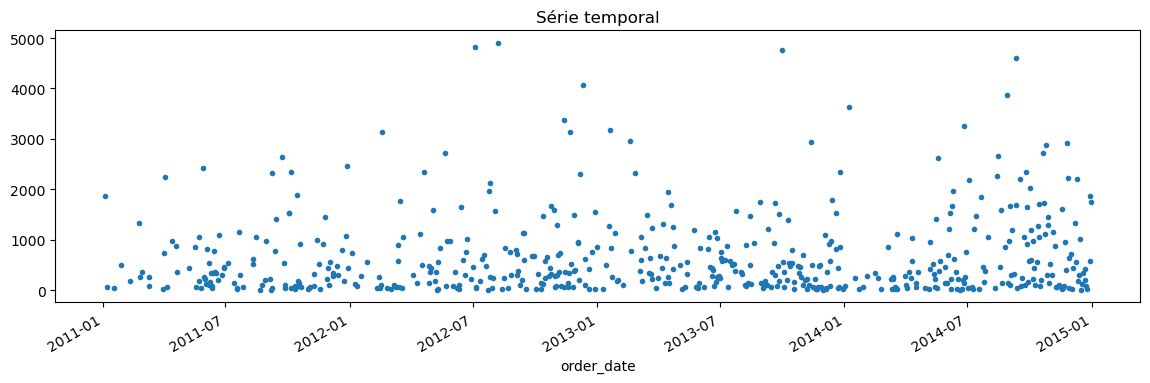

In [429]:
df_Brazil = df[df['country'] == 'Brazil'].groupby('order_date')['sales'].sum()
df_Brazil.plot(figsize=(14, 4), title="Série temporal",style='.')

C:\Users\danil\AppData\Local\Temp\ipykernel_10768\1726777881.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  result.plot().show()


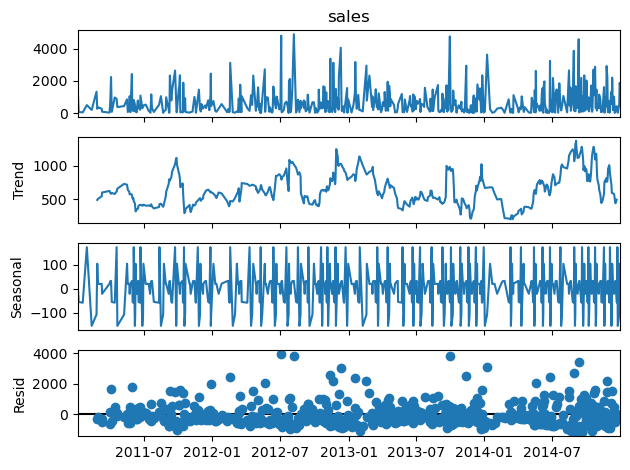

In [430]:
result = seasonal_decompose(df_Brazil, model="additive", period=12)
result.plot().show()

### 2.2 Time Series Decomposition

To separate the underlying signal from noise, we apply **classical time series decomposition**,
breaking the series into three components:

| Component | Description |
|-----------|-------------|
| **Trend** | Long-term direction of sales over time |
| **Seasonality** | Repeating periodic patterns (weekly, monthly, or annual cycles) |
| **Residuals** | What remains after removing trend and seasonality |

The decomposition confirms the challenge noted in the visualization: the **residuals are large
relative to the seasonal component**, indicating that a significant portion of the variance in
daily sales is unexplained noise — much of it attributable to outliers.

### 2.3 Stationarity Testing — ADF & KPSS

Stationarity is a core assumption for many time series models. We apply two complementary tests:

- **ADF (Augmented Dickey-Fuller):** tests the null hypothesis that the series has a unit root
  (non-stationary). A low p-value (< 0.05) rejects the null → series is stationary.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** tests the null hypothesis that the series *is*
  stationary. A low p-value rejects the null → series is non-stationary.

Using both tests together reduces the risk of conflicting conclusions. Results guide whether
differencing is needed before fitting ARIMA-family models.

In [437]:
def teste_adf(serie):
    resultado = adfuller(serie.dropna())
    resultados = kpss(serie.dropna(), regression='c')
    print(f"ADF stat: {resultado[0]:.4f}")
    print(f"p-value:  {resultado[1]:.4f}")
    print("Stationary" if resultado[1] < 0.05 else "Non Stationary")
    print(f"\nKPSS stat: {resultados[0]:.4f}")
    print(f"p-value:  {resultados[1]:.4f}")
    print("Stationary" if resultados[1] > 0.05 else "Non Stationary")

teste_adf(df_Brazil)

ADF stat: -23.0423
p-value:  0.0000
Stationary

KPSS stat: 0.4151
p-value:  0.0706
Stationary


### 2.4 Autocorrelation Analysis — ACF & PACF

The **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** plots
reveal the correlation structure of the series across time lags.

- **ACF:** shows how the series correlates with its own past values at increasing lags
- **PACF:** isolates the direct correlation at each lag, removing the influence of intermediate lags

These plots are essential for:
- Identifying potential **AR (p)** and **MA (q)** orders for ARIMA models
- Detecting weekly seasonality (significant spike at lag 7)
- Confirming whether differencing was effective in removing autocorrelation

The presence of many significant lags with slow decay often signals either non-stationarity or
the influence of outliers distorting the autocorrelation estimates.

There is also, spikes at lag 14, indicating a correlation between 2 weeks

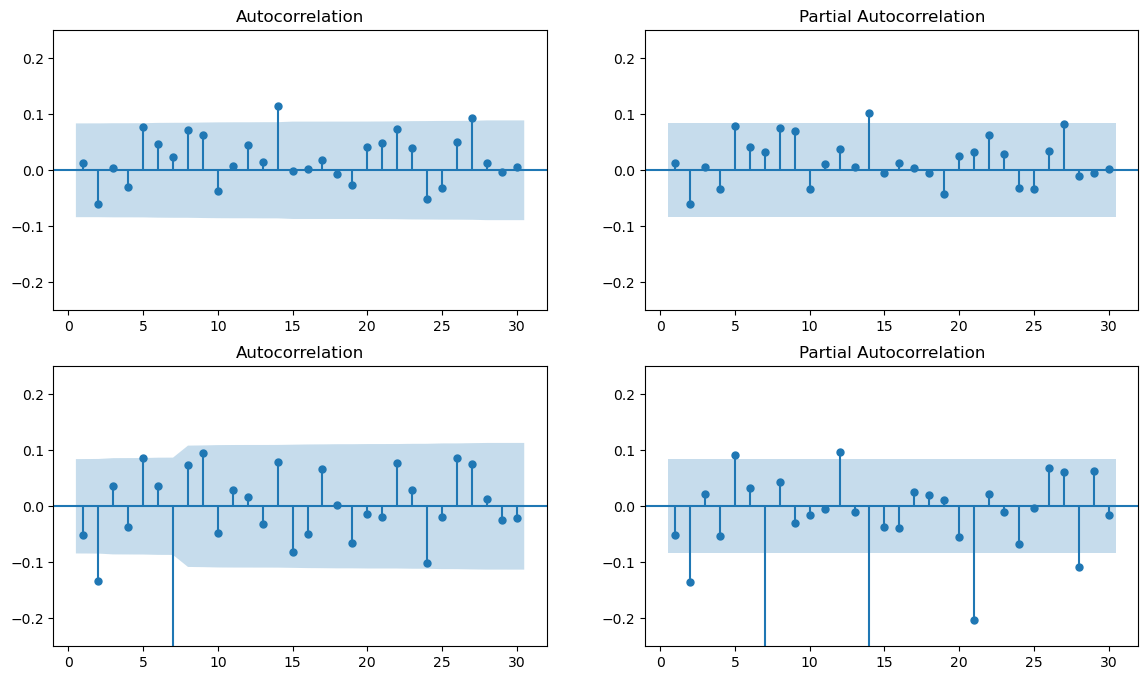

In [431]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df_Brazil.dropna(), ax=axes[0][0], lags=30, zero = False)
plot_pacf(df_Brazil.dropna(), ax=axes[0][1], lags=30,zero = False)

plot_acf(df_Brazil.diff(7).dropna(), ax=axes[1][0], lags=30, zero = False)
plot_pacf(df_Brazil.diff(7).dropna(), ax=axes[1][1], lags=30,zero = False)

plt.setp(axes, ylim=(-0.25, 0.25))

plt.show()

## 3. Modeling Strategy

Two distinct modeling approaches were evaluated and compared:

### Statistical Forecasting — `statsforecast` (Nixtla)
Classical time series models from the `statsforecast` library, which provides fast, production-grade
implementations. These models capture **temporal structure** (trend, seasonality, autocorrelation)
directly from the time series.

### Machine Learning — XGBoost
A gradient boosting model that treats forecasting as a **supervised regression problem**. The
time series is transformed into a feature matrix using lagged values and date-based features
(day of week, month, etc.), allowing XGBoost to learn non-linear patterns without explicit
assumptions about the series structure.

> Comparing statistical and ML approaches allows us to assess whether the dominant signal
> in this series is better captured by temporal autocorrelation or by feature-based patterns.

In [329]:
if isinstance(df_Brazil, pd.Series):
    df_Brazil = df_Brazil.to_frame(name='sales')

df_Brazil.index = pd.to_datetime(df_Brazil.index)
df_Brazil = df_Brazil.asfreq('D').fillna(0).reset_index() # Garante que não há buracos no calendário

In [330]:
df_Brazil = df_Brazil.rename(columns={
    'order_date': 'ds',
    'sales': 'y'
})
df_Brazil['unique_id'] = 'Brazil'

horizon = 60

In [331]:
df_Brazil.head()

,ds,y,unique_id
0,2011-01-04,1871.0,Brazil
1,2011-01-05,0.0,Brazil
2,2011-01-06,0.0,Brazil
3,2011-01-07,62.0,Brazil
4,2011-01-08,0.0,Brazil


Text(0.5, 1.0, 'Train/Test Split')

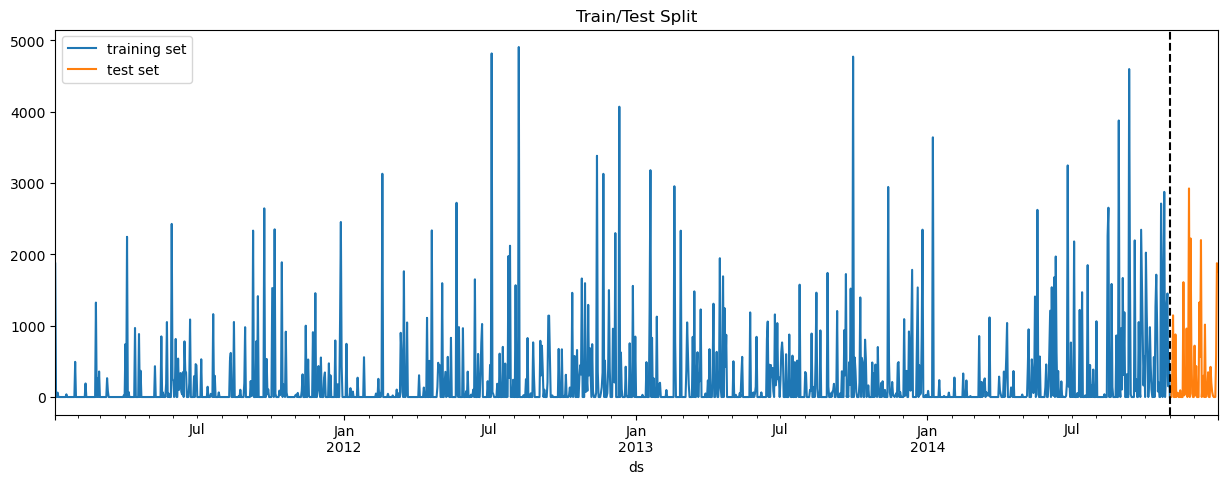

In [332]:
train = df_Brazil.iloc[:-60]
test = df_Brazil.tail(60)

fig,ax = plt.subplots(figsize = (15,5))

train.plot(ax=ax, x = 'ds', y = 'y', label = 'training set')
test.plot(ax=ax,x = 'ds', y = 'y', label = 'test set')
ax.axvline('2014-11-01', color = 'black', ls = '--')
ax.set_title('Train/Test Split')

In [333]:
def feature_creation(df):
    df = df.copy()
    df['dayofweek'] = df[df.select_dtypes(include='datetime').columns.values[0]].dt.dayofweek
    df['week'] = df[df.select_dtypes(include='datetime').columns.values[0]].dt.isocalendar().week
    df['quarter'] = df[df.select_dtypes(include='datetime').columns.values[0]].dt.quarter
    df['month'] = df[df.select_dtypes(include='datetime').columns.values[0]].dt.month
    df['dayofyear'] = df[df.select_dtypes(include='datetime').columns.values[0]].dt.dayofyear
    df['year'] = df[df.select_dtypes(include='datetime').columns.values[0]].dt.year
    return df

In [334]:
df_Brazil_exog_1 = feature_creation(df_Brazil)
df_Brazil_exog_1.head()

,ds,y,unique_id,dayofweek,week,quarter,month,dayofyear,year
0,2011-01-04,1871.0,Brazil,1,1,1,1,4,2011
1,2011-01-05,0.0,Brazil,2,1,1,1,5,2011
2,2011-01-06,0.0,Brazil,3,1,1,1,6,2011
3,2011-01-07,62.0,Brazil,4,1,1,1,7,2011
4,2011-01-08,0.0,Brazil,5,1,1,1,8,2011


C:\Users\danil\AppData\Local\Temp\ipykernel_10768\3601606994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_Brazil_exog_1, x = 'dayofweek', y = 'y', palette='Blues')


<Axes: xlabel='dayofweek', ylabel='y'>

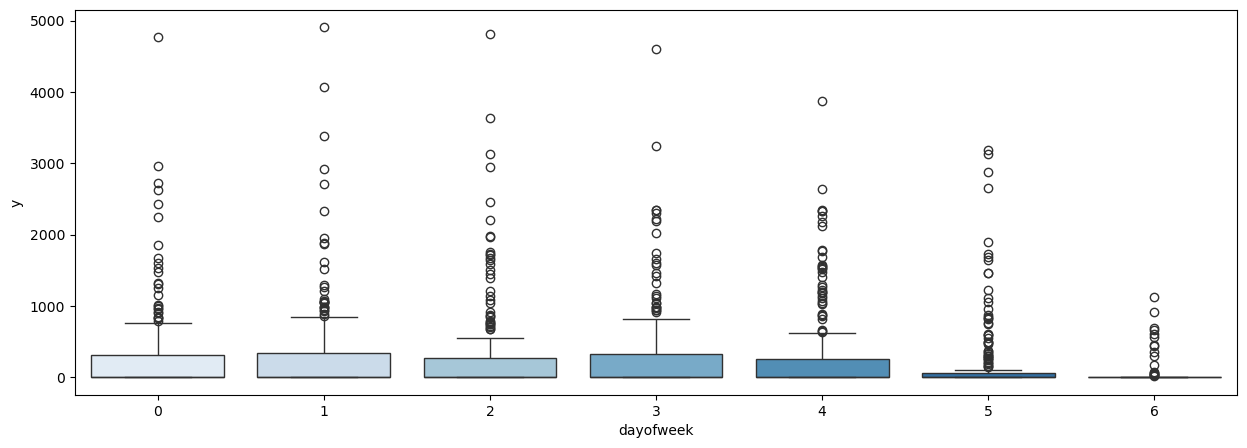

In [335]:
fig,ax = plt.subplots(figsize = (15,5))
sns.boxplot(data = df_Brazil_exog_1, x = 'dayofweek', y = 'y', palette='Blues')

## BASELINE Models - Naive / Historic Average / Window Average / Seasonal Average

In [336]:
models =[
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models = models, freq = 'D')
sf.fit(df=train)
preds = sf.predict(h = horizon)

eval_df = pd.merge(test,preds,'left',['ds','unique_id'])

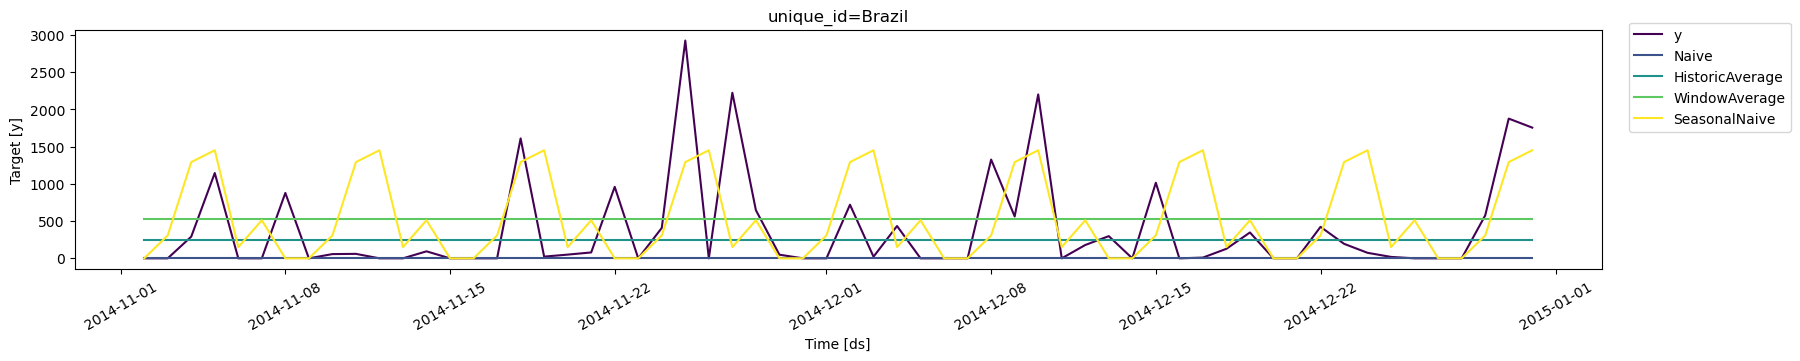

In [337]:
plot_series(
    df = df_Brazil,
    forecasts_df = preds,
    palette = 'viridis',
    max_insample_length= 60
    )

In [338]:
evaluation = evaluate(
    eval_df,
    metrics =[mae,mse]
)

evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Brazil,mae,394.283333,432.062232,551.426190,500.683333
1,Brazil,mse,597458.583333,465380.468234,460495.884014,531729.616667


### Results: 

Historic Average had almost the best performance with MAE, and close to the best performance on MSE. This will be our baseline models for our more sophisticated models

In [339]:

models = [
    AutoARIMA(season_length=7),
    AutoETS(season_length=7),
    AutoTheta(season_length=7),
]

sf = StatsForecast(models = models, freq = 'D')
sf.fit(df=train)
arima_preds = sf.predict(horizon)

arima_eval_df = pd.merge(arima_preds,eval_df,'inner',['ds','unique_id'])

arima_eval = evaluate(
    arima_eval_df,
    metrics = [mae,mse]
)

### AutoARIMA, AutoTheta, AutoETS vs baseline models 

Our so called more sophisticated models, still are not better than our baseline models. So, some feature engineering will be needed. The dates will be decomposed to check if we get better results

In [340]:
arima_eval

,unique_id,metric,AutoARIMA,AutoETS,AutoTheta,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Brazil,mae,584.820897,577.706823,652.270687,394.283333,432.062232,551.426190,500.683333
1,Brazil,mse,480945.706644,464202.045903,530960.439219,597458.583333,465380.468234,460495.884014,531729.616667


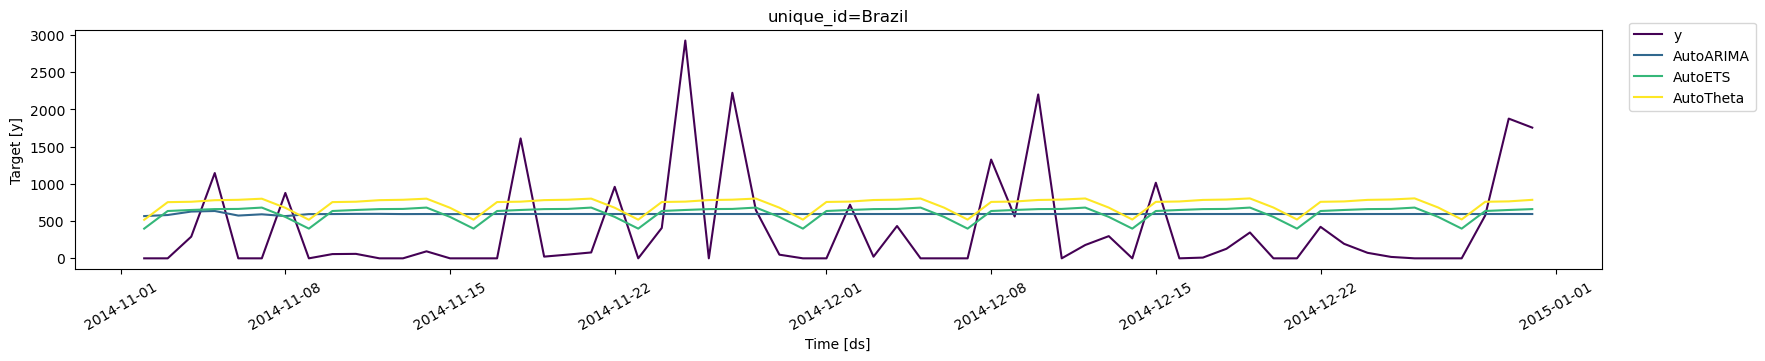

In [341]:
plot_series(
    df = df_Brazil,
    forecasts_df = arima_preds,
    palette = 'viridis',
    max_insample_length=60
    )

In [342]:
cv_df = sf.cross_validation(
    h = horizon,
    df = df_Brazil,
    n_windows= 10,
    step_size= horizon,
    refit = True
)


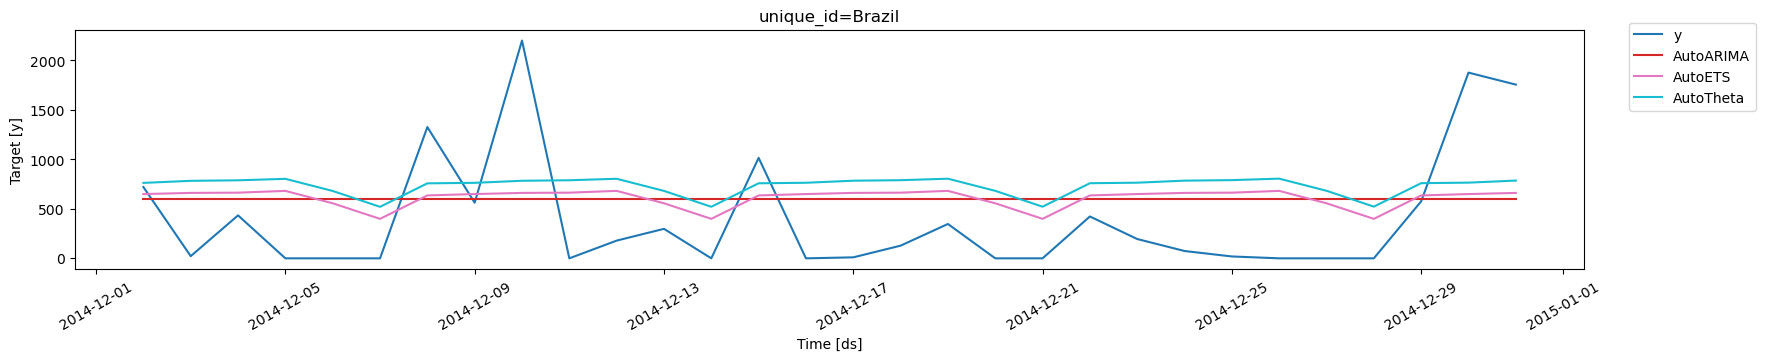

In [343]:
plot_series(
    df = df_Brazil,
    forecasts_df = cv_df.drop(['y','cutoff'],axis=1).tail(30),
    palette = 'tab10',
    max_insample_length=30
    )

In [344]:
cv_eval = evaluate(
    cv_df.drop(['cutoff'],axis = 1),
    metrics = [mae,mse]
)

cv_eval = cv_eval.drop(['unique_id'],axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,AutoARIMA,AutoETS,AutoTheta
0,mae,406.947835,380.236717,395.268226
1,mse,411145.463177,396132.338538,410155.397341


### REsults:

Now, AutoETS showed a better performance. So it will be our baseline model for our comparisons with XGBoost

In [345]:
train_exog = df_Brazil_exog_1.iloc[:-60]
test_exog = df_Brazil_exog_1.tail(60)

cv_exog = sf.cross_validation(
    h = horizon,
    df = train_exog,
    n_windows=10,
    step_size= horizon,
    refit = True
)

In [346]:
cv_exog_eval = evaluate(
    cv_exog.drop(['cutoff'], axis = 1),
    metrics=[mae,mse]
)

In [347]:
cv_exog_eval

,unique_id,metric,AutoARIMA,AutoETS,AutoTheta
0,Brazil,mae,382.306396,357.268402,364.410919
1,Brazil,mse,372480.093750,371422.093750,379301.531250


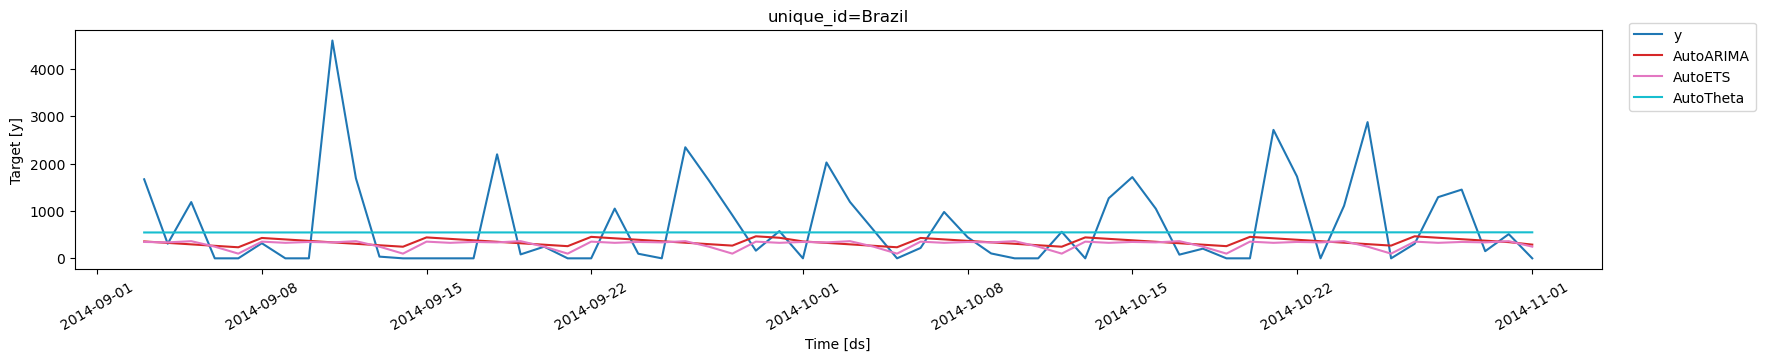

In [348]:
plot_series(
    df = df_Brazil_exog_1.iloc[-120:-60],
    forecasts_df = cv_exog.drop(['y','cutoff'],axis=1).tail(60),
    palette = 'tab10',
    max_insample_length=60
    )

In [349]:
sf = StatsForecast([AutoETS(season_length=7)], freq = 'D')
sf.fit(train_exog)
preds = sf.predict(h = horizon, X_df = test_exog.drop(['y'], axis = 1))

In [350]:
eval_exog = pd.merge(test_exog[['unique_id', 'ds', 'y']],preds,'left',['ds','unique_id'])

evaluate(
    eval_exog,
    metrics = [mae,mse]
)

,unique_id,metric,AutoETS
0,Brazil,mae,577.706822
1,Brazil,mse,464202.042914


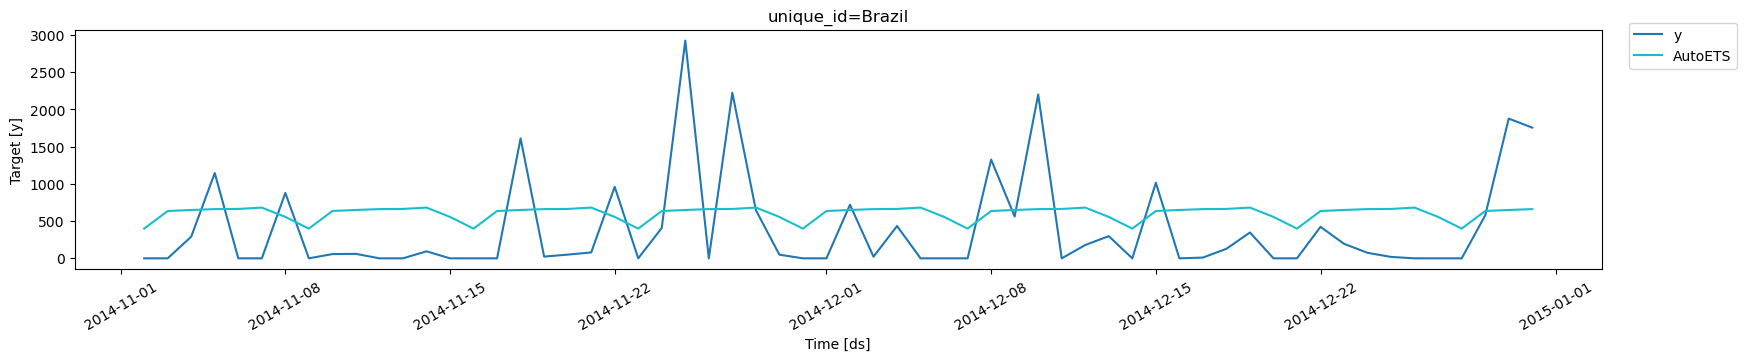

In [351]:
plot_series(
    df = df_Brazil_exog_1,
    forecasts_df = preds,
    palette = 'tab10',
    max_insample_length=60
    )

### XGBoost

In [368]:
Features = ['dayofweek', 'week', 'quarter', 'month',
'dayofyear', 'year']

Target = ['y']

X_train = train_exog[Features].iloc[:-60]
y_train = train_exog[Target].iloc[:-60]

X_val = train_exog[Features].tail(60)
y_val = train_exog[Target].tail(60)

X_test = test_exog[Features]
y_test = test_exog[Target]


In [353]:
reg = xgb.XGBRegressor(n_estimators = 1000, early_stopping_rounds = 50, learning_rate = 0.1)
reg.fit(X_train,y_train,
eval_set = [(X_train,y_train),(X_val,y_val)],
verbose = True
)

[0]	validation_0-rmse:545.21443	validation_1-rmse:1038.92165
[1]	validation_0-rmse:539.64143	validation_1-rmse:1035.40023
[2]	validation_0-rmse:534.77613	validation_1-rmse:1031.29053
[3]	validation_0-rmse:529.96245	validation_1-rmse:1024.87418


[4]	validation_0-rmse:526.42878	validation_1-rmse:1020.86314
[5]	validation_0-rmse:522.90700	validation_1-rmse:1016.15952
[6]	validation_0-rmse:519.25999	validation_1-rmse:1013.69965
[7]	validation_0-rmse:513.85336	validation_1-rmse:1006.34929
[8]	validation_0-rmse:507.61265	validation_1-rmse:1003.65543
[9]	validation_0-rmse:503.17807	validation_1-rmse:1001.45488
[10]	validation_0-rmse:498.71094	validation_1-rmse:1001.42639
[11]	validation_0-rmse:495.04745	validation_1-rmse:996.94055
[12]	validation_0-rmse:489.92734	validation_1-rmse:996.04761
[13]	validation_0-rmse:486.06173	validation_1-rmse:994.81703
[14]	validation_0-rmse:482.89859	validation_1-rmse:994.48275
[15]	validation_0-rmse:480.16730	validation_1-rmse:993.04661
[16]	validation_0-rmse:477.48890	validation_1-rmse:991.53289
[17]	validation_0-rmse:474.97917	validation_1-rmse:990.00179
[18]	validation_0-rmse:471.84331	validation_1-rmse:988.70809
[19]	validation_0-rmse:469.30728	validation_1-rmse:988.31527
[20]	validation_0-rmse:

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [354]:
pd.DataFrame(data = reg.feature_importances_,
             index= X_train.columns.values
)

,0
dayofweek,0.135923
week,0.158325
quarter,0.453416
month,0.025501
dayofyear,0.132228
year,0.094606


In [355]:
X_train.columns.values

<ArrowStringArray>
['dayofweek', 'week', 'quarter', 'month', 'dayofyear', 'year']
Length: 6, dtype: str

In [356]:
test_exog['prediction'] = reg.predict(X_test)

df_Brazil = df_Brazil_exog_1.merge(test_exog[['prediction','ds']], how = 'left', on='ds')
df_Brazil = df_Brazil.merge(preds[['AutoETS','ds']], how = 'left', on='ds')

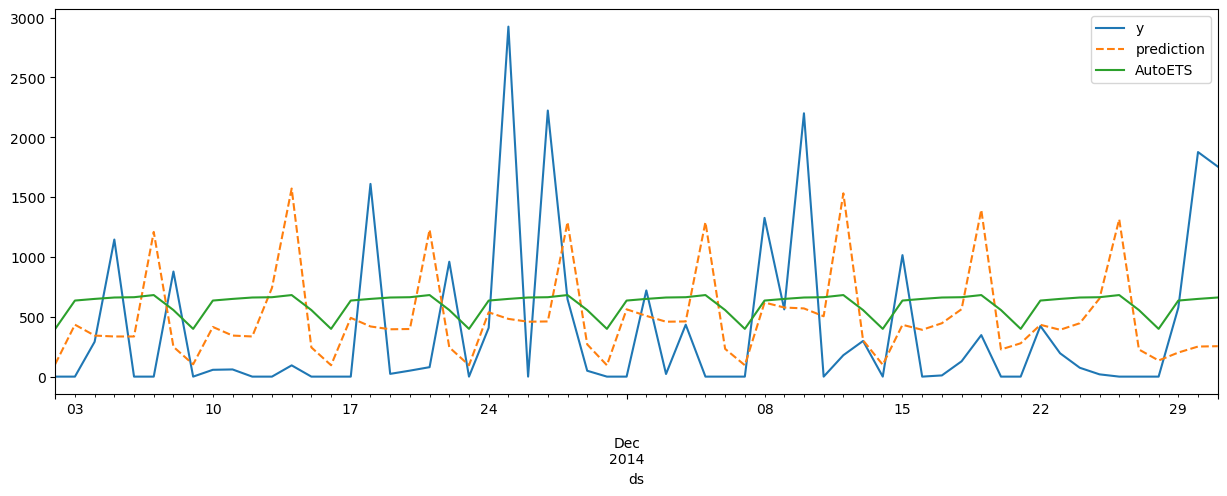

In [357]:
ax = df_Brazil.set_index('ds')[['y']].tail(60).plot(figsize=(15,5))
df_Brazil.set_index('ds')['prediction'].tail(60).plot(ax=ax,style='--')
df_Brazil.set_index('ds')['AutoETS'].tail(60).plot(ax=ax,style='-')

plt.legend()


In [439]:
score_xgb_MSE = mean_squared_error(df_Brazil['y'].tail(60),df_Brazil['prediction'].tail(60))
score_ETS_MSE = mean_squared_error(df_Brazil['y'].tail(60),df_Brazil['AutoETS'].tail(60))

score_xgb_MAE = mean_absolute_error(df_Brazil['y'].tail(60),df_Brazil['prediction'].tail(60))
score_ETS_MAE = mean_absolute_error(df_Brazil['y'].tail(60),df_Brazil['AutoETS'].tail(60))

print(score_xgb_MSE,score_ETS_MSE)
print(score_xgb_MAE,score_ETS_MAE)

KeyError: 'y'

<Axes: ylabel='Frequency'>

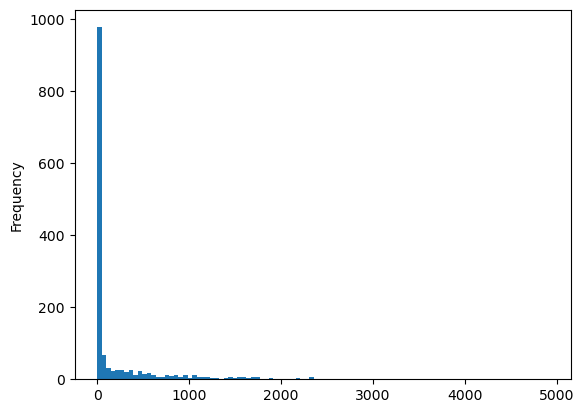

In [238]:
df_Brazil['y'].plot(kind = 'hist', bins = 100)

In [363]:
from sklearn.model_selection import TimeSeriesSplit

### TSS Split for XGBoost

In [380]:
tss = TimeSeriesSplit(n_splits=10,test_size=60,gap=1)


In [369]:
X_train = pd.concat([X_train, X_val], ignore_index=True)
X_train.shape

(1398, 6)

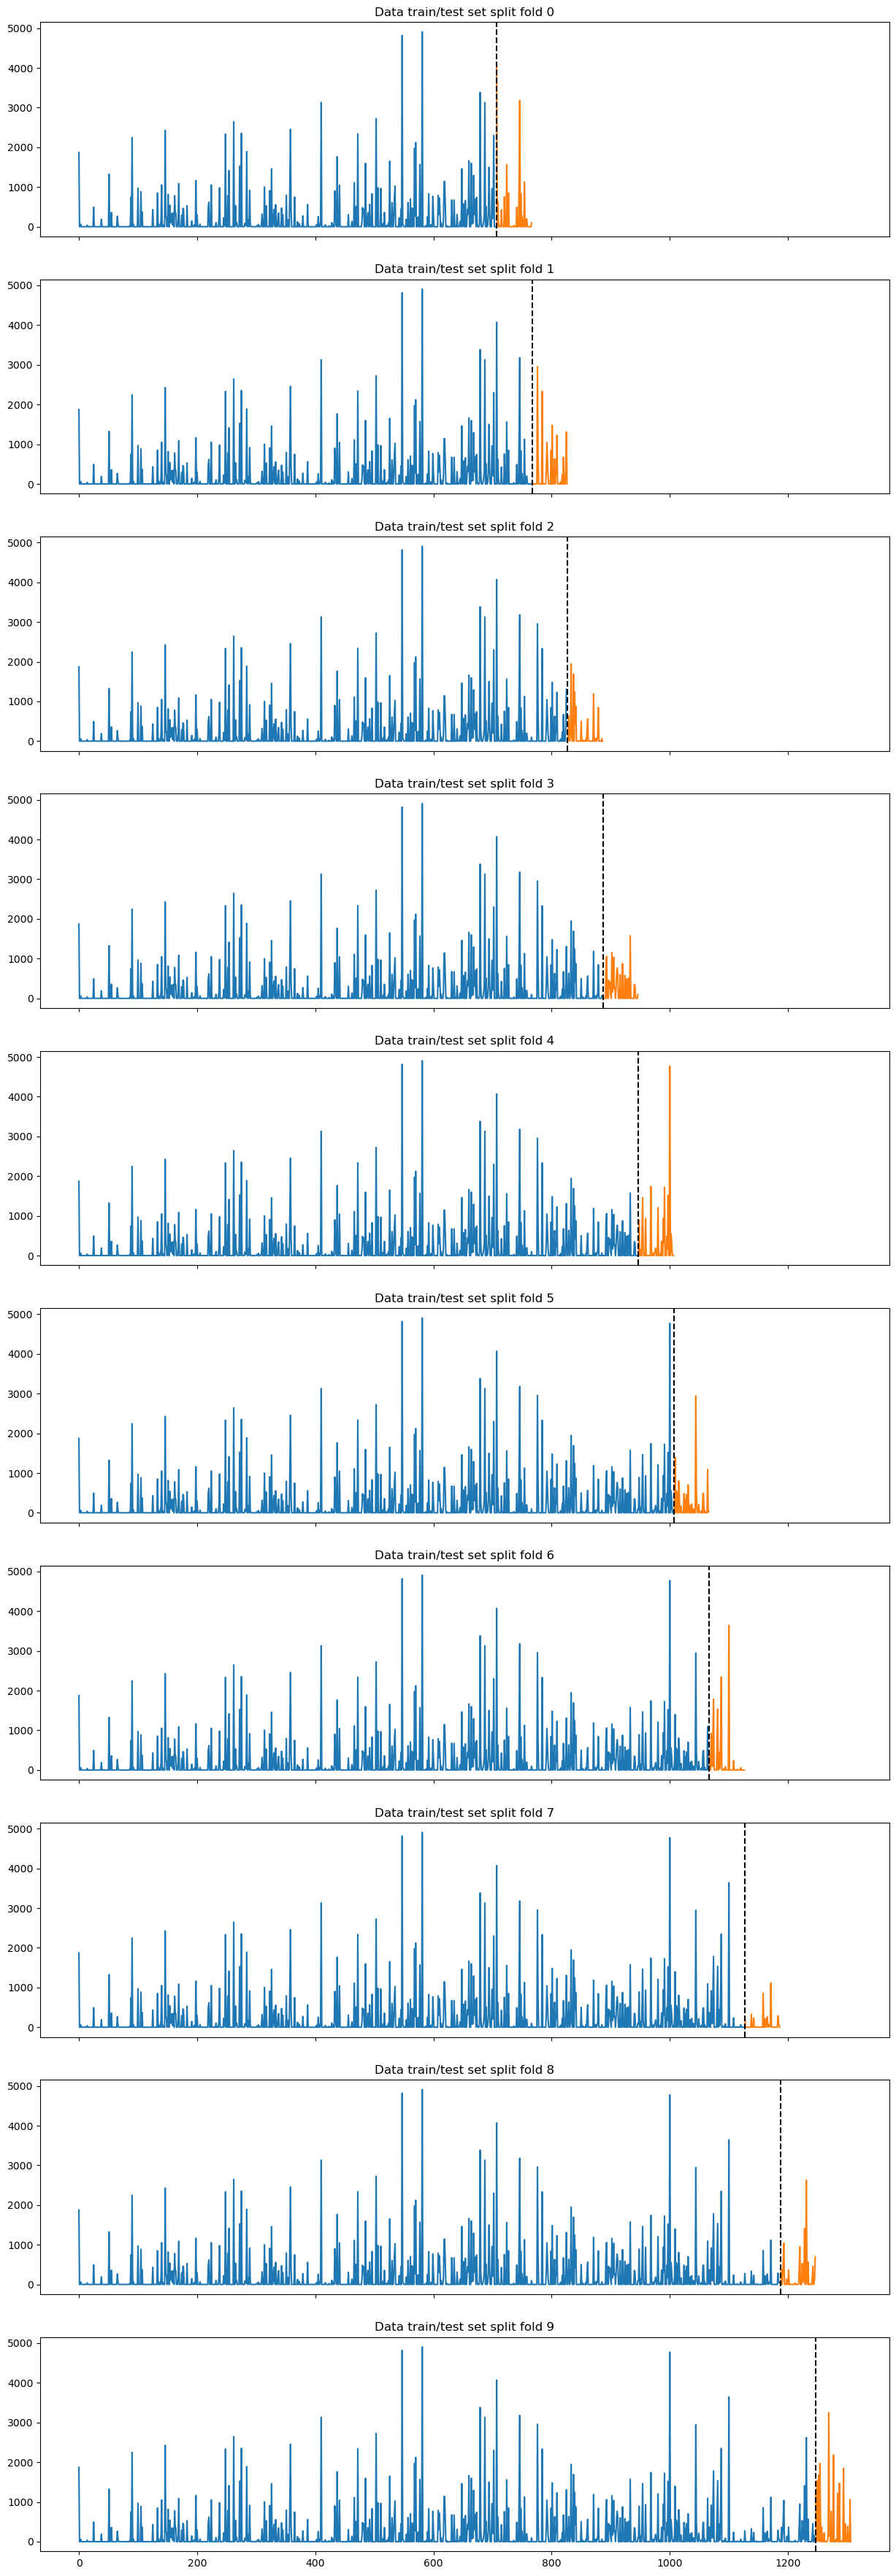

In [381]:
fig, ax = plt.subplots(10,1, figsize = (15,45), sharex = True)

fold = 0

for train_idx, val_idx in tss.split(X_train):
    train = df_Brazil.iloc[train_idx]
    val = df_Brazil.iloc[val_idx]
    train['y'].plot(ax=ax[fold],
                    label = 'training set',
                    title = f'Data train/test set split fold {fold}')
    val['y'].plot(ax=ax[fold],
                    label = 'test set',
                    title = f'Data train/test set split fold {fold}')
    ax[fold].axvline(val.index.min(), color = 'black', ls = '--')


    fold +=1

plt.show()

In [382]:
target_map = df_Brazil.set_index('ds')['y'].to_dict()
df_Brazil['Lag1'] = (df_Brazil['ds'] - pd.Timedelta('7 days')).map(target_map)
df_Brazil['Lag2'] = (df_Brazil['ds'] - pd.Timedelta('14 days')).map(target_map)
df_Brazil['Lag3'] = (df_Brazil['ds'] - pd.Timedelta('365 days')).map(target_map)



### CV With XGBoost

In [ ]:
Train = df_Brazil[:-60]
Holdout = df_Brazil.tail(60)

In [ ]:
fold = 0
preds = []
scores = []

for train_idx, test_idx in tss.split(Train):
    train = df_Brazil.iloc[train_idx]
    test = df_Brazil.iloc[test_idx]

    train = feature_creation(train)
    test = feature_creation(test)

    Features = [ 'dayofweek',       'week',    'quarter',
      'month',  'dayofyear',       'year',
       'Lag1',       'Lag2',       'Lag3']
    
    Target = ['y']

    X_train = train[Features]
    y_train = train[Target]

    X_test = test[Features]
    y_test = test[Target]

    val_size = max(1, int(len(X_train) * 0.15))
    X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
    y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

    reg = xgb.XGBRegressor(n_estimators = 1000,
                           early_stopping_rounds = 50,
                           learning_rate = 0.01)
    reg.fit(X_train,y_train,
            eval_set = [(X_tr,y_tr),(X_val,y_val)],
            verbose = 100)
    
    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = mean_squared_error(y_test,y_pred)
    scores.append(score)



[0]	validation_0-rmse:500.00954	validation_1-rmse:773.88026
[100]	validation_0-rmse:428.46453	validation_1-rmse:579.06031
[200]	validation_0-rmse:383.48835	validation_1-rmse:458.43977
[300]	validation_0-rmse:353.30864	validation_1-rmse:390.56032
[400]	validation_0-rmse:333.80012	validation_1-rmse:343.86354
[500]	validation_0-rmse:318.18762	validation_1-rmse:305.30366
[600]	validation_0-rmse:302.69297	validation_1-rmse:276.22359
[700]	validation_0-rmse:289.37070	validation_1-rmse:245.49116
[800]	validation_0-rmse:278.13047	validation_1-rmse:220.42905
[900]	validation_0-rmse:267.54868	validation_1-rmse:200.70867
[999]	validation_0-rmse:255.98166	validation_1-rmse:185.04818
[0]	validation_0-rmse:542.43380	validation_1-rmse:558.44465
[100]	validation_0-rmse:465.20645	validation_1-rmse:456.08530
[200]	validation_0-rmse:412.39986	validation_1-rmse:395.54623
[300]	validation_0-rmse:375.44996	validation_1-rmse:364.18342
[400]	validation_0-rmse:341.87347	validation_1-rmse:329.63963
[500]	valida

### AutoETS vs XGBoost without LAGs vs XGBoost with LAGs 

In [438]:
print(score_ETS, score_xgb,np.mean(scores))

464202.0429141164 608674.520572319 416238.82265625


In [395]:
y_pred = reg.predict(Holdout[Features])
y_pred = np.clip(y_pred, a_min=0, a_max=None) 
y_pred

mean_squared_error(Holdout[Target],y_pred)

496710.8125

In [398]:
test_exog['preds_lag_XGB'] = y_pred
df_Brazil = df_Brazil.merge(test_exog[['preds_lag_XGB','ds']], how = 'left', on='ds')
df_Brazil.tail()

,ds,y,unique_id,dayofweek,week,quarter,month,dayofyear,year,prediction,AutoETS,Lag1,Lag2,Lag3,preds_lag_XGB
1453,2014-12-27,0.0,Brazil,5,52,4,12,361,2014,226.856491,556.111328,0.0,298.0,0.0,306.907288
1454,2014-12-28,0.0,Brazil,6,52,4,12,362,2014,134.684509,398.913727,0.0,0.0,0.0,60.777157
1455,2014-12-29,576.0,Brazil,0,1,4,12,363,2014,201.212448,635.491699,423.0,1015.0,0.0,313.502441
1456,2014-12-30,1876.0,Brazil,1,1,4,12,364,2014,251.274200,649.255249,195.0,0.0,29.0,215.228668
1457,2014-12-31,1755.0,Brazil,2,1,4,12,365,2014,254.205856,660.916138,74.0,10.0,0.0,198.722244


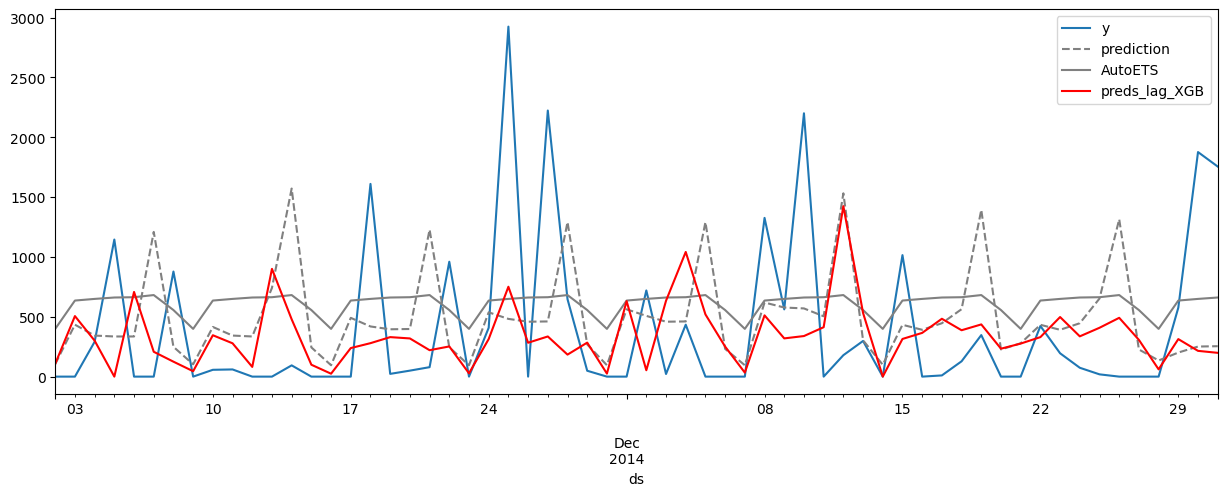

In [399]:
ax = df_Brazil.set_index('ds')[['y']].tail(60).plot(figsize=(15,5))
df_Brazil.set_index('ds')['prediction'].tail(60).plot(ax=ax,style='--',color = 'gray')
df_Brazil.set_index('ds')['AutoETS'].tail(60).plot(ax=ax,style='-', color = 'gray')
df_Brazil.set_index('ds')['preds_lag_XGB'].tail(60).plot(ax=ax,style='-', color = 'red')

plt.legend()

## 3.1 - XGBoost Optimization with Optuna

In [420]:
N_SPLITS = 10
tss = TimeSeriesSplit(n_splits=N_SPLITS)

def objective(trial: optuna.Trial) -> float:
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 2000),
        'max_depth':        trial.suggest_int('max_depth', 2, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-5, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'tree_method':      'hist',
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
    }

    fold_scores = []

    for fold, (train_idx, test_idx) in enumerate(tss.split(Train)):
        # Separar splits
        train_raw = df_Brazil.iloc[train_idx].copy()
        test_raw  = df_Brazil.iloc[test_idx].copy()

        # ✅ Lags calculados DENTRO do loop, separadamente por split

        X_train = train_raw[Features]
        y_train = train_raw[Target]
        X_test  = test_raw[Features]
        y_test  = test_raw[Target]

        # ✅ Val interno para early stopping — sem tocar no test
        val_size = max(1, int(len(X_train) * 0.15))
        X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
        y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

        reg = xgb.XGBRegressor(**params, early_stopping_rounds=50)
        reg.fit(X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False)
        y_pred = reg.predict(X_test)
        preds.append(y_pred)

        score = mean_squared_error(y_test, y_pred)  # RMSE
        fold_scores.append(score)

        # Pruning antecipado
        trial.report(np.mean(fold_scores), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_scores)

In [421]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    study_name='xgb_brazil',
)

study.optimize(objective, n_trials=300, show_progress_bar=True)

print("\n=== MELHORES HIPERPARÂMETROS ===")
print(study.best_params)
print(f"\nMelhor RMSE (CV): {study.best_value:.4f}")

[I 2026-04-08 11:32:52,508] A new study created in memory with name: xgb_brazil
Best trial: 0. Best value: 364226:   0%|          | 1/300 [00:03<19:33,  3.92s/it]

[I 2026-04-08 11:32:56,429] Trial 0 finished with value: 364225.80625 and parameters: {'n_estimators': 812, 'max_depth': 10, 'learning_rate': 0.01893327030371082, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 3.005575058716044}. Best is trial 0 with value: 364225.80625.


Best trial: 1. Best value: 363081:   1%|          | 2/300 [00:05<12:41,  2.56s/it]

[I 2026-04-08 11:32:58,026] Trial 1 finished with value: 363080.5421875 and parameters: {'n_estimators': 1446, 'max_depth': 2, 'learning_rate': 0.2199905443150214, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 363080.5421875.


Best trial: 2. Best value: 357226:   1%|          | 3/300 [00:08<14:26,  2.92s/it]

[I 2026-04-08 11:33:01,371] Trial 2 finished with value: 357225.578125 and parameters: {'n_estimators': 921, 'max_depth': 4, 'learning_rate': 0.005487058617419732, 'subsample': 0.569746930326021, 'colsample_bytree': 0.6460723242676091, 'min_child_weight': 4, 'reg_alpha': 0.00012724181576752517, 'reg_lambda': 0.1165691561324743, 'gamma': 0.9983689107917987}. Best is trial 2 with value: 357225.578125.


Best trial: 2. Best value: 357226:   1%|▏         | 4/300 [00:23<36:52,  7.47s/it]

[I 2026-04-08 11:33:15,830] Trial 3 finished with value: 364568.13125 and parameters: {'n_estimators': 1077, 'max_depth': 7, 'learning_rate': 1.6142252267366917e-05, 'subsample': 0.8037724259507192, 'colsample_bytree': 0.5852620618436457, 'min_child_weight': 1, 'reg_alpha': 3.4671276804481113, 'reg_lambda': 4.905556676028774, 'gamma': 4.041986740582305}. Best is trial 2 with value: 357225.578125.


Best trial: 4. Best value: 354351:   2%|▏         | 5/300 [00:28<33:08,  6.74s/it]

[I 2026-04-08 11:33:21,258] Trial 4 finished with value: 354351.0578125 and parameters: {'n_estimators': 679, 'max_depth': 2, 'learning_rate': 0.011571621671924945, 'subsample': 0.7200762468698007, 'colsample_bytree': 0.5610191174223894, 'min_child_weight': 5, 'reg_alpha': 2.039373116525212e-08, 'reg_lambda': 1.527156759251193, 'gamma': 1.2938999080000846}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   2%|▏         | 6/300 [00:40<40:53,  8.35s/it]

[I 2026-04-08 11:33:32,733] Trial 5 finished with value: 356910.453125 and parameters: {'n_estimators': 1359, 'max_depth': 4, 'learning_rate': 0.0021301372721189427, 'subsample': 0.7733551396716398, 'colsample_bytree': 0.5924272277627636, 'min_child_weight': 10, 'reg_alpha': 0.09466630153726856, 'reg_lambda': 2.854239907497756, 'gamma': 4.474136752138244}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   2%|▏         | 7/300 [01:04<1:05:39, 13.45s/it]

[I 2026-04-08 11:33:56,679] Trial 6 finished with value: 364263.96875 and parameters: {'n_estimators': 1236, 'max_depth': 10, 'learning_rate': 2.4899559373463568e-05, 'subsample': 0.5979914312095727, 'colsample_bytree': 0.522613644455269, 'min_child_weight': 4, 'reg_alpha': 3.148441347423712e-05, 'reg_lambda': 2.7678419414850017e-06, 'gamma': 4.143687545759647}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   3%|▎         | 8/300 [01:08<51:05, 10.50s/it]  

[I 2026-04-08 11:34:00,866] Trial 7 finished with value: 358958.3109375 and parameters: {'n_estimators': 778, 'max_depth': 4, 'learning_rate': 0.0026897763379336356, 'subsample': 0.5704621124873813, 'colsample_bytree': 0.9010984903770198, 'min_child_weight': 1, 'reg_alpha': 7.620481786158549, 'reg_lambda': 0.08916674715636537, 'gamma': 0.993578407670862}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   3%|▎         | 9/300 [01:12<40:47,  8.41s/it]

[I 2026-04-08 11:34:04,682] Trial 8 finished with value: 361434.5890625 and parameters: {'n_estimators': 110, 'max_depth': 9, 'learning_rate': 0.014611205138065528, 'subsample': 0.8645035840204937, 'colsample_bytree': 0.8856351733429728, 'min_child_weight': 1, 'reg_alpha': 1.683416412018213e-05, 'reg_lambda': 1.1036250149900698e-07, 'gamma': 4.315517129377968}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   3%|▎         | 10/300 [01:26<50:03, 10.36s/it]

[I 2026-04-08 11:34:19,407] Trial 9 finished with value: 364297.553125 and parameters: {'n_estimators': 1284, 'max_depth': 4, 'learning_rate': 1.9255661420887862e-05, 'subsample': 0.6554911608578311, 'colsample_bytree': 0.6625916610133735, 'min_child_weight': 8, 'reg_alpha': 0.005470376807480391, 'reg_lambda': 0.9658611176861268, 'gamma': 2.3610746258097466}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   4%|▎         | 11/300 [01:39<53:28, 11.10s/it]

[I 2026-04-08 11:34:32,197] Trial 10 finished with value: 360098.9703125 and parameters: {'n_estimators': 1896, 'max_depth': 2, 'learning_rate': 0.00023855267674328915, 'subsample': 0.6889757749826013, 'colsample_bytree': 0.7680942943488798, 'min_child_weight': 7, 'reg_alpha': 1.368174031940222e-08, 'reg_lambda': 0.003327054963436224, 'gamma': 0.23696217751263204}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   4%|▍         | 12/300 [01:45<45:59,  9.58s/it]

[I 2026-04-08 11:34:38,297] Trial 11 finished with value: 362499.4421875 and parameters: {'n_estimators': 338, 'max_depth': 6, 'learning_rate': 0.00039288331415102666, 'subsample': 0.7311722932108227, 'colsample_bytree': 0.7518138484340006, 'min_child_weight': 10, 'reg_alpha': 0.030505320939032143, 'reg_lambda': 0.0029151336209232823, 'gamma': 4.990497566649651}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   4%|▍         | 13/300 [01:47<33:57,  7.10s/it]

[I 2026-04-08 11:34:39,686] Trial 12 finished with value: 359683.984375 and parameters: {'n_estimators': 1663, 'max_depth': 3, 'learning_rate': 0.07261127701853673, 'subsample': 0.9929294675046496, 'colsample_bytree': 0.5188124141823621, 'min_child_weight': 6, 'reg_alpha': 0.055541294604673545, 'reg_lambda': 8.805322711085044, 'gamma': 1.6921629101016427}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   5%|▍         | 14/300 [01:55<35:17,  7.40s/it]

[I 2026-04-08 11:34:47,796] Trial 13 finished with value: 360415.915625 and parameters: {'n_estimators': 531, 'max_depth': 6, 'learning_rate': 0.0006186553063450702, 'subsample': 0.7821850063415318, 'colsample_bytree': 0.682398309497015, 'min_child_weight': 10, 'reg_alpha': 1.492775149980716e-06, 'reg_lambda': 0.008457008200117626, 'gamma': 3.2791412962771105}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   5%|▌         | 15/300 [02:00<32:28,  6.84s/it]

[I 2026-04-08 11:34:53,324] Trial 14 finished with value: 358505.2515625 and parameters: {'n_estimators': 547, 'max_depth': 5, 'learning_rate': 0.0012495695636773963, 'subsample': 0.6647249159772833, 'colsample_bytree': 0.9879889242235423, 'min_child_weight': 8, 'reg_alpha': 0.0018987880794962603, 'reg_lambda': 0.00010920889093748508, 'gamma': 1.897903508611385}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   5%|▌         | 16/300 [02:02<24:43,  5.23s/it]

[I 2026-04-08 11:34:54,800] Trial 15 finished with value: 356336.6140625 and parameters: {'n_estimators': 1541, 'max_depth': 2, 'learning_rate': 0.03611799633813083, 'subsample': 0.5054945946218856, 'colsample_bytree': 0.5084231447650897, 'min_child_weight': 5, 'reg_alpha': 0.27196665843282253, 'reg_lambda': 0.04675828059958986, 'gamma': 0.2910054682539276}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   6%|▌         | 17/300 [02:03<19:01,  4.03s/it]

[I 2026-04-08 11:34:56,059] Trial 16 finished with value: 356131.4203125 and parameters: {'n_estimators': 1851, 'max_depth': 2, 'learning_rate': 0.04570465541266005, 'subsample': 0.5021077486189073, 'colsample_bytree': 0.5014947853022957, 'min_child_weight': 4, 'reg_alpha': 0.9820007458459092, 'reg_lambda': 0.0348885376241305, 'gamma': 0.06589607190461777}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   6%|▌         | 18/300 [02:04<14:38,  3.12s/it]

[I 2026-04-08 11:34:57,045] Trial 17 finished with value: 360294.2453125 and parameters: {'n_estimators': 1965, 'max_depth': 3, 'learning_rate': 0.19233536174233154, 'subsample': 0.6224893316778809, 'colsample_bytree': 0.8132394567758081, 'min_child_weight': 4, 'reg_alpha': 1.0131207604151506e-06, 'reg_lambda': 0.0005068082867108995, 'gamma': 0.9243701104133165}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   6%|▋         | 19/300 [02:06<13:23,  2.86s/it]

[I 2026-04-08 11:34:59,302] Trial 18 finished with value: 361498.6890625 and parameters: {'n_estimators': 1761, 'max_depth': 8, 'learning_rate': 0.007874554773118176, 'subsample': 0.5004418112131209, 'colsample_bytree': 0.5453297654079645, 'min_child_weight': 3, 'reg_alpha': 0.0011906175810361388, 'reg_lambda': 0.00014021547203370562, 'gamma': 0.06845225665561236}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   7%|▋         | 20/300 [02:07<10:55,  2.34s/it]

[I 2026-04-08 11:35:00,433] Trial 19 finished with value: 359968.828125 and parameters: {'n_estimators': 619, 'max_depth': 3, 'learning_rate': 0.06136512227978027, 'subsample': 0.7159288929998384, 'colsample_bytree': 0.7051102112946549, 'min_child_weight': 6, 'reg_alpha': 0.963190425685355, 'reg_lambda': 0.0319329186933479, 'gamma': 1.4659938910884596}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   7%|▋         | 21/300 [02:09<09:43,  2.09s/it]

[I 2026-04-08 11:35:01,943] Trial 20 finished with value: 359861.315625 and parameters: {'n_estimators': 1090, 'max_depth': 5, 'learning_rate': 0.03486163856921845, 'subsample': 0.863768631339208, 'colsample_bytree': 0.6269129264232913, 'min_child_weight': 5, 'reg_alpha': 1.7739013117825787e-07, 'reg_lambda': 0.33773659662167305, 'gamma': 0.635719210044362}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   7%|▋         | 22/300 [02:10<08:02,  1.73s/it]

[I 2026-04-08 11:35:02,841] Trial 21 finished with value: 358526.103125 and parameters: {'n_estimators': 1573, 'max_depth': 2, 'learning_rate': 0.08443903331076973, 'subsample': 0.5315487532681687, 'colsample_bytree': 0.5001266182852511, 'min_child_weight': 5, 'reg_alpha': 1.017726147366717, 'reg_lambda': 0.02894280100415756, 'gamma': 0.46140024758065223}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   8%|▊         | 23/300 [02:11<07:17,  1.58s/it]

[I 2026-04-08 11:35:04,062] Trial 22 finished with value: 355622.815625 and parameters: {'n_estimators': 1752, 'max_depth': 2, 'learning_rate': 0.025302759090751414, 'subsample': 0.5218512375804301, 'colsample_bytree': 0.5509336401103144, 'min_child_weight': 3, 'reg_alpha': 0.5468105382199528, 'reg_lambda': 0.0010553058942792206, 'gamma': 1.4011340101304386}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   8%|▊         | 24/300 [02:13<07:50,  1.70s/it]

[I 2026-04-08 11:35:06,064] Trial 23 finished with value: 356406.2453125 and parameters: {'n_estimators': 1794, 'max_depth': 3, 'learning_rate': 0.0073625854714165434, 'subsample': 0.5565254726675414, 'colsample_bytree': 0.5576081735921724, 'min_child_weight': 3, 'reg_alpha': 0.013635333292672278, 'reg_lambda': 1.440909887182662e-05, 'gamma': 1.3604014346186917}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   8%|▊         | 25/300 [02:14<07:19,  1.60s/it]

[I 2026-04-08 11:35:07,413] Trial 24 finished with value: 355465.8265625 and parameters: {'n_estimators': 1978, 'max_depth': 2, 'learning_rate': 0.019835325011521132, 'subsample': 0.6065348996328781, 'colsample_bytree': 0.5616469293797434, 'min_child_weight': 3, 'reg_alpha': 0.2694880597829013, 'reg_lambda': 0.0005168678813365989, 'gamma': 2.0503583534419594}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   9%|▊         | 26/300 [02:16<07:35,  1.66s/it]

[I 2026-04-08 11:35:09,219] Trial 25 finished with value: 355499.740625 and parameters: {'n_estimators': 1961, 'max_depth': 3, 'learning_rate': 0.01568517824393793, 'subsample': 0.6260525991541356, 'colsample_bytree': 0.7082035495477591, 'min_child_weight': 3, 'reg_alpha': 8.058360986958853e-06, 'reg_lambda': 1.5450244271507118e-08, 'gamma': 2.053378092006266}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   9%|▉         | 27/300 [02:19<08:42,  1.91s/it]

[I 2026-04-08 11:35:11,718] Trial 26 finished with value: 358206.48125 and parameters: {'n_estimators': 1979, 'max_depth': 5, 'learning_rate': 0.0046295241874680535, 'subsample': 0.6115441561293566, 'colsample_bytree': 0.7137325412168262, 'min_child_weight': 2, 'reg_alpha': 8.604852982284087e-06, 'reg_lambda': 1.6902749588425184e-08, 'gamma': 2.152494695290408}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:   9%|▉         | 28/300 [02:20<08:29,  1.87s/it]

[I 2026-04-08 11:35:13,506] Trial 27 finished with value: 356605.3765625 and parameters: {'n_estimators': 283, 'max_depth': 3, 'learning_rate': 0.010629856148478046, 'subsample': 0.6335082284873432, 'colsample_bytree': 0.8064484328104978, 'min_child_weight': 3, 'reg_alpha': 0.00013263357286267798, 'reg_lambda': 2.1032906735141402e-07, 'gamma': 2.6466261529957076}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  10%|▉         | 29/300 [02:25<11:38,  2.58s/it]

[I 2026-04-08 11:35:17,723] Trial 28 finished with value: 356085.8875 and parameters: {'n_estimators': 724, 'max_depth': 3, 'learning_rate': 0.003333606424947134, 'subsample': 0.6795275282009212, 'colsample_bytree': 0.6410067773606047, 'min_child_weight': 7, 'reg_alpha': 5.587102456166544e-08, 'reg_lambda': 4.0015668451015035e-05, 'gamma': 3.571792002906532}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  10%|█         | 30/300 [02:26<10:29,  2.33s/it]

[I 2026-04-08 11:35:19,484] Trial 29 finished with value: 361326.0546875 and parameters: {'n_estimators': 902, 'max_depth': 7, 'learning_rate': 0.0167176847747738, 'subsample': 0.7194022937661176, 'colsample_bytree': 0.6121467533877929, 'min_child_weight': 2, 'reg_alpha': 5.395588976028015e-06, 'reg_lambda': 1.1614088660604218e-06, 'gamma': 3.00120582375693}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  10%|█         | 31/300 [02:32<15:17,  3.41s/it]

[I 2026-04-08 11:35:25,405] Trial 30 finished with value: 359115.8171875 and parameters: {'n_estimators': 1625, 'max_depth': 4, 'learning_rate': 0.0011922580196011639, 'subsample': 0.8219007716098994, 'colsample_bytree': 0.7201186658951265, 'min_child_weight': 3, 'reg_alpha': 8.897796627937682e-08, 'reg_lambda': 1.909079967843716e-08, 'gamma': 1.9861313436037082}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  11%|█         | 32/300 [02:34<12:10,  2.73s/it]

[I 2026-04-08 11:35:26,545] Trial 31 finished with value: 355222.121875 and parameters: {'n_estimators': 1725, 'max_depth': 2, 'learning_rate': 0.02629535318446373, 'subsample': 0.5859667931131726, 'colsample_bytree': 0.5731058212867748, 'min_child_weight': 3, 'reg_alpha': 1.0691962780416584e-08, 'reg_lambda': 0.0006283757533946637, 'gamma': 1.491225946823017}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  11%|█         | 33/300 [02:34<09:41,  2.18s/it]

[I 2026-04-08 11:35:27,436] Trial 32 finished with value: 361066.840625 and parameters: {'n_estimators': 1996, 'max_depth': 2, 'learning_rate': 0.14866072329277594, 'subsample': 0.5950371102646941, 'colsample_bytree': 0.5809277452593549, 'min_child_weight': 2, 'reg_alpha': 1.3988079666240775e-08, 'reg_lambda': 1.928974856815695e-05, 'gamma': 2.448549477079407}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  11%|█▏        | 34/300 [02:36<09:04,  2.05s/it]

[I 2026-04-08 11:35:29,173] Trial 33 finished with value: 356696.40625 and parameters: {'n_estimators': 1493, 'max_depth': 3, 'learning_rate': 0.020167762289814317, 'subsample': 0.6419368251181257, 'colsample_bytree': 0.558085337071205, 'min_child_weight': 4, 'reg_alpha': 3.2382619654347945e-07, 'reg_lambda': 6.145326970254058e-07, 'gamma': 1.8061183028172199}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  12%|█▏        | 35/300 [02:38<08:36,  1.95s/it]

[I 2026-04-08 11:35:30,893] Trial 34 finished with value: 356207.059375 and parameters: {'n_estimators': 1874, 'max_depth': 2, 'learning_rate': 0.009401722175630416, 'subsample': 0.5555522700282238, 'colsample_bytree': 0.6640253143746593, 'min_child_weight': 2, 'reg_alpha': 3.9035348536989365e-08, 'reg_lambda': 0.00027138487731591534, 'gamma': 2.8174797934737272}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  12%|█▏        | 36/300 [02:39<07:21,  1.67s/it]

[I 2026-04-08 11:35:31,924] Trial 35 finished with value: 358637.7453125 and parameters: {'n_estimators': 1705, 'max_depth': 2, 'learning_rate': 0.12028992744139078, 'subsample': 0.6952841582788005, 'colsample_bytree': 0.6029040824537674, 'min_child_weight': 5, 'reg_alpha': 2.1300966095603636e-06, 'reg_lambda': 0.0012319110679996864, 'gamma': 1.218167332314846}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  12%|█▏        | 37/300 [02:40<06:22,  1.45s/it]

[I 2026-04-08 11:35:32,863] Trial 36 finished with value: 367691.1984375 and parameters: {'n_estimators': 1164, 'max_depth': 3, 'learning_rate': 0.2437171500144003, 'subsample': 0.5797058038044446, 'colsample_bytree': 0.6215076106180613, 'min_child_weight': 4, 'reg_alpha': 5.71248181506667e-05, 'reg_lambda': 0.008098358872880681, 'gamma': 2.187750729816677}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  13%|█▎        | 38/300 [02:49<16:11,  3.71s/it]

[I 2026-04-08 11:35:41,839] Trial 37 finished with value: 363080.83125 and parameters: {'n_estimators': 1429, 'max_depth': 4, 'learning_rate': 9.258949868975233e-05, 'subsample': 0.753107261494629, 'colsample_bytree': 0.5688932254707043, 'min_child_weight': 1, 'reg_alpha': 1.087985460865599e-08, 'reg_lambda': 0.3915330318151539, 'gamma': 1.6265250440555454}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  13%|█▎        | 39/300 [02:51<14:37,  3.36s/it]

[I 2026-04-08 11:35:44,391] Trial 38 finished with value: 357109.4625 and parameters: {'n_estimators': 938, 'max_depth': 3, 'learning_rate': 0.004672672521119361, 'subsample': 0.612843321324555, 'colsample_bytree': 0.5361115720387086, 'min_child_weight': 3, 'reg_alpha': 1.7448709922581198e-07, 'reg_lambda': 5.317950940762494e-06, 'gamma': 0.877730936627725}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  13%|█▎        | 40/300 [02:53<11:54,  2.75s/it]

[I 2026-04-08 11:35:45,699] Trial 39 finished with value: 354409.4875 and parameters: {'n_estimators': 1389, 'max_depth': 2, 'learning_rate': 0.025961183414012202, 'subsample': 0.6536385770079023, 'colsample_bytree': 0.5926100799418772, 'min_child_weight': 4, 'reg_alpha': 4.5773827173229815e-07, 'reg_lambda': 2.312611185426143, 'gamma': 1.2071811812883257}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  14%|█▎        | 41/300 [02:54<10:11,  2.36s/it]

[I 2026-04-08 11:35:47,163] Trial 40 finished with value: 354929.3171875 and parameters: {'n_estimators': 1389, 'max_depth': 2, 'learning_rate': 0.026984359928674304, 'subsample': 0.6679354091821296, 'colsample_bytree': 0.5938876788270101, 'min_child_weight': 6, 'reg_alpha': 3.292848007376325e-08, 'reg_lambda': 1.888730203518782, 'gamma': 0.604322602462201}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  14%|█▍        | 42/300 [02:56<09:06,  2.12s/it]

[I 2026-04-08 11:35:48,713] Trial 41 finished with value: 354904.8390625 and parameters: {'n_estimators': 1411, 'max_depth': 2, 'learning_rate': 0.023005707340195122, 'subsample': 0.6612458853759583, 'colsample_bytree': 0.5864661361301485, 'min_child_weight': 6, 'reg_alpha': 2.6602323489103306e-08, 'reg_lambda': 2.4586371423965483, 'gamma': 0.6405601788917905}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  14%|█▍        | 43/300 [02:57<07:49,  1.83s/it]

[I 2026-04-08 11:35:49,863] Trial 42 finished with value: 355638.403125 and parameters: {'n_estimators': 1354, 'max_depth': 2, 'learning_rate': 0.035167420941745985, 'subsample': 0.6691141539098837, 'colsample_bytree': 0.5923438633467545, 'min_child_weight': 6, 'reg_alpha': 3.3850597326378845e-08, 'reg_lambda': 1.3988047993103438, 'gamma': 0.6752922514533737}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  15%|█▍        | 44/300 [02:58<06:48,  1.59s/it]

[I 2026-04-08 11:35:50,914] Trial 43 finished with value: 355907.2515625 and parameters: {'n_estimators': 1217, 'max_depth': 2, 'learning_rate': 0.09197345335100367, 'subsample': 0.7509136810748136, 'colsample_bytree': 0.6406682131174897, 'min_child_weight': 7, 'reg_alpha': 6.610662225830892e-07, 'reg_lambda': 2.861203950805288, 'gamma': 1.0851949196332376}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  15%|█▌        | 45/300 [03:00<07:38,  1.80s/it]

[I 2026-04-08 11:35:53,191] Trial 44 finished with value: 362532.1328125 and parameters: {'n_estimators': 1371, 'max_depth': 10, 'learning_rate': 0.011644346514501122, 'subsample': 0.7001457164238087, 'colsample_bytree': 0.5853884623191556, 'min_child_weight': 6, 'reg_alpha': 1.1330951087885302e-07, 'reg_lambda': 0.12981031003035007, 'gamma': 0.7299704608087026}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  15%|█▌        | 46/300 [03:01<06:52,  1.63s/it]

[I 2026-04-08 11:35:54,413] Trial 45 finished with value: 359752.1125 and parameters: {'n_estimators': 1308, 'max_depth': 4, 'learning_rate': 0.045794682913187834, 'subsample': 0.665017899330379, 'colsample_bytree': 0.6627383328643943, 'min_child_weight': 7, 'reg_alpha': 2.656321211469377e-08, 'reg_lambda': 8.029434030607506, 'gamma': 0.47298333826507366}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  16%|█▌        | 47/300 [03:03<06:40,  1.58s/it]

[I 2026-04-08 11:35:55,890] Trial 46 finished with value: 354636.1046875 and parameters: {'n_estimators': 1055, 'max_depth': 2, 'learning_rate': 0.02732728918899744, 'subsample': 0.6464908136976142, 'colsample_bytree': 0.5316996994509066, 'min_child_weight': 8, 'reg_alpha': 3.7727940880458614e-07, 'reg_lambda': 1.500147498504907, 'gamma': 1.1433198836065317}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  16%|█▌        | 48/300 [03:07<09:46,  2.33s/it]

[I 2026-04-08 11:35:59,963] Trial 47 finished with value: 356678.053125 and parameters: {'n_estimators': 1019, 'max_depth': 3, 'learning_rate': 0.002216654265459128, 'subsample': 0.7385925382637037, 'colsample_bytree': 0.5403317102892633, 'min_child_weight': 9, 'reg_alpha': 3.567451412487529e-07, 'reg_lambda': 2.3338845246036524, 'gamma': 1.1626559369351857}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  16%|█▋        | 49/300 [03:08<08:34,  2.05s/it]

[I 2026-04-08 11:36:01,355] Trial 48 finished with value: 362068.975 and parameters: {'n_estimators': 1151, 'max_depth': 9, 'learning_rate': 0.06424731574584176, 'subsample': 0.643866081094422, 'colsample_bytree': 0.525880939991438, 'min_child_weight': 8, 'reg_alpha': 3.3114056807610862e-06, 'reg_lambda': 0.7253414175032692, 'gamma': 0.33721486708394766}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  17%|█▋        | 50/300 [03:10<08:02,  1.93s/it]

[I 2026-04-08 11:36:03,012] Trial 49 finished with value: 360725.8765625 and parameters: {'n_estimators': 1449, 'max_depth': 4, 'learning_rate': 0.12097164362141077, 'subsample': 0.7075232538132787, 'colsample_bytree': 0.6065064223285875, 'min_child_weight': 9, 'reg_alpha': 4.7374955341428687e-07, 'reg_lambda': 0.2637151757777551, 'gamma': 0.8075424178810707}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  17%|█▋        | 51/300 [03:13<08:48,  2.12s/it]

[I 2026-04-08 11:36:05,585] Trial 50 finished with value: 354571.2515625 and parameters: {'n_estimators': 840, 'max_depth': 2, 'learning_rate': 0.006184214027754417, 'subsample': 0.7749368784943925, 'colsample_bytree': 0.6804712202029732, 'min_child_weight': 5, 'reg_alpha': 7.007044836204086e-08, 'reg_lambda': 4.574931999430445, 'gamma': 0.5347083923169884}. Best is trial 4 with value: 354351.0578125.


Best trial: 4. Best value: 354351:  17%|█▋        | 52/300 [03:15<08:59,  2.18s/it]

[I 2026-04-08 11:36:07,880] Trial 51 finished with value: 354484.784375 and parameters: {'n_estimators': 812, 'max_depth': 2, 'learning_rate': 0.0071342313891942085, 'subsample': 0.7775353143080098, 'colsample_bytree': 0.6788492966049715, 'min_child_weight': 5, 'reg_alpha': 7.01960589419541e-08, 'reg_lambda': 3.6627396743631873, 'gamma': 0.5279563562719798}. Best is trial 4 with value: 354351.0578125.


Best trial: 52. Best value: 354078:  18%|█▊        | 53/300 [03:18<09:36,  2.33s/it]

[I 2026-04-08 11:36:10,582] Trial 52 finished with value: 354077.6203125 and parameters: {'n_estimators': 706, 'max_depth': 2, 'learning_rate': 0.007220044088096859, 'subsample': 0.8093790336668553, 'colsample_bytree': 0.7377441837013208, 'min_child_weight': 5, 'reg_alpha': 7.712433428802456e-08, 'reg_lambda': 6.098540551881284, 'gamma': 0.9779832790852281}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  18%|█▊        | 54/300 [03:21<10:32,  2.57s/it]

[I 2026-04-08 11:36:13,702] Trial 53 finished with value: 354850.8171875 and parameters: {'n_estimators': 711, 'max_depth': 2, 'learning_rate': 0.004008147170713156, 'subsample': 0.8269301603711676, 'colsample_bytree': 0.7690796912028199, 'min_child_weight': 5, 'reg_alpha': 1.845328940080316e-07, 'reg_lambda': 5.367807358380245, 'gamma': 0.9968332833855027}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  18%|█▊        | 55/300 [03:23<10:30,  2.57s/it]

[I 2026-04-08 11:36:16,282] Trial 54 finished with value: 355552.43125 and parameters: {'n_estimators': 811, 'max_depth': 3, 'learning_rate': 0.005796906456420138, 'subsample': 0.7830005525102378, 'colsample_bytree': 0.6863335518964451, 'min_child_weight': 5, 'reg_alpha': 1.1608140433328077e-06, 'reg_lambda': 0.8447547211250256, 'gamma': 0.014597575406473107}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  19%|█▊        | 56/300 [03:26<10:39,  2.62s/it]

[I 2026-04-08 11:36:19,023] Trial 55 finished with value: 358128.4578125 and parameters: {'n_estimators': 471, 'max_depth': 2, 'learning_rate': 0.0015723693267784872, 'subsample': 0.8057368823945258, 'colsample_bytree': 0.748923003829947, 'min_child_weight': 4, 'reg_alpha': 7.429321218970009e-08, 'reg_lambda': 9.729676559146831, 'gamma': 0.44024098823463903}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  19%|█▉        | 57/300 [03:29<10:35,  2.61s/it]

[I 2026-04-08 11:36:21,613] Trial 56 finished with value: 355983.8390625 and parameters: {'n_estimators': 918, 'max_depth': 2, 'learning_rate': 0.00691247147808422, 'subsample': 0.868989985527201, 'colsample_bytree': 0.7368917200840676, 'min_child_weight': 5, 'reg_alpha': 2.837107567000264e-07, 'reg_lambda': 0.08729089722962696, 'gamma': 1.2618562348156113}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  19%|█▉        | 58/300 [03:35<14:48,  3.67s/it]

[I 2026-04-08 11:36:27,756] Trial 57 finished with value: 360377.7390625 and parameters: {'n_estimators': 646, 'max_depth': 7, 'learning_rate': 0.0007690516430522181, 'subsample': 0.7652459877690815, 'colsample_bytree': 0.6800565206622603, 'min_child_weight': 5, 'reg_alpha': 8.827795125051968e-08, 'reg_lambda': 0.18696612088924677, 'gamma': 0.20601303439256125}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  20%|█▉        | 59/300 [03:37<12:35,  3.14s/it]

[I 2026-04-08 11:36:29,644] Trial 58 finished with value: 356455.31875 and parameters: {'n_estimators': 976, 'max_depth': 3, 'learning_rate': 0.012374993906819476, 'subsample': 0.8513479016361782, 'colsample_bytree': 0.7734260102262133, 'min_child_weight': 4, 'reg_alpha': 7.775070747776218e-07, 'reg_lambda': 4.467858345341351, 'gamma': 1.6284314550444663}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  20%|██        | 60/300 [03:40<12:44,  3.19s/it]

[I 2026-04-08 11:36:32,947] Trial 59 finished with value: 357675.2890625 and parameters: {'n_estimators': 849, 'max_depth': 5, 'learning_rate': 0.0030708369615393607, 'subsample': 0.7839626882901541, 'colsample_bytree': 0.8577809749052389, 'min_child_weight': 4, 'reg_alpha': 3.1121042699085684e-05, 'reg_lambda': 0.6660732602644677, 'gamma': 1.0945034451004618}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  20%|██        | 61/300 [03:42<11:46,  2.96s/it]

[I 2026-04-08 11:36:35,374] Trial 60 finished with value: 356980.703125 and parameters: {'n_estimators': 415, 'max_depth': 3, 'learning_rate': 0.00838708021159114, 'subsample': 0.9112666405903361, 'colsample_bytree': 0.9992682327877371, 'min_child_weight': 5, 'reg_alpha': 1.9849498196947273e-06, 'reg_lambda': 1.1678572685996371, 'gamma': 0.9044999217242058}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  21%|██        | 62/300 [03:46<12:33,  3.16s/it]

[I 2026-04-08 11:36:39,018] Trial 61 finished with value: 355079.46875 and parameters: {'n_estimators': 753, 'max_depth': 2, 'learning_rate': 0.0030811855403339626, 'subsample': 0.8260549482972522, 'colsample_bytree': 0.788699802646632, 'min_child_weight': 5, 'reg_alpha': 2.1092842337075465e-07, 'reg_lambda': 4.92057610970732, 'gamma': 1.0166200685498648}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  21%|██        | 63/300 [03:49<12:13,  3.09s/it]

[I 2026-04-08 11:36:41,949] Trial 62 finished with value: 354689.221875 and parameters: {'n_estimators': 664, 'max_depth': 2, 'learning_rate': 0.0048091536133264565, 'subsample': 0.8116921168272728, 'colsample_bytree': 0.8388509382361252, 'min_child_weight': 6, 'reg_alpha': 1.8496894227754657e-07, 'reg_lambda': 4.164632518611667, 'gamma': 1.3132815504595579}. Best is trial 52 with value: 354077.6203125.


Best trial: 52. Best value: 354078:  21%|██▏       | 64/300 [03:51<11:27,  2.91s/it]

[I 2026-04-08 11:36:44,433] Trial 63 finished with value: 355493.7890625 and parameters: {'n_estimators': 597, 'max_depth': 2, 'learning_rate': 0.005958050244102108, 'subsample': 0.799976647900174, 'colsample_bytree': 0.9252921754126346, 'min_child_weight': 6, 'reg_alpha': 1.8981429816378468e-08, 'reg_lambda': 0.46100309758786007, 'gamma': 1.4278716522153803}. Best is trial 52 with value: 354077.6203125.


Best trial: 64. Best value: 354008:  22%|██▏       | 65/300 [03:53<10:14,  2.62s/it]

[I 2026-04-08 11:36:46,361] Trial 64 finished with value: 354008.3125 and parameters: {'n_estimators': 674, 'max_depth': 2, 'learning_rate': 0.013601513722923573, 'subsample': 0.7317539664527152, 'colsample_bytree': 0.8255742301710576, 'min_child_weight': 7, 'reg_alpha': 6.29259359285512e-08, 'reg_lambda': 3.4158801947455264, 'gamma': 0.8096046210576182}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  22%|██▏       | 66/300 [03:55<08:54,  2.28s/it]

[I 2026-04-08 11:36:47,865] Trial 65 finished with value: 355547.53125 and parameters: {'n_estimators': 863, 'max_depth': 3, 'learning_rate': 0.015118035066973476, 'subsample': 0.7323844852350753, 'colsample_bytree': 0.6886183371610451, 'min_child_weight': 8, 'reg_alpha': 9.966872432632009e-08, 'reg_lambda': 1.6130507098554228, 'gamma': 0.47080999921295325}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  22%|██▏       | 67/300 [03:57<08:33,  2.20s/it]

[I 2026-04-08 11:36:49,878] Trial 66 finished with value: 356348.096875 and parameters: {'n_estimators': 571, 'max_depth': 3, 'learning_rate': 0.010719677820910307, 'subsample': 0.7685068335793351, 'colsample_bytree': 0.7309369748198602, 'min_child_weight': 9, 'reg_alpha': 5.161532372581903e-08, 'reg_lambda': 9.328148096312672, 'gamma': 0.826451184409855}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  23%|██▎       | 68/300 [03:58<07:25,  1.92s/it]

[I 2026-04-08 11:36:51,140] Trial 67 finished with value: 357690.5703125 and parameters: {'n_estimators': 1055, 'max_depth': 2, 'learning_rate': 0.049996256856481285, 'subsample': 0.8442696655086193, 'colsample_bytree': 0.890996466746212, 'min_child_weight': 7, 'reg_alpha': 5.178430280407267e-07, 'reg_lambda': 0.06611582526948248, 'gamma': 0.2391896935444665}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  23%|██▎       | 69/300 [03:59<06:44,  1.75s/it]

[I 2026-04-08 11:36:52,495] Trial 68 finished with value: 355416.08125 and parameters: {'n_estimators': 713, 'max_depth': 2, 'learning_rate': 0.033383455986296245, 'subsample': 0.720237637457695, 'colsample_bytree': 0.5221048414837044, 'min_child_weight': 8, 'reg_alpha': 0.00034412565816864743, 'reg_lambda': 0.24152283367090666, 'gamma': 3.769712670110583}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  23%|██▎       | 70/300 [04:02<07:50,  2.04s/it]

[I 2026-04-08 11:36:55,227] Trial 69 finished with value: 358206.996875 and parameters: {'n_estimators': 503, 'max_depth': 2, 'learning_rate': 0.0021389407536163163, 'subsample': 0.9879781982685841, 'colsample_bytree': 0.6298977277885521, 'min_child_weight': 4, 'reg_alpha': 5.515047335870066e-08, 'reg_lambda': 1.0847890929043025, 'gamma': 4.688114573178019}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  24%|██▎       | 71/300 [04:04<07:16,  1.91s/it]

[I 2026-04-08 11:36:56,820] Trial 70 finished with value: 357818.346875 and parameters: {'n_estimators': 811, 'max_depth': 4, 'learning_rate': 0.018082411428183117, 'subsample': 0.6798222712755431, 'colsample_bytree': 0.7019960532154115, 'min_child_weight': 4, 'reg_alpha': 1.883633787190363e-08, 'reg_lambda': 3.014123395731478, 'gamma': 1.5625103217913068}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  24%|██▍       | 72/300 [04:06<08:00,  2.11s/it]

[I 2026-04-08 11:36:59,392] Trial 71 finished with value: 354289.4078125 and parameters: {'n_estimators': 668, 'max_depth': 2, 'learning_rate': 0.007953155489927265, 'subsample': 0.8091477277498115, 'colsample_bytree': 0.8715987787642794, 'min_child_weight': 6, 'reg_alpha': 1.0553530601536777e-07, 'reg_lambda': 5.039622454718258, 'gamma': 1.1690046372169305}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  24%|██▍       | 73/300 [04:09<08:32,  2.26s/it]

[I 2026-04-08 11:37:01,992] Trial 72 finished with value: 354412.25 and parameters: {'n_estimators': 685, 'max_depth': 2, 'learning_rate': 0.008235623719174913, 'subsample': 0.7589001956195044, 'colsample_bytree': 0.9505612926135796, 'min_child_weight': 7, 'reg_alpha': 9.539240581063128e-08, 'reg_lambda': 5.600683754484333, 'gamma': 1.7522564366563356}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  25%|██▍       | 74/300 [04:13<10:56,  2.91s/it]

[I 2026-04-08 11:37:06,418] Trial 73 finished with value: 364550.3796875 and parameters: {'n_estimators': 773, 'max_depth': 2, 'learning_rate': 1.1435924714949178e-05, 'subsample': 0.758732216450634, 'colsample_bytree': 0.9453117186981836, 'min_child_weight': 7, 'reg_alpha': 1.2248573081481978e-07, 'reg_lambda': 6.103794197467133, 'gamma': 1.7543084453049937}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  25%|██▌       | 75/300 [04:16<10:49,  2.89s/it]

[I 2026-04-08 11:37:09,254] Trial 74 finished with value: 356653.159375 and parameters: {'n_estimators': 656, 'max_depth': 3, 'learning_rate': 0.007884716973406834, 'subsample': 0.7780037582762115, 'colsample_bytree': 0.9647878644163734, 'min_child_weight': 6, 'reg_alpha': 6.292407566177295e-08, 'reg_lambda': 3.467377571530908, 'gamma': 1.2865441859317905}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  25%|██▌       | 76/300 [04:18<09:44,  2.61s/it]

[I 2026-04-08 11:37:11,225] Trial 75 finished with value: 354886.615625 and parameters: {'n_estimators': 342, 'max_depth': 2, 'learning_rate': 0.012150945246755815, 'subsample': 0.7937184077424003, 'colsample_bytree': 0.860323635438215, 'min_child_weight': 7, 'reg_alpha': 1.8010837357821974e-08, 'reg_lambda': 0.4584920517384617, 'gamma': 0.5933147902173446}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  26%|██▌       | 77/300 [04:21<09:35,  2.58s/it]

[I 2026-04-08 11:37:13,728] Trial 76 finished with value: 355163.8546875 and parameters: {'n_estimators': 871, 'max_depth': 2, 'learning_rate': 0.005978802872531248, 'subsample': 0.7456722186792398, 'colsample_bytree': 0.9067355036510683, 'min_child_weight': 5, 'reg_alpha': 4.29645708573835e-08, 'reg_lambda': 2.022889947861776, 'gamma': 0.800687528945605}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  26%|██▌       | 78/300 [04:24<10:16,  2.77s/it]

[I 2026-04-08 11:37:16,961] Trial 77 finished with value: 356702.4671875 and parameters: {'n_estimators': 537, 'max_depth': 3, 'learning_rate': 0.0038598254357899344, 'subsample': 0.8893639717711427, 'colsample_bytree': 0.8308740285994692, 'min_child_weight': 6, 'reg_alpha': 1.0411620955164127e-08, 'reg_lambda': 9.536745389003832, 'gamma': 0.9391022722157469}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  26%|██▋       | 79/300 [04:26<09:05,  2.47s/it]

[I 2026-04-08 11:37:18,709] Trial 78 finished with value: 354846.6875 and parameters: {'n_estimators': 689, 'max_depth': 2, 'learning_rate': 0.014031934816091505, 'subsample': 0.726048607229777, 'colsample_bytree': 0.8081058399978442, 'min_child_weight': 6, 'reg_alpha': 1.156707880220902e-07, 'reg_lambda': 0.6773659865188578, 'gamma': 1.9321915559283416}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  27%|██▋       | 80/300 [04:30<10:49,  2.95s/it]

[I 2026-04-08 11:37:22,798] Trial 79 finished with value: 358550.634375 and parameters: {'n_estimators': 444, 'max_depth': 3, 'learning_rate': 0.0013605722606123021, 'subsample': 0.8422662836190445, 'colsample_bytree': 0.8685049290052395, 'min_child_weight': 5, 'reg_alpha': 2.7327921540688102e-08, 'reg_lambda': 4.827360774833431, 'gamma': 1.8356478594541992}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  27%|██▋       | 81/300 [04:33<11:11,  3.07s/it]

[I 2026-04-08 11:37:26,126] Trial 80 finished with value: 364358.4015625 and parameters: {'n_estimators': 613, 'max_depth': 2, 'learning_rate': 3.9914365313856345e-05, 'subsample': 0.7902327214955676, 'colsample_bytree': 0.7870208128061729, 'min_child_weight': 7, 'reg_alpha': 2.0960598421046476e-07, 'reg_lambda': 0.014115852751772516, 'gamma': 0.5577408129359679}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  27%|██▋       | 82/300 [04:34<09:14,  2.54s/it]

[I 2026-04-08 11:37:27,444] Trial 81 finished with value: 354781.559375 and parameters: {'n_estimators': 996, 'max_depth': 2, 'learning_rate': 0.02728655138193637, 'subsample': 0.7087208979326356, 'colsample_bytree': 0.9564698319763671, 'min_child_weight': 7, 'reg_alpha': 3.9537396110063317e-07, 'reg_lambda': 1.276863722098032, 'gamma': 1.1555354786812586}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  28%|██▊       | 83/300 [04:37<08:54,  2.46s/it]

[I 2026-04-08 11:37:29,721] Trial 82 finished with value: 354687.1734375 and parameters: {'n_estimators': 749, 'max_depth': 2, 'learning_rate': 0.00910058013513519, 'subsample': 0.8142332887756342, 'colsample_bytree': 0.9207583565269105, 'min_child_weight': 8, 'reg_alpha': 6.969027161086376e-08, 'reg_lambda': 2.196682899206135, 'gamma': 1.389403435243548}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  28%|██▊       | 84/300 [04:38<08:00,  2.23s/it]

[I 2026-04-08 11:37:31,393] Trial 83 finished with value: 354853.2546875 and parameters: {'n_estimators': 953, 'max_depth': 2, 'learning_rate': 0.021700955744588545, 'subsample': 0.7705008832100876, 'colsample_bytree': 0.650675598843386, 'min_child_weight': 5, 'reg_alpha': 1.0538112012017256e-06, 'reg_lambda': 3.4757328663925913, 'gamma': 1.5166266864025935}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  28%|██▊       | 85/300 [04:40<07:25,  2.07s/it]

[I 2026-04-08 11:37:33,112] Trial 84 finished with value: 355271.3671875 and parameters: {'n_estimators': 830, 'max_depth': 2, 'learning_rate': 0.014089549062894315, 'subsample': 0.6848203695351542, 'colsample_bytree': 0.5068652814977694, 'min_child_weight': 4, 'reg_alpha': 3.1138308170226535e-06, 'reg_lambda': 1.7680560945896584, 'gamma': 1.2047957881544977}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  29%|██▊       | 86/300 [04:42<07:33,  2.12s/it]

[I 2026-04-08 11:37:35,334] Trial 85 finished with value: 355585.278125 and parameters: {'n_estimators': 1131, 'max_depth': 3, 'learning_rate': 0.006564506105002183, 'subsample': 0.7429712510257902, 'colsample_bytree': 0.8311316498741718, 'min_child_weight': 8, 'reg_alpha': 2.7847517156612394e-07, 'reg_lambda': 6.2777779604584385, 'gamma': 0.7168776657715275}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  29%|██▉       | 87/300 [04:44<06:39,  1.87s/it]

[I 2026-04-08 11:37:36,637] Trial 86 finished with value: 354114.053125 and parameters: {'n_estimators': 771, 'max_depth': 2, 'learning_rate': 0.01839449428844469, 'subsample': 0.6475536854223318, 'colsample_bytree': 0.7494094286308378, 'min_child_weight': 6, 'reg_alpha': 1.3081940061170954e-07, 'reg_lambda': 1.1908856789386322, 'gamma': 0.3500006026202608}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  29%|██▉       | 88/300 [04:47<08:39,  2.45s/it]

[I 2026-04-08 11:37:40,441] Trial 87 finished with value: 356185.84375 and parameters: {'n_estimators': 777, 'max_depth': 3, 'learning_rate': 0.0024050300365395863, 'subsample': 0.7604055454118314, 'colsample_bytree': 0.7483318373485448, 'min_child_weight': 6, 'reg_alpha': 1.2895342293877366e-07, 'reg_lambda': 0.4364532676808188, 'gamma': 0.16475854138751478}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  30%|██▉       | 89/300 [04:49<08:05,  2.30s/it]

[I 2026-04-08 11:37:42,383] Trial 88 finished with value: 354327.1859375 and parameters: {'n_estimators': 900, 'max_depth': 2, 'learning_rate': 0.009050141171956199, 'subsample': 0.7296860431222957, 'colsample_bytree': 0.7268889937527686, 'min_child_weight': 6, 'reg_alpha': 3.37147136211573e-08, 'reg_lambda': 0.1757430483725993, 'gamma': 0.41614602082670826}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  30%|███       | 90/300 [04:52<07:53,  2.26s/it]

[I 2026-04-08 11:37:44,543] Trial 89 finished with value: 354916.48125 and parameters: {'n_estimators': 607, 'max_depth': 2, 'learning_rate': 0.009410031177445956, 'subsample': 0.6967782346856028, 'colsample_bytree': 0.7249641119797584, 'min_child_weight': 6, 'reg_alpha': 2.2609906279605763e-08, 'reg_lambda': 0.14384192443321236, 'gamma': 0.36888405823985776}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  30%|███       | 91/300 [04:53<07:14,  2.08s/it]

[I 2026-04-08 11:37:46,202] Trial 90 finished with value: 354837.0046875 and parameters: {'n_estimators': 685, 'max_depth': 2, 'learning_rate': 0.018344575235256736, 'subsample': 0.7332944143824108, 'colsample_bytree': 0.760117048136355, 'min_child_weight': 7, 'reg_alpha': 3.340549968128497e-08, 'reg_lambda': 0.9981126611026728, 'gamma': 2.284016872086416}. Best is trial 64 with value: 354008.3125.


Best trial: 64. Best value: 354008:  31%|███       | 92/300 [04:56<08:12,  2.37s/it]

[I 2026-04-08 11:37:49,241] Trial 91 finished with value: 355044.88125 and parameters: {'n_estimators': 890, 'max_depth': 2, 'learning_rate': 0.004517587973625618, 'subsample': 0.7530342364568107, 'colsample_bytree': 0.7390004895877367, 'min_child_weight': 5, 'reg_alpha': 4.922092235600785e-08, 'reg_lambda': 2.928204805671058, 'gamma': 0.5225468894520082}. Best is trial 64 with value: 354008.3125.


Best trial: 92. Best value: 353950:  31%|███       | 93/300 [04:59<08:10,  2.37s/it]

[I 2026-04-08 11:37:51,609] Trial 92 finished with value: 353950.0203125 and parameters: {'n_estimators': 804, 'max_depth': 2, 'learning_rate': 0.007974907432370965, 'subsample': 0.7979256182073148, 'colsample_bytree': 0.696325550282728, 'min_child_weight': 6, 'reg_alpha': 7.61698805212408e-08, 'reg_lambda': 6.5761368497885195, 'gamma': 0.13387473182320764}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  31%|███▏      | 94/300 [05:01<07:53,  2.30s/it]

[I 2026-04-08 11:37:53,738] Trial 93 finished with value: 355908.5609375 and parameters: {'n_estimators': 804, 'max_depth': 3, 'learning_rate': 0.009694280187525465, 'subsample': 0.833279815555688, 'colsample_bytree': 0.6984775252866934, 'min_child_weight': 6, 'reg_alpha': 6.9051192521255045, 'reg_lambda': 7.415880541497597, 'gamma': 0.12247513617020994}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  32%|███▏      | 95/300 [05:02<06:47,  1.99s/it]

[I 2026-04-08 11:37:55,005] Trial 94 finished with value: 355804.815625 and parameters: {'n_estimators': 730, 'max_depth': 2, 'learning_rate': 0.03724984175692721, 'subsample': 0.8020247357531638, 'colsample_bytree': 0.7124210654832686, 'min_child_weight': 6, 'reg_alpha': 6.642465581101604e-07, 'reg_lambda': 0.8420103387167825, 'gamma': 0.2999218674100973}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  32%|███▏      | 96/300 [05:04<07:04,  2.08s/it]

[I 2026-04-08 11:37:57,302] Trial 95 finished with value: 359274.4171875 and parameters: {'n_estimators': 568, 'max_depth': 6, 'learning_rate': 0.007536343687534911, 'subsample': 0.652252123915111, 'colsample_bytree': 0.7909362224892031, 'min_child_weight': 7, 'reg_alpha': 1.367581327322145e-08, 'reg_lambda': 2.581864773611032, 'gamma': 0.3510678888523087}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  32%|███▏      | 97/300 [05:06<06:37,  1.96s/it]

[I 2026-04-08 11:37:58,970] Trial 96 finished with value: 354424.6734375 and parameters: {'n_estimators': 642, 'max_depth': 2, 'learning_rate': 0.011641226000991519, 'subsample': 0.6249166918426511, 'colsample_bytree': 0.6722588400225473, 'min_child_weight': 6, 'reg_alpha': 1.559659648281084e-07, 'reg_lambda': 0.3463493357489336, 'gamma': 0.7336722680340839}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  33%|███▎      | 98/300 [05:08<06:19,  1.88s/it]

[I 2026-04-08 11:38:00,661] Trial 97 finished with value: 355163.3015625 and parameters: {'n_estimators': 659, 'max_depth': 2, 'learning_rate': 0.017646282143260746, 'subsample': 0.6164317692824123, 'colsample_bytree': 0.7204293693326059, 'min_child_weight': 6, 'reg_alpha': 1.3993225986568533e-07, 'reg_lambda': 0.29045135742531414, 'gamma': 0.7284670588885572}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  33%|███▎      | 99/300 [05:09<06:08,  1.83s/it]

[I 2026-04-08 11:38:02,397] Trial 98 finished with value: 354856.078125 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.01173937597272592, 'subsample': 0.6300932222005092, 'colsample_bytree': 0.7586451405249683, 'min_child_weight': 6, 'reg_alpha': 4.2021063586517303e-08, 'reg_lambda': 0.5531678957819838, 'gamma': 0.029410843169137058}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  33%|███▎      | 100/300 [05:13<07:49,  2.35s/it]

[I 2026-04-08 11:38:05,939] Trial 99 finished with value: 362922.5625 and parameters: {'n_estimators': 634, 'max_depth': 2, 'learning_rate': 0.00023059442916112792, 'subsample': 0.7108629053423167, 'colsample_bytree': 0.6688833253553643, 'min_child_weight': 7, 'reg_alpha': 2.476364103407004e-07, 'reg_lambda': 0.19740110593644816, 'gamma': 1.0017907744200545}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  34%|███▎      | 101/300 [05:14<06:56,  2.10s/it]

[I 2026-04-08 11:38:07,446] Trial 100 finished with value: 354561.83125 and parameters: {'n_estimators': 503, 'max_depth': 2, 'learning_rate': 0.02269585120318043, 'subsample': 0.6021674145070725, 'colsample_bytree': 0.7799314572198748, 'min_child_weight': 6, 'reg_alpha': 0.005960948733413891, 'reg_lambda': 1.4414964242027026, 'gamma': 0.8652110922561529}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  34%|███▍      | 102/300 [05:16<06:47,  2.06s/it]

[I 2026-04-08 11:38:09,426] Trial 101 finished with value: 354084.984375 and parameters: {'n_estimators': 774, 'max_depth': 2, 'learning_rate': 0.014378170065235037, 'subsample': 0.7876670868081078, 'colsample_bytree': 0.696915309443434, 'min_child_weight': 5, 'reg_alpha': 8.138985774200245e-08, 'reg_lambda': 5.278370412777846, 'gamma': 0.6874296185761868}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  34%|███▍      | 103/300 [05:18<06:16,  1.91s/it]

[I 2026-04-08 11:38:10,988] Trial 102 finished with value: 354885.2421875 and parameters: {'n_estimators': 703, 'max_depth': 2, 'learning_rate': 0.013450964307483458, 'subsample': 0.6351383008934403, 'colsample_bytree': 0.7366922005235678, 'min_child_weight': 5, 'reg_alpha': 8.123357680876565e-08, 'reg_lambda': 5.618446567107623, 'gamma': 0.7134693363696762}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  35%|███▍      | 104/300 [05:20<06:26,  1.97s/it]

[I 2026-04-08 11:38:13,095] Trial 103 finished with value: 361097.4859375 and parameters: {'n_estimators': 764, 'max_depth': 9, 'learning_rate': 0.01708069676628869, 'subsample': 0.5675724485900726, 'colsample_bytree': 0.6951505799112896, 'min_child_weight': 6, 'reg_alpha': 1.3355355162366998e-07, 'reg_lambda': 1.9372431665227734, 'gamma': 1.067757862718643}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  35%|███▌      | 105/300 [05:22<06:48,  2.09s/it]

[I 2026-04-08 11:38:15,474] Trial 104 finished with value: 355421.7640625 and parameters: {'n_estimators': 581, 'max_depth': 2, 'learning_rate': 0.005096267440739471, 'subsample': 0.8131100720389659, 'colsample_bytree': 0.7060806061401302, 'min_child_weight': 6, 'reg_alpha': 3.562493225815063e-08, 'reg_lambda': 1.0557865313433545, 'gamma': 0.9343667067332304}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  35%|███▌      | 106/300 [05:24<06:26,  1.99s/it]

[I 2026-04-08 11:38:17,241] Trial 105 finished with value: 354503.128125 and parameters: {'n_estimators': 899, 'max_depth': 2, 'learning_rate': 0.02951188124518219, 'subsample': 0.7924560335178341, 'colsample_bytree': 0.6547356401971945, 'min_child_weight': 7, 'reg_alpha': 2.0453596437498347e-08, 'reg_lambda': 9.940900264540902, 'gamma': 0.15917187744782324}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  36%|███▌      | 107/300 [05:25<05:26,  1.69s/it]

[I 2026-04-08 11:38:18,227] Trial 106 finished with value: 357643.475 and parameters: {'n_estimators': 740, 'max_depth': 3, 'learning_rate': 0.049940427777972606, 'subsample': 0.6561744013809296, 'colsample_bytree': 0.671657117506049, 'min_child_weight': 5, 'reg_alpha': 4.6643321008640326e-07, 'reg_lambda': 6.168516549180249, 'gamma': 0.4290349531917731}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  36%|███▌      | 108/300 [05:27<05:23,  1.68s/it]

[I 2026-04-08 11:38:19,894] Trial 107 finished with value: 354103.790625 and parameters: {'n_estimators': 236, 'max_depth': 2, 'learning_rate': 0.01085133858838294, 'subsample': 0.7256199383277151, 'colsample_bytree': 0.7176136179985759, 'min_child_weight': 6, 'reg_alpha': 2.563214409004388e-07, 'reg_lambda': 3.606050060065138, 'gamma': 0.6361184413844242}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  36%|███▋      | 109/300 [05:28<04:55,  1.55s/it]

[I 2026-04-08 11:38:21,124] Trial 108 finished with value: 353952.9453125 and parameters: {'n_estimators': 103, 'max_depth': 2, 'learning_rate': 0.021686223596606737, 'subsample': 0.7245562300910635, 'colsample_bytree': 0.7458668570479438, 'min_child_weight': 7, 'reg_alpha': 2.8131726014898896e-07, 'reg_lambda': 3.4568204540720706, 'gamma': 0.4072893037003022}. Best is trial 92 with value: 353950.0203125.


Best trial: 92. Best value: 353950:  37%|███▋      | 110/300 [05:29<04:34,  1.45s/it]

[I 2026-04-08 11:38:22,338] Trial 109 finished with value: 356978.696875 and parameters: {'n_estimators': 158, 'max_depth': 3, 'learning_rate': 0.03736762067639676, 'subsample': 0.6724159020463246, 'colsample_bytree': 0.7441861365139798, 'min_child_weight': 5, 'reg_alpha': 7.666465269770703e-07, 'reg_lambda': 3.383564773039699, 'gamma': 0.26350976496666567}. Best is trial 92 with value: 353950.0203125.


Best trial: 110. Best value: 353900:  37%|███▋      | 111/300 [05:31<04:20,  1.38s/it]

[I 2026-04-08 11:38:23,549] Trial 110 finished with value: 353899.5765625 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.02304405082021265, 'subsample': 0.7207300153963623, 'colsample_bytree': 0.7601114445134903, 'min_child_weight': 6, 'reg_alpha': 1.7547109619602234e-06, 'reg_lambda': 2.524478421280394, 'gamma': 0.37072204942039483}. Best is trial 110 with value: 353899.5765625.


Best trial: 111. Best value: 353725:  37%|███▋      | 112/300 [05:32<04:29,  1.43s/it]

[I 2026-04-08 11:38:25,108] Trial 111 finished with value: 353725.096875 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.022002301511338196, 'subsample': 0.7207926758259299, 'colsample_bytree': 0.727379037699017, 'min_child_weight': 6, 'reg_alpha': 2.945488525270774e-07, 'reg_lambda': 2.4323254546266777, 'gamma': 0.407936360442955}. Best is trial 111 with value: 353725.096875.


Best trial: 111. Best value: 353725:  38%|███▊      | 113/300 [05:34<04:25,  1.42s/it]

[I 2026-04-08 11:38:26,506] Trial 112 finished with value: 353742.4171875 and parameters: {'n_estimators': 206, 'max_depth': 2, 'learning_rate': 0.020446384320023683, 'subsample': 0.7373185954410659, 'colsample_bytree': 0.7589910089455113, 'min_child_weight': 6, 'reg_alpha': 2.5937370582573983e-07, 'reg_lambda': 1.4928577846503037, 'gamma': 0.6222641086938046}. Best is trial 111 with value: 353725.096875.


Best trial: 111. Best value: 353725:  38%|███▊      | 114/300 [05:35<04:29,  1.45s/it]

[I 2026-04-08 11:38:28,028] Trial 113 finished with value: 353918.4734375 and parameters: {'n_estimators': 188, 'max_depth': 2, 'learning_rate': 0.021719107536951544, 'subsample': 0.7219094226984738, 'colsample_bytree': 0.7252883907449621, 'min_child_weight': 6, 'reg_alpha': 1.1588241520329862e-06, 'reg_lambda': 1.6782556145687486, 'gamma': 0.4053945846777298}. Best is trial 111 with value: 353725.096875.


Best trial: 111. Best value: 353725:  38%|███▊      | 115/300 [05:36<04:18,  1.40s/it]

[I 2026-04-08 11:38:29,306] Trial 114 finished with value: 354416.93125 and parameters: {'n_estimators': 190, 'max_depth': 2, 'learning_rate': 0.022376427315949195, 'subsample': 0.7031702085912551, 'colsample_bytree': 0.7567459937616612, 'min_child_weight': 6, 'reg_alpha': 1.257384868431752e-05, 'reg_lambda': 1.4570085983690964, 'gamma': 0.6230637074375213}. Best is trial 111 with value: 353725.096875.


Best trial: 111. Best value: 353725:  39%|███▊      | 116/300 [05:38<04:09,  1.36s/it]

[I 2026-04-08 11:38:30,566] Trial 115 finished with value: 355738.434375 and parameters: {'n_estimators': 264, 'max_depth': 2, 'learning_rate': 0.04185199080597766, 'subsample': 0.7176206666309936, 'colsample_bytree': 0.7163334655279741, 'min_child_weight': 6, 'reg_alpha': 1.6036085291001088e-06, 'reg_lambda': 3.357682354715207, 'gamma': 0.29268185640878064}. Best is trial 111 with value: 353725.096875.


Best trial: 111. Best value: 353725:  39%|███▉      | 117/300 [05:39<04:18,  1.41s/it]

[I 2026-04-08 11:38:32,104] Trial 116 finished with value: 360205.3859375 and parameters: {'n_estimators': 101, 'max_depth': 8, 'learning_rate': 0.03241859550715635, 'subsample': 0.691466990564914, 'colsample_bytree': 0.7990647536386019, 'min_child_weight': 7, 'reg_alpha': 2.4774400483371104e-06, 'reg_lambda': 0.8063723790809305, 'gamma': 0.1332333396357932}. Best is trial 111 with value: 353725.096875.


Best trial: 111. Best value: 353725:  39%|███▉      | 118/300 [05:40<04:02,  1.33s/it]

[I 2026-04-08 11:38:33,250] Trial 117 finished with value: 356668.378125 and parameters: {'n_estimators': 228, 'max_depth': 2, 'learning_rate': 0.06477737890815144, 'subsample': 0.7406041006461984, 'colsample_bytree': 0.7673728527700435, 'min_child_weight': 6, 'reg_alpha': 1.14255566210203e-06, 'reg_lambda': 2.2944507429037357, 'gamma': 0.3761917128506068}. Best is trial 111 with value: 353725.096875.


Best trial: 118. Best value: 353533:  40%|███▉      | 119/300 [05:42<04:18,  1.43s/it]

[I 2026-04-08 11:38:34,899] Trial 118 finished with value: 353533.0625 and parameters: {'n_estimators': 155, 'max_depth': 2, 'learning_rate': 0.01562699231059945, 'subsample': 0.7224574421078869, 'colsample_bytree': 0.7345758033797251, 'min_child_weight': 7, 'reg_alpha': 2.7147118781313786e-07, 'reg_lambda': 4.252226943358016, 'gamma': 0.6158223187944253}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  40%|████      | 120/300 [05:44<04:29,  1.50s/it]

[I 2026-04-08 11:38:36,550] Trial 119 finished with value: 356552.96875 and parameters: {'n_estimators': 159, 'max_depth': 3, 'learning_rate': 0.020319993555302018, 'subsample': 0.7239576197652028, 'colsample_bytree': 0.7309647233898856, 'min_child_weight': 7, 'reg_alpha': 5.970377685481792e-06, 'reg_lambda': 7.324333740556837, 'gamma': 0.6077827006727528}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  40%|████      | 121/300 [05:45<04:37,  1.55s/it]

[I 2026-04-08 11:38:38,228] Trial 120 finished with value: 354621.5765625 and parameters: {'n_estimators': 287, 'max_depth': 2, 'learning_rate': 0.015680211220072997, 'subsample': 0.7118946315158318, 'colsample_bytree': 0.7489792874473552, 'min_child_weight': 7, 'reg_alpha': 6.784704064904545e-07, 'reg_lambda': 4.071630827511468, 'gamma': 0.5011269210199227}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  41%|████      | 122/300 [05:47<04:22,  1.47s/it]

[I 2026-04-08 11:38:39,523] Trial 121 finished with value: 354220.4265625 and parameters: {'n_estimators': 138, 'max_depth': 2, 'learning_rate': 0.024315945260063532, 'subsample': 0.7506861147594132, 'colsample_bytree': 0.6917749390978789, 'min_child_weight': 6, 'reg_alpha': 3.081774095323132e-07, 'reg_lambda': 1.750114994846654, 'gamma': 0.798939359672943}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  41%|████      | 123/300 [05:48<04:16,  1.45s/it]

[I 2026-04-08 11:38:40,924] Trial 122 finished with value: 353929.178125 and parameters: {'n_estimators': 147, 'max_depth': 2, 'learning_rate': 0.027816559134115244, 'subsample': 0.7464399327713271, 'colsample_bytree': 0.6946832100508357, 'min_child_weight': 6, 'reg_alpha': 3.421836252868717e-07, 'reg_lambda': 1.527462181567888, 'gamma': 0.2340368703310607}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  41%|████▏     | 124/300 [05:49<04:18,  1.47s/it]

[I 2026-04-08 11:38:42,444] Trial 123 finished with value: 354254.3015625 and parameters: {'n_estimators': 219, 'max_depth': 2, 'learning_rate': 0.028763115583395907, 'subsample': 0.7380720968601864, 'colsample_bytree': 0.7152032240209487, 'min_child_weight': 7, 'reg_alpha': 2.3634257479962243e-07, 'reg_lambda': 0.6312960907163885, 'gamma': 0.006297028054986775}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  42%|████▏     | 125/300 [05:52<04:55,  1.69s/it]

[I 2026-04-08 11:38:44,637] Trial 124 finished with value: 354139.1109375 and parameters: {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.015211341869447559, 'subsample': 0.7246712712612156, 'colsample_bytree': 0.7676647804473599, 'min_child_weight': 6, 'reg_alpha': 5.081846867756703e-07, 'reg_lambda': 1.241792982179677, 'gamma': 0.20866158452883443}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  42%|████▏     | 126/300 [05:53<04:43,  1.63s/it]

[I 2026-04-08 11:38:46,126] Trial 125 finished with value: 355573.0609375 and parameters: {'n_estimators': 260, 'max_depth': 2, 'learning_rate': 0.05749883015843792, 'subsample': 0.6968011556105296, 'colsample_bytree': 0.7068605507257085, 'min_child_weight': 7, 'reg_alpha': 3.1999495530427713e-07, 'reg_lambda': 2.9260011641777988, 'gamma': 0.321340073648302}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  42%|████▏     | 127/300 [05:55<04:33,  1.58s/it]

[I 2026-04-08 11:38:47,604] Trial 126 finished with value: 354627.009375 and parameters: {'n_estimators': 131, 'max_depth': 2, 'learning_rate': 0.020208787563918022, 'subsample': 0.7489985522165966, 'colsample_bytree': 0.7397654589686387, 'min_child_weight': 6, 'reg_alpha': 1.0238387750137797e-06, 'reg_lambda': 2.302051700054495, 'gamma': 0.5073258421713691}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  43%|████▎     | 128/300 [05:56<04:12,  1.47s/it]

[I 2026-04-08 11:38:48,801] Trial 127 finished with value: 356510.184375 and parameters: {'n_estimators': 177, 'max_depth': 2, 'learning_rate': 0.042144403292186605, 'subsample': 0.7666925238436285, 'colsample_bytree': 0.726257560243896, 'min_child_weight': 5, 'reg_alpha': 1.6497090676425357e-06, 'reg_lambda': 0.0023264796971924706, 'gamma': 0.08859631766899123}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  43%|████▎     | 129/300 [05:58<04:31,  1.59s/it]

[I 2026-04-08 11:38:50,669] Trial 128 finished with value: 359204.6875 and parameters: {'n_estimators': 319, 'max_depth': 5, 'learning_rate': 0.013564836597440148, 'subsample': 0.7379548094562823, 'colsample_bytree': 0.7811330748930216, 'min_child_weight': 6, 'reg_alpha': 1.8451578111063122e-07, 'reg_lambda': 9.69712406153699, 'gamma': 0.6532568536284715}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  43%|████▎     | 130/300 [05:59<04:07,  1.45s/it]

[I 2026-04-08 11:38:51,811] Trial 129 finished with value: 355134.740625 and parameters: {'n_estimators': 102, 'max_depth': 2, 'learning_rate': 0.08379170793386388, 'subsample': 0.7168988614368148, 'colsample_bytree': 0.6995255560022666, 'min_child_weight': 5, 'reg_alpha': 4.2741258172199053e-07, 'reg_lambda': 3.867859865036481, 'gamma': 0.44501826743617556}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  44%|████▎     | 131/300 [06:01<04:19,  1.53s/it]

[I 2026-04-08 11:38:53,528] Trial 130 finished with value: 355424.0484375 and parameters: {'n_estimators': 219, 'max_depth': 3, 'learning_rate': 0.010503326142876766, 'subsample': 0.6881222119555558, 'colsample_bytree': 0.7595109616372308, 'min_child_weight': 7, 'reg_alpha': 2.412215977504921e-07, 'reg_lambda': 1.0048819999726923, 'gamma': 0.23866104420562495}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  44%|████▍     | 132/300 [06:02<04:20,  1.55s/it]

[I 2026-04-08 11:38:55,121] Trial 131 finished with value: 353698.015625 and parameters: {'n_estimators': 181, 'max_depth': 2, 'learning_rate': 0.01636759356217792, 'subsample': 0.7308195828663321, 'colsample_bytree': 0.7701010549903986, 'min_child_weight': 6, 'reg_alpha': 5.968750843825632e-07, 'reg_lambda': 1.3769188297375354, 'gamma': 0.17564727881013764}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  44%|████▍     | 133/300 [06:04<04:23,  1.58s/it]

[I 2026-04-08 11:38:56,758] Trial 132 finished with value: 354234.7625 and parameters: {'n_estimators': 241, 'max_depth': 2, 'learning_rate': 0.01781781065167989, 'subsample': 0.7272018375633981, 'colsample_bytree': 0.7338241329972369, 'min_child_weight': 6, 'reg_alpha': 7.36629404227232e-07, 'reg_lambda': 1.6859397532453706, 'gamma': 0.3586998194474799}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  45%|████▍     | 134/300 [06:05<04:15,  1.54s/it]

[I 2026-04-08 11:38:58,208] Trial 133 finished with value: 354667.08125 and parameters: {'n_estimators': 313, 'max_depth': 2, 'learning_rate': 0.024178778780737827, 'subsample': 0.7066211194776777, 'colsample_bytree': 0.7445283529954059, 'min_child_weight': 6, 'reg_alpha': 4.152200602679917e-06, 'reg_lambda': 4.587724284548632e-08, 'gamma': 0.22079232241742566}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  45%|████▌     | 135/300 [06:06<03:56,  1.43s/it]

[I 2026-04-08 11:38:59,394] Trial 134 finished with value: 353684.5796875 and parameters: {'n_estimators': 153, 'max_depth': 2, 'learning_rate': 0.02924448219318768, 'subsample': 0.7611877307670093, 'colsample_bytree': 0.7196404693997025, 'min_child_weight': 6, 'reg_alpha': 0.0008340556577317841, 'reg_lambda': 6.007435672631623, 'gamma': 0.588129040820275}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  45%|████▌     | 136/300 [06:08<03:51,  1.41s/it]

[I 2026-04-08 11:39:00,748] Trial 135 finished with value: 354362.40625 and parameters: {'n_estimators': 138, 'max_depth': 2, 'learning_rate': 0.0336824262043924, 'subsample': 0.7570453394072392, 'colsample_bytree': 0.7198314703516646, 'min_child_weight': 7, 'reg_alpha': 0.0007883479489509838, 'reg_lambda': 6.117996720007196, 'gamma': 0.5872937143661623}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  46%|████▌     | 137/300 [06:09<03:48,  1.40s/it]

[I 2026-04-08 11:39:02,138] Trial 136 finished with value: 355511.0625 and parameters: {'n_estimators': 174, 'max_depth': 2, 'learning_rate': 0.03001242220294669, 'subsample': 0.7869038893878402, 'colsample_bytree': 0.6835845373335789, 'min_child_weight': 6, 'reg_alpha': 0.0006680473356395645, 'reg_lambda': 4.460185632800998, 'gamma': 0.7983867151847728}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  46%|████▌     | 138/300 [06:11<04:06,  1.52s/it]

[I 2026-04-08 11:39:03,947] Trial 137 finished with value: 354342.0921875 and parameters: {'n_estimators': 347, 'max_depth': 2, 'learning_rate': 0.014473387214293743, 'subsample': 0.7743826541156111, 'colsample_bytree': 0.7094550001730425, 'min_child_weight': 5, 'reg_alpha': 0.00011996891501154251, 'reg_lambda': 2.5182763836215045, 'gamma': 0.4643148802250855}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  46%|████▋     | 139/300 [06:12<04:06,  1.53s/it]

[I 2026-04-08 11:39:05,483] Trial 138 finished with value: 354363.021875 and parameters: {'n_estimators': 291, 'max_depth': 2, 'learning_rate': 0.024714478032861854, 'subsample': 0.7335909135142789, 'colsample_bytree': 0.7249929708150582, 'min_child_weight': 6, 'reg_alpha': 0.0001746534118396773, 'reg_lambda': 6.611698932714325, 'gamma': 0.6686146508651654}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  47%|████▋     | 140/300 [06:14<04:07,  1.55s/it]

[I 2026-04-08 11:39:07,066] Trial 139 finished with value: 353734.1546875 and parameters: {'n_estimators': 196, 'max_depth': 2, 'learning_rate': 0.011631073486464426, 'subsample': 0.7450182572230094, 'colsample_bytree': 0.7649561685374333, 'min_child_weight': 7, 'reg_alpha': 1.2827939749997127e-06, 'reg_lambda': 3.9739609879424513, 'gamma': 0.1243366590124062}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  47%|████▋     | 141/300 [06:15<03:43,  1.41s/it]

[I 2026-04-08 11:39:08,149] Trial 140 finished with value: 354419.8859375 and parameters: {'n_estimators': 123, 'max_depth': 2, 'learning_rate': 0.05531778185413212, 'subsample': 0.7422322088503367, 'colsample_bytree': 0.8201133178168758, 'min_child_weight': 7, 'reg_alpha': 0.0028863475239823237, 'reg_lambda': 9.86265865321598, 'gamma': 0.08505849013349366}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  47%|████▋     | 142/300 [06:17<03:52,  1.47s/it]

[I 2026-04-08 11:39:09,785] Trial 141 finished with value: 353906.3890625 and parameters: {'n_estimators': 198, 'max_depth': 2, 'learning_rate': 0.011249832373973053, 'subsample': 0.7211126662281159, 'colsample_bytree': 0.7669046443645301, 'min_child_weight': 7, 'reg_alpha': 1.4440962522481866e-06, 'reg_lambda': 3.898345849745805, 'gamma': 0.546596997793094}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  48%|████▊     | 143/300 [06:18<03:55,  1.50s/it]

[I 2026-04-08 11:39:11,350] Trial 142 finished with value: 354335.959375 and parameters: {'n_estimators': 184, 'max_depth': 2, 'learning_rate': 0.012264598711801506, 'subsample': 0.7649782598771637, 'colsample_bytree': 0.7801233130128042, 'min_child_weight': 8, 'reg_alpha': 1.1926348633306736e-06, 'reg_lambda': 2.172660899550785, 'gamma': 0.21499501242009106}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  48%|████▊     | 144/300 [06:20<03:55,  1.51s/it]

[I 2026-04-08 11:39:12,884] Trial 143 finished with value: 354263.421875 and parameters: {'n_estimators': 156, 'max_depth': 2, 'learning_rate': 0.021469965823393302, 'subsample': 0.7481624193424845, 'colsample_bytree': 0.7945439146991692, 'min_child_weight': 7, 'reg_alpha': 2.7213479596046825e-06, 'reg_lambda': 4.488821864001756, 'gamma': 0.5435764747524517}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  48%|████▊     | 145/300 [06:22<03:59,  1.55s/it]

[I 2026-04-08 11:39:14,512] Trial 144 finished with value: 353613.753125 and parameters: {'n_estimators': 201, 'max_depth': 2, 'learning_rate': 0.01656938813708825, 'subsample': 0.711081615617671, 'colsample_bytree': 0.7725676260548086, 'min_child_weight': 7, 'reg_alpha': 0.0019853853020118596, 'reg_lambda': 6.836612632891544, 'gamma': 0.4074263004201125}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  49%|████▊     | 146/300 [06:23<04:08,  1.61s/it]

[I 2026-04-08 11:39:16,279] Trial 145 finished with value: 353985.909375 and parameters: {'n_estimators': 208, 'max_depth': 2, 'learning_rate': 0.01767215677239422, 'subsample': 0.715810284039798, 'colsample_bytree': 0.7630827129295304, 'min_child_weight': 7, 'reg_alpha': 0.001969443487584975, 'reg_lambda': 2.980782681558255, 'gamma': 0.4251749756701496}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  49%|████▉     | 147/300 [06:25<03:57,  1.55s/it]

[I 2026-04-08 11:39:17,689] Trial 146 finished with value: 354006.8015625 and parameters: {'n_estimators': 215, 'max_depth': 2, 'learning_rate': 0.017601208872870814, 'subsample': 0.7020025310751857, 'colsample_bytree': 0.7710640613520809, 'min_child_weight': 8, 'reg_alpha': 0.004661473009207319, 'reg_lambda': 0.7164863908050508, 'gamma': 3.238968913846008}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  49%|████▉     | 148/300 [06:26<03:36,  1.43s/it]

[I 2026-04-08 11:39:18,822] Trial 147 finished with value: 354616.4640625 and parameters: {'n_estimators': 205, 'max_depth': 2, 'learning_rate': 0.0388423106349986, 'subsample': 0.6991598161618992, 'colsample_bytree': 0.7756636612854108, 'min_child_weight': 8, 'reg_alpha': 0.004452530946460865, 'reg_lambda': 0.5009254734142372, 'gamma': 4.061407548772127}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  50%|████▉     | 149/300 [06:28<03:47,  1.51s/it]

[I 2026-04-08 11:39:20,519] Trial 148 finished with value: 355739.8734375 and parameters: {'n_estimators': 371, 'max_depth': 3, 'learning_rate': 0.01875292182359652, 'subsample': 0.7158987100041896, 'colsample_bytree': 0.8038415506023946, 'min_child_weight': 9, 'reg_alpha': 0.008754317843585354, 'reg_lambda': 0.7512102013031196, 'gamma': 3.2708183053939894}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  50%|█████     | 150/300 [06:29<03:37,  1.45s/it]

[I 2026-04-08 11:39:21,844] Trial 149 finished with value: 354389.225 and parameters: {'n_estimators': 263, 'max_depth': 2, 'learning_rate': 0.02993647164871134, 'subsample': 0.6769598095036268, 'colsample_bytree': 0.7661252568443998, 'min_child_weight': 8, 'reg_alpha': 0.0018413705539692292, 'reg_lambda': 1.4215151632373988, 'gamma': 0.12296801992271054}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  50%|█████     | 151/300 [06:30<03:27,  1.40s/it]

[I 2026-04-08 11:39:23,104] Trial 150 finished with value: 354729.6953125 and parameters: {'n_estimators': 107, 'max_depth': 2, 'learning_rate': 0.01667789449112546, 'subsample': 0.7056518840428435, 'colsample_bytree': 0.7567815920487709, 'min_child_weight': 7, 'reg_alpha': 0.0012219607252912, 'reg_lambda': 0.00018199001124909162, 'gamma': 2.9877557079206176}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  51%|█████     | 152/300 [06:32<03:27,  1.40s/it]

[I 2026-04-08 11:39:24,525] Trial 151 finished with value: 354165.6484375 and parameters: {'n_estimators': 202, 'max_depth': 2, 'learning_rate': 0.024618022795508315, 'subsample': 0.7186678087074866, 'colsample_bytree': 0.7723772507117592, 'min_child_weight': 7, 'reg_alpha': 0.035068536128525396, 'reg_lambda': 3.146780155995144, 'gamma': 0.42784155329862}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  51%|█████     | 153/300 [06:33<03:40,  1.50s/it]

[I 2026-04-08 11:39:26,242] Trial 152 finished with value: 354091.2984375 and parameters: {'n_estimators': 155, 'max_depth': 2, 'learning_rate': 0.020319428728627204, 'subsample': 0.7346403938427137, 'colsample_bytree': 0.7871302433113103, 'min_child_weight': 7, 'reg_alpha': 0.0020561205275657917, 'reg_lambda': 1.8989049318202038, 'gamma': 2.7566698346241783}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  51%|█████▏    | 154/300 [06:35<03:54,  1.61s/it]

[I 2026-04-08 11:39:28,102] Trial 153 finished with value: 353974.375 and parameters: {'n_estimators': 290, 'max_depth': 2, 'learning_rate': 0.010348983760752379, 'subsample': 0.6918800126521224, 'colsample_bytree': 0.7503224521411767, 'min_child_weight': 8, 'reg_alpha': 0.0035740647583050408, 'reg_lambda': 2.8845907022544055, 'gamma': 3.5974372696284203}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  52%|█████▏    | 155/300 [06:37<04:00,  1.66s/it]

[I 2026-04-08 11:39:29,891] Trial 154 finished with value: 354232.021875 and parameters: {'n_estimators': 296, 'max_depth': 2, 'learning_rate': 0.011335554441363848, 'subsample': 0.6872770896586723, 'colsample_bytree': 0.7522541114698431, 'min_child_weight': 8, 'reg_alpha': 0.014485271759246836, 'reg_lambda': 0.9968864781465563, 'gamma': 3.7629332617453968}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  52%|█████▏    | 156/300 [06:39<04:10,  1.74s/it]

[I 2026-04-08 11:39:31,824] Trial 155 finished with value: 354239.3390625 and parameters: {'n_estimators': 249, 'max_depth': 2, 'learning_rate': 0.015623664148945091, 'subsample': 0.7103663787851939, 'colsample_bytree': 0.7634412013327727, 'min_child_weight': 8, 'reg_alpha': 0.003530073556840823, 'reg_lambda': 2.164723540400853, 'gamma': 3.8007311090438125}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  52%|█████▏    | 157/300 [06:41<04:10,  1.75s/it]

[I 2026-04-08 11:39:33,603] Trial 156 finished with value: 353954.2875 and parameters: {'n_estimators': 194, 'max_depth': 2, 'learning_rate': 0.009432965071887777, 'subsample': 0.6994392599599691, 'colsample_bytree': 0.7514434340513683, 'min_child_weight': 8, 'reg_alpha': 0.0005901081753163109, 'reg_lambda': 6.812873783314247, 'gamma': 3.340820079835856}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  53%|█████▎    | 158/300 [06:43<04:23,  1.85s/it]

[I 2026-04-08 11:39:35,691] Trial 157 finished with value: 354886.784375 and parameters: {'n_estimators': 164, 'max_depth': 3, 'learning_rate': 0.00964778460220397, 'subsample': 0.693862958785513, 'colsample_bytree': 0.7438240801911755, 'min_child_weight': 7, 'reg_alpha': 0.0004845066422158431, 'reg_lambda': 3.4820226849976746e-05, 'gamma': 3.6058896765981943}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  53%|█████▎    | 159/300 [06:44<03:53,  1.66s/it]

[I 2026-04-08 11:39:36,887] Trial 158 finished with value: 353881.978125 and parameters: {'n_estimators': 102, 'max_depth': 2, 'learning_rate': 0.026530759010769404, 'subsample': 0.7219681679785123, 'colsample_bytree': 0.7562363988202948, 'min_child_weight': 10, 'reg_alpha': 0.0009670622611319266, 'reg_lambda': 7.564467182628148, 'gamma': 4.289487224772238}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  53%|█████▎    | 160/300 [06:45<03:33,  1.53s/it]

[I 2026-04-08 11:39:38,116] Trial 159 finished with value: 355143.3859375 and parameters: {'n_estimators': 126, 'max_depth': 2, 'learning_rate': 0.045753024291111534, 'subsample': 0.7278510059224057, 'colsample_bytree': 0.7333180117292908, 'min_child_weight': 10, 'reg_alpha': 0.0011449687397189774, 'reg_lambda': 6.580013212806045, 'gamma': 4.509831277384695}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  54%|█████▎    | 161/300 [06:47<03:35,  1.55s/it]

[I 2026-04-08 11:39:39,715] Trial 160 finished with value: 354141.9859375 and parameters: {'n_estimators': 101, 'max_depth': 2, 'learning_rate': 0.028914332065021784, 'subsample': 0.7489082912957298, 'colsample_bytree': 0.7492177803955149, 'min_child_weight': 10, 'reg_alpha': 0.0002398058734592039, 'reg_lambda': 8.036413713136774, 'gamma': 4.888123233422791}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  54%|█████▍    | 162/300 [06:48<03:28,  1.51s/it]

[I 2026-04-08 11:39:41,142] Trial 161 finished with value: 353926.546875 and parameters: {'n_estimators': 192, 'max_depth': 2, 'learning_rate': 0.02225716623258323, 'subsample': 0.7175139454429805, 'colsample_bytree': 0.7571576723133868, 'min_child_weight': 9, 'reg_alpha': 0.002330261200984728, 'reg_lambda': 4.377467258155988, 'gamma': 4.168039871190443}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  54%|█████▍    | 163/300 [06:50<03:32,  1.55s/it]

[I 2026-04-08 11:39:42,788] Trial 162 finished with value: 353813.99375 and parameters: {'n_estimators': 176, 'max_depth': 2, 'learning_rate': 0.02428519848948147, 'subsample': 0.7220736500112157, 'colsample_bytree': 0.7539890210812005, 'min_child_weight': 9, 'reg_alpha': 0.009682390023518301, 'reg_lambda': 4.585782642772471, 'gamma': 4.180114973413734}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  55%|█████▍    | 164/300 [06:52<03:41,  1.63s/it]

[I 2026-04-08 11:39:44,604] Trial 163 finished with value: 354990.2484375 and parameters: {'n_estimators': 168, 'max_depth': 2, 'learning_rate': 0.035678410249318, 'subsample': 0.7403025770921355, 'colsample_bytree': 0.779742124922076, 'min_child_weight': 9, 'reg_alpha': 0.00045758000439019526, 'reg_lambda': 4.595478238594024, 'gamma': 4.3179589260427935}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  55%|█████▌    | 165/300 [06:53<03:34,  1.59s/it]

[I 2026-04-08 11:39:46,103] Trial 164 finished with value: 354174.4765625 and parameters: {'n_estimators': 244, 'max_depth': 2, 'learning_rate': 0.02528710093813977, 'subsample': 0.7252065613201569, 'colsample_bytree': 0.7364265563835994, 'min_child_weight': 9, 'reg_alpha': 0.0007764915238801255, 'reg_lambda': 6.747019889116879, 'gamma': 4.344265039968264}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  55%|█████▌    | 166/300 [06:54<03:25,  1.53s/it]

[I 2026-04-08 11:39:47,502] Trial 165 finished with value: 353984.4015625 and parameters: {'n_estimators': 141, 'max_depth': 2, 'learning_rate': 0.02209627763092376, 'subsample': 0.7095315111033104, 'colsample_bytree': 0.7571855283550608, 'min_child_weight': 10, 'reg_alpha': 0.01463294096918939, 'reg_lambda': 4.638627655222111, 'gamma': 4.103803542643366}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  56%|█████▌    | 167/300 [06:56<03:20,  1.51s/it]

[I 2026-04-08 11:39:48,951] Trial 166 finished with value: 354077.4296875 and parameters: {'n_estimators': 189, 'max_depth': 2, 'learning_rate': 0.030580903897873445, 'subsample': 0.7589183189704106, 'colsample_bytree': 0.771255672478083, 'min_child_weight': 9, 'reg_alpha': 0.00030791097434485284, 'reg_lambda': 8.971404476759245, 'gamma': 4.243162138963612}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  56%|█████▌    | 168/300 [06:57<03:05,  1.41s/it]

[I 2026-04-08 11:39:50,126] Trial 167 finished with value: 354219.6890625 and parameters: {'n_estimators': 138, 'max_depth': 2, 'learning_rate': 0.013479607156851512, 'subsample': 0.7202843733793364, 'colsample_bytree': 0.7401617409186363, 'min_child_weight': 9, 'reg_alpha': 6.371895919605569e-07, 'reg_lambda': 1.4909065984590386, 'gamma': 3.9226093985191754}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  56%|█████▋    | 169/300 [06:59<03:06,  1.42s/it]

[I 2026-04-08 11:39:51,578] Trial 168 finished with value: 359503.9921875 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.044405109875446, 'subsample': 0.7308664528160105, 'colsample_bytree': 0.7280377007919202, 'min_child_weight': 10, 'reg_alpha': 0.0011606785702572143, 'reg_lambda': 4.155337006767539, 'gamma': 4.473553828120191}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  57%|█████▋    | 170/300 [07:00<03:09,  1.46s/it]

[I 2026-04-08 11:39:53,120] Trial 169 finished with value: 355170.175 and parameters: {'n_estimators': 240, 'max_depth': 2, 'learning_rate': 0.034432941140742385, 'subsample': 0.7449609887587705, 'colsample_bytree': 0.7969182933578883, 'min_child_weight': 9, 'reg_alpha': 0.15176618651674978, 'reg_lambda': 9.777650390527652, 'gamma': 4.239284481678595}. Best is trial 118 with value: 353533.0625.


Best trial: 118. Best value: 353533:  57%|█████▋    | 171/300 [07:02<03:05,  1.44s/it]

[I 2026-04-08 11:39:54,514] Trial 170 finished with value: 353938.8265625 and parameters: {'n_estimators': 190, 'max_depth': 2, 'learning_rate': 0.023509169567161686, 'subsample': 0.7062343750306082, 'colsample_bytree': 0.7560353304921982, 'min_child_weight': 10, 'reg_alpha': 1.4318327612915571e-06, 'reg_lambda': 2.559595970895907, 'gamma': 3.973798452338997}. Best is trial 118 with value: 353533.0625.


Best trial: 171. Best value: 353477:  57%|█████▋    | 172/300 [07:03<03:08,  1.47s/it]

[I 2026-04-08 11:39:56,059] Trial 171 finished with value: 353477.3 and parameters: {'n_estimators': 185, 'max_depth': 2, 'learning_rate': 0.0208873679756284, 'subsample': 0.7020232232682615, 'colsample_bytree': 0.7599620527090281, 'min_child_weight': 10, 'reg_alpha': 1.5654964621313686e-06, 'reg_lambda': 2.581778642428163, 'gamma': 4.179098817435454}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  58%|█████▊    | 173/300 [07:05<03:10,  1.50s/it]

[I 2026-04-08 11:39:57,636] Trial 172 finished with value: 353650.3421875 and parameters: {'n_estimators': 173, 'max_depth': 2, 'learning_rate': 0.021461569823334466, 'subsample': 0.7166373357988066, 'colsample_bytree': 0.7640588090257026, 'min_child_weight': 10, 'reg_alpha': 1.8374635945200637e-06, 'reg_lambda': 2.3820402079096703, 'gamma': 4.17219637673017}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  58%|█████▊    | 174/300 [07:06<03:20,  1.59s/it]

[I 2026-04-08 11:39:59,435] Trial 173 finished with value: 354035.5015625 and parameters: {'n_estimators': 267, 'max_depth': 2, 'learning_rate': 0.02577721549860459, 'subsample': 0.7116314589228911, 'colsample_bytree': 0.7844369840978587, 'min_child_weight': 10, 'reg_alpha': 4.085488297875954e-06, 'reg_lambda': 2.047263173029974, 'gamma': 3.984657442922243}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  58%|█████▊    | 175/300 [07:08<03:20,  1.60s/it]

[I 2026-04-08 11:40:01,060] Trial 174 finished with value: 353676.3625 and parameters: {'n_estimators': 165, 'max_depth': 2, 'learning_rate': 0.020438508047811315, 'subsample': 0.6837428943437506, 'colsample_bytree': 0.7639072687188102, 'min_child_weight': 10, 'reg_alpha': 1.5412302701578358e-06, 'reg_lambda': 1.4129570048674167, 'gamma': 4.170350768826313}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  59%|█████▊    | 176/300 [07:09<03:06,  1.51s/it]

[I 2026-04-08 11:40:02,348] Trial 175 finished with value: 353603.125 and parameters: {'n_estimators': 177, 'max_depth': 2, 'learning_rate': 0.020882186842173953, 'subsample': 0.6867823609928534, 'colsample_bytree': 0.7646719480481041, 'min_child_weight': 10, 'reg_alpha': 1.9755078025844905e-06, 'reg_lambda': 1.3097096302889353, 'gamma': 4.224516165736218}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  59%|█████▉    | 177/300 [07:11<02:58,  1.45s/it]

[I 2026-04-08 11:40:03,661] Trial 176 finished with value: 353655.440625 and parameters: {'n_estimators': 160, 'max_depth': 2, 'learning_rate': 0.019954995845116605, 'subsample': 0.6764248538065165, 'colsample_bytree': 0.773051886030722, 'min_child_weight': 10, 'reg_alpha': 1.8164082750039357e-06, 'reg_lambda': 1.4027678775826629, 'gamma': 4.438855003696763}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  59%|█████▉    | 178/300 [07:12<02:57,  1.46s/it]

[I 2026-04-08 11:40:05,134] Trial 177 finished with value: 354019.928125 and parameters: {'n_estimators': 230, 'max_depth': 2, 'learning_rate': 0.019085169713003107, 'subsample': 0.6670536297414381, 'colsample_bytree': 0.7740330908429763, 'min_child_weight': 10, 'reg_alpha': 1.8849769818242475e-06, 'reg_lambda': 1.1560720692501965, 'gamma': 4.207645849094177}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  60%|█████▉    | 179/300 [07:14<02:57,  1.47s/it]

[I 2026-04-08 11:40:06,632] Trial 178 finished with value: 353881.2765625 and parameters: {'n_estimators': 177, 'max_depth': 2, 'learning_rate': 0.01576813495861957, 'subsample': 0.6825053936970467, 'colsample_bytree': 0.8130748002936453, 'min_child_weight': 10, 'reg_alpha': 5.7487859385423505e-06, 'reg_lambda': 0.9450643976005488, 'gamma': 4.363306642144155}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  60%|██████    | 180/300 [07:15<02:59,  1.49s/it]

[I 2026-04-08 11:40:08,179] Trial 179 finished with value: 353771.7171875 and parameters: {'n_estimators': 162, 'max_depth': 2, 'learning_rate': 0.016294994133422877, 'subsample': 0.6730002336444741, 'colsample_bytree': 0.8162626594334246, 'min_child_weight': 10, 'reg_alpha': 5.9030532737586346e-06, 'reg_lambda': 0.3688233280602505, 'gamma': 4.411868265089279}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  60%|██████    | 181/300 [07:17<02:54,  1.47s/it]

[I 2026-04-08 11:40:09,593] Trial 180 finished with value: 353950.9203125 and parameters: {'n_estimators': 159, 'max_depth': 2, 'learning_rate': 0.013805520768478059, 'subsample': 0.6796314350729012, 'colsample_bytree': 0.8171157079145739, 'min_child_weight': 10, 'reg_alpha': 4.965756302393505e-06, 'reg_lambda': 0.341603785252733, 'gamma': 4.442773428514723}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  61%|██████    | 182/300 [07:18<02:48,  1.43s/it]

[I 2026-04-08 11:40:10,919] Trial 181 finished with value: 353961.5078125 and parameters: {'n_estimators': 145, 'max_depth': 2, 'learning_rate': 0.016902625835165767, 'subsample': 0.6801801652156299, 'colsample_bytree': 0.8132646530791037, 'min_child_weight': 10, 'reg_alpha': 6.633910038583928e-06, 'reg_lambda': 0.7726721283933239, 'gamma': 4.505547138639707}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  61%|██████    | 183/300 [07:20<03:01,  1.55s/it]

[I 2026-04-08 11:40:12,773] Trial 182 finished with value: 354955.8375 and parameters: {'n_estimators': 230, 'max_depth': 2, 'learning_rate': 0.019816287104615516, 'subsample': 0.6745189364929445, 'colsample_bytree': 0.8044829661631943, 'min_child_weight': 10, 'reg_alpha': 2.3517698330251995e-06, 'reg_lambda': 1.08532220524074, 'gamma': 4.576276878058129}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  61%|██████▏   | 184/300 [07:21<02:54,  1.51s/it]

[I 2026-04-08 11:40:14,172] Trial 183 finished with value: 353746.1296875 and parameters: {'n_estimators': 183, 'max_depth': 2, 'learning_rate': 0.015439329846395535, 'subsample': 0.6865397657871327, 'colsample_bytree': 0.7913120723828028, 'min_child_weight': 10, 'reg_alpha': 1.266047928655194e-05, 'reg_lambda': 0.48825380531398105, 'gamma': 4.646276000224969}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  62%|██████▏   | 185/300 [07:23<03:00,  1.57s/it]

[I 2026-04-08 11:40:15,882] Trial 184 finished with value: 354321.5140625 and parameters: {'n_estimators': 268, 'max_depth': 2, 'learning_rate': 0.015592529463672719, 'subsample': 0.6604045575250842, 'colsample_bytree': 0.793039845743498, 'min_child_weight': 10, 'reg_alpha': 1.0275430908073362e-05, 'reg_lambda': 0.5958810924889422, 'gamma': 4.400304996180966}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  62%|██████▏   | 186/300 [07:24<02:55,  1.54s/it]

[I 2026-04-08 11:40:17,363] Trial 185 finished with value: 353999.034375 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.013585771715708034, 'subsample': 0.6822517228359928, 'colsample_bytree': 0.7860026285703806, 'min_child_weight': 10, 'reg_alpha': 3.3890057295566014e-06, 'reg_lambda': 0.48927976730937145, 'gamma': 4.692536093610549}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  62%|██████▏   | 187/300 [07:26<03:01,  1.61s/it]

[I 2026-04-08 11:40:19,117] Trial 186 finished with value: 353732.15625 and parameters: {'n_estimators': 217, 'max_depth': 2, 'learning_rate': 0.012184482347232664, 'subsample': 0.6912513106478164, 'colsample_bytree': 0.7689945147222191, 'min_child_weight': 10, 'reg_alpha': 4.4484532273960465e-05, 'reg_lambda': 1.081354560787228, 'gamma': 4.76945108878213}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  63%|██████▎   | 188/300 [07:28<03:01,  1.62s/it]

[I 2026-04-08 11:40:20,763] Trial 187 finished with value: 360937.84375 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.02861078074102073, 'subsample': 0.6637465275046077, 'colsample_bytree': 0.7783150195976032, 'min_child_weight': 10, 'reg_alpha': 2.070438136252079e-05, 'reg_lambda': 0.2978841774984344, 'gamma': 4.757771435691455}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  63%|██████▎   | 189/300 [07:30<03:07,  1.69s/it]

[I 2026-04-08 11:40:22,627] Trial 188 finished with value: 354248.9953125 and parameters: {'n_estimators': 324, 'max_depth': 2, 'learning_rate': 0.01648385111252221, 'subsample': 0.6903813435341783, 'colsample_bytree': 0.8059169912132729, 'min_child_weight': 10, 'reg_alpha': 2.1897868193641776e-05, 'reg_lambda': 1.1088549674679777, 'gamma': 4.585060812735232}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  63%|██████▎   | 190/300 [07:31<03:00,  1.64s/it]

[I 2026-04-08 11:40:24,149] Trial 189 finished with value: 355772.346875 and parameters: {'n_estimators': 222, 'max_depth': 3, 'learning_rate': 0.019706150612078227, 'subsample': 0.68371540071161, 'colsample_bytree': 0.8429339099102338, 'min_child_weight': 10, 'reg_alpha': 8.608368471022707e-06, 'reg_lambda': 1.401562521770431e-06, 'gamma': 4.8370699254533385}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  64%|██████▎   | 191/300 [07:33<02:51,  1.57s/it]

[I 2026-04-08 11:40:25,568] Trial 190 finished with value: 354056.990625 and parameters: {'n_estimators': 161, 'max_depth': 2, 'learning_rate': 0.012534707996399401, 'subsample': 0.6976921913070848, 'colsample_bytree': 0.7900733717302415, 'min_child_weight': 10, 'reg_alpha': 4.9426256720532626e-05, 'reg_lambda': 0.7850908446936499, 'gamma': 4.3258064919263095}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  64%|██████▍   | 192/300 [07:34<02:52,  1.59s/it]

[I 2026-04-08 11:40:27,208] Trial 191 finished with value: 354019.384375 and parameters: {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.011421725437797499, 'subsample': 0.6890141083610868, 'colsample_bytree': 0.765704466921092, 'min_child_weight': 10, 'reg_alpha': 1.7327694996473523e-06, 'reg_lambda': 1.7961752497051533, 'gamma': 4.126431440041552}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  64%|██████▍   | 193/300 [07:36<02:51,  1.60s/it]

[I 2026-04-08 11:40:28,830] Trial 192 finished with value: 354067.790625 and parameters: {'n_estimators': 256, 'max_depth': 2, 'learning_rate': 0.01746371476373882, 'subsample': 0.6963111552393585, 'colsample_bytree': 0.7666970187339, 'min_child_weight': 10, 'reg_alpha': 2.9043572997320854e-06, 'reg_lambda': 2.741580753345373, 'gamma': 4.61439222370136}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  65%|██████▍   | 194/300 [07:37<02:40,  1.51s/it]

[I 2026-04-08 11:40:30,126] Trial 193 finished with value: 354606.0734375 and parameters: {'n_estimators': 126, 'max_depth': 2, 'learning_rate': 0.014750187446787232, 'subsample': 0.6714204735661994, 'colsample_bytree': 0.777126606670461, 'min_child_weight': 10, 'reg_alpha': 1.370899129517617e-05, 'reg_lambda': 1.6078057060736082, 'gamma': 4.392789948564445}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  65%|██████▌   | 195/300 [07:38<02:33,  1.46s/it]

[I 2026-04-08 11:40:31,462] Trial 194 finished with value: 353979.7609375 and parameters: {'n_estimators': 182, 'max_depth': 2, 'learning_rate': 0.024283483766664248, 'subsample': 0.7029165037161399, 'colsample_bytree': 0.7620795416020598, 'min_child_weight': 10, 'reg_alpha': 5.332349423465374e-06, 'reg_lambda': 0.443924296924119, 'gamma': 4.2412239242170315}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  65%|██████▌   | 196/300 [07:40<02:26,  1.41s/it]

[I 2026-04-08 11:40:32,746] Trial 195 finished with value: 354569.315625 and parameters: {'n_estimators': 218, 'max_depth': 2, 'learning_rate': 0.0315547483319231, 'subsample': 0.6750862455575037, 'colsample_bytree': 0.7981136241735034, 'min_child_weight': 10, 'reg_alpha': 8.085452428364757e-07, 'reg_lambda': 2.427579798870113, 'gamma': 4.927184381781346}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  66%|██████▌   | 197/300 [07:42<02:35,  1.51s/it]

[I 2026-04-08 11:40:34,514] Trial 196 finished with value: 354107.978125 and parameters: {'n_estimators': 283, 'max_depth': 2, 'learning_rate': 0.01256620873884757, 'subsample': 0.658267603873071, 'colsample_bytree': 0.7722623318486151, 'min_child_weight': 10, 'reg_alpha': 1.995828889712572e-06, 'reg_lambda': 1.0343311084268505, 'gamma': 4.742169411617818}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  66%|██████▌   | 198/300 [07:43<02:26,  1.44s/it]

[I 2026-04-08 11:40:35,772] Trial 197 finished with value: 353813.5015625 and parameters: {'n_estimators': 140, 'max_depth': 2, 'learning_rate': 0.020515995110176283, 'subsample': 0.7097521461317066, 'colsample_bytree': 0.7878193275060852, 'min_child_weight': 10, 'reg_alpha': 1.1484486303843828e-06, 'reg_lambda': 3.4420417019895733, 'gamma': 4.285608658390057}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  66%|██████▋   | 199/300 [07:44<02:13,  1.33s/it]

[I 2026-04-08 11:40:36,840] Trial 198 finished with value: 354835.4265625 and parameters: {'n_estimators': 146, 'max_depth': 2, 'learning_rate': 0.03735856559738279, 'subsample': 0.687701061142959, 'colsample_bytree': 0.7861287775154441, 'min_child_weight': 10, 'reg_alpha': 7.771622046500271e-05, 'reg_lambda': 1.351697574420507, 'gamma': 4.275626955647667}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  67%|██████▋   | 200/300 [07:45<02:04,  1.25s/it]

[I 2026-04-08 11:40:37,902] Trial 199 finished with value: 354914.209375 and parameters: {'n_estimators': 109, 'max_depth': 2, 'learning_rate': 0.025845280205916397, 'subsample': 0.9797430259271905, 'colsample_bytree': 0.837006231303268, 'min_child_weight': 10, 'reg_alpha': 9.823065183378101e-07, 'reg_lambda': 2.8563008611093865, 'gamma': 4.131610318716679}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  67%|██████▋   | 201/300 [07:46<02:05,  1.27s/it]

[I 2026-04-08 11:40:39,223] Trial 200 finished with value: 353708.675 and parameters: {'n_estimators': 156, 'max_depth': 2, 'learning_rate': 0.020039706979738326, 'subsample': 0.7067504609796619, 'colsample_bytree': 0.8120104090419783, 'min_child_weight': 10, 'reg_alpha': 3.7617448036394937e-06, 'reg_lambda': 0.013644959882007923, 'gamma': 4.40531136835577}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  67%|██████▋   | 202/300 [07:48<02:10,  1.33s/it]

[I 2026-04-08 11:40:40,693] Trial 201 finished with value: 353577.3265625 and parameters: {'n_estimators': 166, 'max_depth': 2, 'learning_rate': 0.01928521866501274, 'subsample': 0.7065506466537009, 'colsample_bytree': 0.8217160831127028, 'min_child_weight': 10, 'reg_alpha': 3.626117858614028e-06, 'reg_lambda': 0.09235909231855062, 'gamma': 4.386188291341755}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  68%|██████▊   | 203/300 [07:49<02:12,  1.37s/it]

[I 2026-04-08 11:40:42,143] Trial 202 finished with value: 353780.375 and parameters: {'n_estimators': 169, 'max_depth': 2, 'learning_rate': 0.019634982937042043, 'subsample': 0.7074619634370887, 'colsample_bytree': 0.826742085516299, 'min_child_weight': 10, 'reg_alpha': 7.094265879906644e-06, 'reg_lambda': 0.055306457219935955, 'gamma': 4.463976041097288}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  68%|██████▊   | 204/300 [07:51<02:16,  1.42s/it]

[I 2026-04-08 11:40:43,698] Trial 203 finished with value: 354824.9796875 and parameters: {'n_estimators': 230, 'max_depth': 2, 'learning_rate': 0.019817130017539628, 'subsample': 0.7054877165939579, 'colsample_bytree': 0.823869711056611, 'min_child_weight': 10, 'reg_alpha': 3.937595201794475e-06, 'reg_lambda': 0.06786690082930175, 'gamma': 4.595969123200771}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  68%|██████▊   | 205/300 [07:52<02:16,  1.44s/it]

[I 2026-04-08 11:40:45,172] Trial 204 finished with value: 353694.8390625 and parameters: {'n_estimators': 172, 'max_depth': 2, 'learning_rate': 0.016285343340989508, 'subsample': 0.6990270546635526, 'colsample_bytree': 0.8088312585215989, 'min_child_weight': 10, 'reg_alpha': 7.405521338067251e-06, 'reg_lambda': 0.01612628193583808, 'gamma': 4.4474528221023135}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  69%|██████▊   | 206/300 [07:54<02:14,  1.44s/it]

[I 2026-04-08 11:40:46,602] Trial 205 finished with value: 354757.6484375 and parameters: {'n_estimators': 173, 'max_depth': 2, 'learning_rate': 0.01960750087452462, 'subsample': 0.7027030223496443, 'colsample_bytree': 0.8187106088520231, 'min_child_weight': 10, 'reg_alpha': 7.779872739166252e-06, 'reg_lambda': 0.02318476090897096, 'gamma': 4.4576917589020475}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  69%|██████▉   | 207/300 [07:55<02:22,  1.53s/it]

[I 2026-04-08 11:40:48,353] Trial 206 finished with value: 353977.4875 and parameters: {'n_estimators': 221, 'max_depth': 2, 'learning_rate': 0.01613949983999429, 'subsample': 0.6958175082851766, 'colsample_bytree': 0.7981661415405678, 'min_child_weight': 10, 'reg_alpha': 9.694870106260331e-06, 'reg_lambda': 0.010115673590205316, 'gamma': 4.547422398775285}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  69%|██████▉   | 208/300 [07:57<02:11,  1.43s/it]

[I 2026-04-08 11:40:49,562] Trial 207 finished with value: 353719.9078125 and parameters: {'n_estimators': 141, 'max_depth': 2, 'learning_rate': 0.018927623247750755, 'subsample': 0.7056788508198962, 'colsample_bytree': 0.8347575664724072, 'min_child_weight': 10, 'reg_alpha': 2.4722660439417225e-06, 'reg_lambda': 0.16678426508286454, 'gamma': 4.660017220256446}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  70%|██████▉   | 209/300 [07:58<02:04,  1.37s/it]

[I 2026-04-08 11:40:50,776] Trial 208 finished with value: 353823.365625 and parameters: {'n_estimators': 136, 'max_depth': 2, 'learning_rate': 0.018516430318216915, 'subsample': 0.7109965446260907, 'colsample_bytree': 0.8435342427172603, 'min_child_weight': 10, 'reg_alpha': 2.82379343388043e-06, 'reg_lambda': 0.10216827746340103, 'gamma': 4.669357503465296}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  70%|███████   | 210/300 [07:59<02:09,  1.44s/it]

[I 2026-04-08 11:40:52,372] Trial 209 finished with value: 354098.0734375 and parameters: {'n_estimators': 259, 'max_depth': 2, 'learning_rate': 0.013753815340143166, 'subsample': 0.6677280049636457, 'colsample_bytree': 0.8504436747731863, 'min_child_weight': 10, 'reg_alpha': 4.0244798249272485e-06, 'reg_lambda': 0.04201309659042687, 'gamma': 4.473661800758113}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  70%|███████   | 211/300 [08:01<02:13,  1.50s/it]

[I 2026-04-08 11:40:54,012] Trial 210 finished with value: 354603.1328125 and parameters: {'n_estimators': 207, 'max_depth': 2, 'learning_rate': 0.0204586347299912, 'subsample': 0.7103048416854029, 'colsample_bytree': 0.8324925560610219, 'min_child_weight': 10, 'reg_alpha': 1.4968853806708293e-05, 'reg_lambda': 0.023142731148602023, 'gamma': 4.781484821541588}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  71%|███████   | 212/300 [08:02<02:08,  1.46s/it]

[I 2026-04-08 11:40:55,386] Trial 211 finished with value: 353738.903125 and parameters: {'n_estimators': 165, 'max_depth': 2, 'learning_rate': 0.02361103204904495, 'subsample': 0.6950882145128157, 'colsample_bytree': 0.8242333903436896, 'min_child_weight': 10, 'reg_alpha': 2.1931168578954767e-06, 'reg_lambda': 0.12821404780980822, 'gamma': 4.396254328762186}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  71%|███████   | 213/300 [08:04<02:22,  1.63s/it]

[I 2026-04-08 11:40:57,428] Trial 212 finished with value: 362647.1484375 and parameters: {'n_estimators': 137, 'max_depth': 6, 'learning_rate': 0.0008131315573519522, 'subsample': 0.6924169809348796, 'colsample_bytree': 0.818224315522687, 'min_child_weight': 10, 'reg_alpha': 2.278376854354343e-06, 'reg_lambda': 0.0740969666264664, 'gamma': 4.4080948429837346}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  71%|███████▏  | 214/300 [08:06<02:11,  1.52s/it]

[I 2026-04-08 11:40:58,694] Trial 213 finished with value: 353770.684375 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.01626052629997723, 'subsample': 0.6985925605044699, 'colsample_bytree': 0.8267180968142964, 'min_child_weight': 10, 'reg_alpha': 3.214291380624686e-05, 'reg_lambda': 0.1525919846582437, 'gamma': 4.644762413819182}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  72%|███████▏  | 215/300 [08:07<02:06,  1.49s/it]

[I 2026-04-08 11:41:00,097] Trial 214 finished with value: 353804.8953125 and parameters: {'n_estimators': 183, 'max_depth': 2, 'learning_rate': 0.015315735798922878, 'subsample': 0.6856701920909588, 'colsample_bytree': 0.830001621238304, 'min_child_weight': 10, 'reg_alpha': 4.139391988329409e-05, 'reg_lambda': 0.12827601349699705, 'gamma': 4.676395585803714}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  72%|███████▏  | 216/300 [08:09<02:14,  1.60s/it]

[I 2026-04-08 11:41:01,950] Trial 215 finished with value: 354096.4640625 and parameters: {'n_estimators': 243, 'max_depth': 2, 'learning_rate': 0.01242026227384167, 'subsample': 0.6971245507028038, 'colsample_bytree': 0.8561663699636666, 'min_child_weight': 10, 'reg_alpha': 2.7313929568324537e-05, 'reg_lambda': 0.19070588376809325, 'gamma': 4.61181058200784}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  72%|███████▏  | 217/300 [08:10<02:08,  1.55s/it]

[I 2026-04-08 11:41:03,383] Trial 216 finished with value: 354457.028125 and parameters: {'n_estimators': 168, 'max_depth': 2, 'learning_rate': 0.01640115992968822, 'subsample': 0.6797763779099696, 'colsample_bytree': 0.8269258706316306, 'min_child_weight': 10, 'reg_alpha': 7.3542698030155895e-06, 'reg_lambda': 0.14034104623100932, 'gamma': 4.99673873452961}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  73%|███████▎  | 218/300 [08:11<01:54,  1.40s/it]

[I 2026-04-08 11:41:04,436] Trial 217 finished with value: 354319.6015625 and parameters: {'n_estimators': 103, 'max_depth': 2, 'learning_rate': 0.028459536710811084, 'subsample': 0.7005852433454501, 'colsample_bytree': 0.811088542583051, 'min_child_weight': 10, 'reg_alpha': 3.669041828371697e-06, 'reg_lambda': 0.050160025584591435, 'gamma': 4.4843892223325055}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  73%|███████▎  | 219/300 [08:13<02:00,  1.49s/it]

[I 2026-04-08 11:41:06,130] Trial 218 finished with value: 363924.3140625 and parameters: {'n_estimators': 211, 'max_depth': 2, 'learning_rate': 0.00024916132177555154, 'subsample': 0.690650833645425, 'colsample_bytree': 0.834934638606976, 'min_child_weight': 10, 'reg_alpha': 2.5301901652645412e-06, 'reg_lambda': 0.23243913194613564, 'gamma': 4.782069874850005}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  73%|███████▎  | 220/300 [08:15<02:02,  1.53s/it]

[I 2026-04-08 11:41:07,749] Trial 219 finished with value: 355694.065625 and parameters: {'n_estimators': 298, 'max_depth': 2, 'learning_rate': 0.022183662409091413, 'subsample': 0.7349737102945334, 'colsample_bytree': 0.8496496243500398, 'min_child_weight': 10, 'reg_alpha': 1.6775418092557606e-05, 'reg_lambda': 0.0346432698970418, 'gamma': 4.547656927079496}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  74%|███████▎  | 221/300 [08:16<01:57,  1.49s/it]

[I 2026-04-08 11:41:09,162] Trial 220 finished with value: 354534.0 and parameters: {'n_estimators': 160, 'max_depth': 2, 'learning_rate': 0.010050168143545807, 'subsample': 0.6730827231546702, 'colsample_bytree': 0.8082635984332937, 'min_child_weight': 10, 'reg_alpha': 5.717256272075354e-06, 'reg_lambda': 0.13051331724644163, 'gamma': 4.383745888303701}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  74%|███████▍  | 222/300 [08:18<01:57,  1.51s/it]

[I 2026-04-08 11:41:10,711] Trial 221 finished with value: 353738.5828125 and parameters: {'n_estimators': 187, 'max_depth': 2, 'learning_rate': 0.014906658197940657, 'subsample': 0.6845651324859929, 'colsample_bytree': 0.8329105686118318, 'min_child_weight': 10, 'reg_alpha': 6.0185201561752214e-05, 'reg_lambda': 0.19844903774023806, 'gamma': 4.675717370193037}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  74%|███████▍  | 223/300 [08:19<01:58,  1.54s/it]

[I 2026-04-08 11:41:12,319] Trial 222 finished with value: 354121.8546875 and parameters: {'n_estimators': 203, 'max_depth': 2, 'learning_rate': 0.017338855549914788, 'subsample': 0.7017712033528561, 'colsample_bytree': 0.8221886127382754, 'min_child_weight': 10, 'reg_alpha': 4.432311908938773e-05, 'reg_lambda': 0.0911905647106152, 'gamma': 4.645780747794986}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  75%|███████▍  | 224/300 [08:21<01:52,  1.48s/it]

[I 2026-04-08 11:41:13,668] Trial 223 finished with value: 353898.73125 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.014700278242656151, 'subsample': 0.7140375918410592, 'colsample_bytree': 0.8365300297870849, 'min_child_weight': 10, 'reg_alpha': 1.1823395091904695e-05, 'reg_lambda': 0.200733417884751, 'gamma': 4.800491335505142}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  75%|███████▌  | 225/300 [08:22<01:52,  1.50s/it]

[I 2026-04-08 11:41:15,222] Trial 224 finished with value: 354767.609375 and parameters: {'n_estimators': 249, 'max_depth': 2, 'learning_rate': 0.019363002954714385, 'subsample': 0.6877963602044264, 'colsample_bytree': 0.8252448702621706, 'min_child_weight': 10, 'reg_alpha': 1.6210641913167251e-06, 'reg_lambda': 0.061334323710407895, 'gamma': 4.496952210537079}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  75%|███████▌  | 226/300 [08:24<01:49,  1.48s/it]

[I 2026-04-08 11:41:16,647] Trial 225 finished with value: 354104.3078125 and parameters: {'n_estimators': 146, 'max_depth': 2, 'learning_rate': 0.012453371533505245, 'subsample': 0.6746477464781976, 'colsample_bytree': 0.8682116906934821, 'min_child_weight': 10, 'reg_alpha': 2.8286372060193743e-05, 'reg_lambda': 0.006682889585005974, 'gamma': 2.5359871071893987}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  76%|███████▌  | 227/300 [08:25<01:46,  1.45s/it]

[I 2026-04-08 11:41:18,041] Trial 226 finished with value: 354779.5125 and parameters: {'n_estimators': 209, 'max_depth': 2, 'learning_rate': 0.023054382801552826, 'subsample': 0.705335705933275, 'colsample_bytree': 0.8045561446315087, 'min_child_weight': 10, 'reg_alpha': 7.762310429810163e-05, 'reg_lambda': 0.3432924883518775, 'gamma': 4.387899165700559}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  76%|███████▌  | 228/300 [08:26<01:38,  1.36s/it]

[I 2026-04-08 11:41:19,195] Trial 227 finished with value: 354431.25 and parameters: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01700951840769919, 'subsample': 0.6932297162319776, 'colsample_bytree': 0.8444776931136506, 'min_child_weight': 10, 'reg_alpha': 3.145214302381953e-06, 'reg_lambda': 0.014895867446450611, 'gamma': 4.6717795638188715}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  76%|███████▋  | 229/300 [08:28<01:37,  1.37s/it]

[I 2026-04-08 11:41:20,576] Trial 228 finished with value: 354940.309375 and parameters: {'n_estimators': 191, 'max_depth': 2, 'learning_rate': 0.026083163055504927, 'subsample': 0.7322246567409902, 'colsample_bytree': 0.8124312621229686, 'min_child_weight': 9, 'reg_alpha': 9.382378697887053e-07, 'reg_lambda': 0.11031843146022806, 'gamma': 4.578811148991396}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  77%|███████▋  | 230/300 [08:29<01:32,  1.33s/it]

[I 2026-04-08 11:41:21,804] Trial 229 finished with value: 354400.25625 and parameters: {'n_estimators': 140, 'max_depth': 2, 'learning_rate': 0.03277637933230864, 'subsample': 0.6657560184111853, 'colsample_bytree': 0.8327038633132807, 'min_child_weight': 10, 'reg_alpha': 5.650957226985993e-07, 'reg_lambda': 0.23752434203984973, 'gamma': 4.872957681229841}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  77%|███████▋  | 231/300 [08:30<01:37,  1.41s/it]

[I 2026-04-08 11:41:23,398] Trial 230 finished with value: 353735.6515625 and parameters: {'n_estimators': 236, 'max_depth': 2, 'learning_rate': 0.014297167830355131, 'subsample': 0.6527931951505015, 'colsample_bytree': 0.8222386170445749, 'min_child_weight': 10, 'reg_alpha': 1.4816951275808962e-06, 'reg_lambda': 0.32768749526704366, 'gamma': 4.308329965369956}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  77%|███████▋  | 232/300 [08:32<01:42,  1.50s/it]

[I 2026-04-08 11:41:25,131] Trial 231 finished with value: 353843.0390625 and parameters: {'n_estimators': 232, 'max_depth': 2, 'learning_rate': 0.01426536831618491, 'subsample': 0.6439566913988886, 'colsample_bytree': 0.8208758867995916, 'min_child_weight': 10, 'reg_alpha': 1.4503826501333038e-06, 'reg_lambda': 0.16543174296773008, 'gamma': 4.037465915378273}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  78%|███████▊  | 233/300 [08:34<01:41,  1.51s/it]

[I 2026-04-08 11:41:26,667] Trial 232 finished with value: 353684.8640625 and parameters: {'n_estimators': 172, 'max_depth': 2, 'learning_rate': 0.01135196196575996, 'subsample': 0.6554768195508244, 'colsample_bytree': 0.8010236540879352, 'min_child_weight': 10, 'reg_alpha': 2.2704702139999736e-06, 'reg_lambda': 0.36428833819692885, 'gamma': 4.327259357923352}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  78%|███████▊  | 234/300 [08:35<01:38,  1.50s/it]

[I 2026-04-08 11:41:28,122] Trial 233 finished with value: 353757.8578125 and parameters: {'n_estimators': 193, 'max_depth': 2, 'learning_rate': 0.010554865509912834, 'subsample': 0.653163138205032, 'colsample_bytree': 0.7986489181441297, 'min_child_weight': 10, 'reg_alpha': 2.126381691829381e-06, 'reg_lambda': 0.3136457584182945, 'gamma': 4.20634842514345}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  78%|███████▊  | 235/300 [08:37<01:41,  1.56s/it]

[I 2026-04-08 11:41:29,835] Trial 234 finished with value: 353792.275 and parameters: {'n_estimators': 251, 'max_depth': 2, 'learning_rate': 0.00831486825229051, 'subsample': 0.6510238178111799, 'colsample_bytree': 0.7961042220054447, 'min_child_weight': 10, 'reg_alpha': 2.056763654322883e-06, 'reg_lambda': 0.2772136140527714, 'gamma': 4.182008865996527}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  79%|███████▊  | 236/300 [08:39<01:42,  1.61s/it]

[I 2026-04-08 11:41:31,555] Trial 235 finished with value: 353846.728125 and parameters: {'n_estimators': 217, 'max_depth': 2, 'learning_rate': 0.009779522871472757, 'subsample': 0.6446885394348196, 'colsample_bytree': 0.779970872677711, 'min_child_weight': 10, 'reg_alpha': 1.0135363643809415e-06, 'reg_lambda': 0.40825618890281673, 'gamma': 4.210181352735019}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  79%|███████▉  | 237/300 [08:40<01:43,  1.65s/it]

[I 2026-04-08 11:41:33,294] Trial 236 finished with value: 353778.1828125 and parameters: {'n_estimators': 278, 'max_depth': 2, 'learning_rate': 0.011936081737010796, 'subsample': 0.6376356045697185, 'colsample_bytree': 0.7982597420960725, 'min_child_weight': 10, 'reg_alpha': 2.4390692138377267e-06, 'reg_lambda': 0.0038086011303371135, 'gamma': 4.0389920348816375}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  79%|███████▉  | 238/300 [08:42<01:44,  1.68s/it]

[I 2026-04-08 11:41:35,049] Trial 237 finished with value: 353521.325 and parameters: {'n_estimators': 197, 'max_depth': 2, 'learning_rate': 0.011534856268423523, 'subsample': 0.6519371396155238, 'colsample_bytree': 0.8074467926036379, 'min_child_weight': 10, 'reg_alpha': 1.4711540553586095e-06, 'reg_lambda': 0.5366416200660865, 'gamma': 4.26648986913474}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  80%|███████▉  | 239/300 [08:44<01:40,  1.65s/it]

[I 2026-04-08 11:41:36,642] Trial 238 finished with value: 353870.346875 and parameters: {'n_estimators': 201, 'max_depth': 2, 'learning_rate': 0.011033985715155301, 'subsample': 0.6521767474122695, 'colsample_bytree': 0.8052659151221908, 'min_child_weight': 10, 'reg_alpha': 1.5585887274727169e-06, 'reg_lambda': 0.6029271754960296, 'gamma': 4.25428882933392}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  80%|████████  | 240/300 [08:45<01:33,  1.57s/it]

[I 2026-04-08 11:41:38,001] Trial 239 finished with value: 355750.040625 and parameters: {'n_estimators': 140, 'max_depth': 2, 'learning_rate': 0.007542415421402247, 'subsample': 0.6572397119830717, 'colsample_bytree': 0.7906861796421, 'min_child_weight': 10, 'reg_alpha': 6.300866533834681e-07, 'reg_lambda': 0.5799499869992406, 'gamma': 4.300272016210141}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  80%|████████  | 241/300 [08:47<01:34,  1.60s/it]

[I 2026-04-08 11:41:39,688] Trial 240 finished with value: 353648.2671875 and parameters: {'n_estimators': 232, 'max_depth': 2, 'learning_rate': 0.009153938450156713, 'subsample': 0.6605083776949908, 'colsample_bytree': 0.774432559204636, 'min_child_weight': 10, 'reg_alpha': 1.2690730713322382e-06, 'reg_lambda': 0.3051964979185796, 'gamma': 4.345949770571808}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  81%|████████  | 242/300 [08:48<01:32,  1.59s/it]

[I 2026-04-08 11:41:41,257] Trial 241 finished with value: 353894.6984375 and parameters: {'n_estimators': 199, 'max_depth': 2, 'learning_rate': 0.0091369734406735, 'subsample': 0.6347590838835812, 'colsample_bytree': 0.776539771599826, 'min_child_weight': 10, 'reg_alpha': 1.240477865916645e-06, 'reg_lambda': 0.31076652035914537, 'gamma': 4.113354944246264}. Best is trial 171 with value: 353477.3.


Best trial: 171. Best value: 353477:  81%|████████  | 243/300 [08:50<01:32,  1.62s/it]

[I 2026-04-08 11:41:42,927] Trial 242 finished with value: 356365.8015625 and parameters: {'n_estimators': 235, 'max_depth': 2, 'learning_rate': 0.012266663920546799, 'subsample': 0.6591080052810978, 'colsample_bytree': 0.7716284002651604, 'min_child_weight': 1, 'reg_alpha': 2.268416710141013e-06, 'reg_lambda': 0.23552050791348358, 'gamma': 4.30510557043794}. Best is trial 171 with value: 353477.3.


Best trial: 243. Best value: 353460:  81%|████████▏ | 244/300 [08:51<01:29,  1.60s/it]

[I 2026-04-08 11:41:44,489] Trial 243 finished with value: 353459.7828125 and parameters: {'n_estimators': 186, 'max_depth': 2, 'learning_rate': 0.01062570268764874, 'subsample': 0.6435457234038078, 'colsample_bytree': 0.7843423941005503, 'min_child_weight': 10, 'reg_alpha': 8.394374018863886e-07, 'reg_lambda': 0.45211798500865574, 'gamma': 4.176701527323562}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  82%|████████▏ | 245/300 [08:53<01:29,  1.63s/it]

[I 2026-04-08 11:41:46,195] Trial 244 finished with value: 353777.9390625 and parameters: {'n_estimators': 269, 'max_depth': 2, 'learning_rate': 0.013173488112380581, 'subsample': 0.6627727586603713, 'colsample_bytree': 0.7837587335456052, 'min_child_weight': 10, 'reg_alpha': 8.438683315299203e-07, 'reg_lambda': 0.5847709130894635, 'gamma': 4.3457279515526235}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  82%|████████▏ | 246/300 [08:55<01:25,  1.58s/it]

[I 2026-04-08 11:41:47,646] Trial 245 finished with value: 356541.7921875 and parameters: {'n_estimators': 139, 'max_depth': 2, 'learning_rate': 0.006176377209214531, 'subsample': 0.6432591286282714, 'colsample_bytree': 0.767707649955891, 'min_child_weight': 10, 'reg_alpha': 4.2126488052048816e-07, 'reg_lambda': 0.47968216706690153, 'gamma': 3.9291696042684605}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  82%|████████▏ | 247/300 [08:56<01:24,  1.59s/it]

[I 2026-04-08 11:41:49,252] Trial 246 finished with value: 357086.55625 and parameters: {'n_estimators': 235, 'max_depth': 5, 'learning_rate': 0.014721702037139366, 'subsample': 0.6673099400302658, 'colsample_bytree': 0.7770399620963816, 'min_child_weight': 10, 'reg_alpha': 1.3275423625563121e-06, 'reg_lambda': 0.8361544074276633, 'gamma': 4.114020522993045}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  83%|████████▎ | 248/300 [08:58<01:21,  1.56s/it]

[I 2026-04-08 11:41:50,760] Trial 247 finished with value: 354148.8078125 and parameters: {'n_estimators': 175, 'max_depth': 2, 'learning_rate': 0.019396956053109864, 'subsample': 0.6819847189191012, 'colsample_bytree': 0.7637755160572138, 'min_child_weight': 9, 'reg_alpha': 7.708120060129467e-07, 'reg_lambda': 0.41274780477607603, 'gamma': 4.363151933789667}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  83%|████████▎ | 249/300 [08:59<01:14,  1.47s/it]

[I 2026-04-08 11:41:52,009] Trial 248 finished with value: 354248.653125 and parameters: {'n_estimators': 135, 'max_depth': 2, 'learning_rate': 0.010873300070323383, 'subsample': 0.633708006624479, 'colsample_bytree': 0.7888204644718283, 'min_child_weight': 10, 'reg_alpha': 3.989277946591989e-06, 'reg_lambda': 0.0014020614659198294, 'gamma': 4.215719525126883}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  83%|████████▎ | 250/300 [09:01<01:22,  1.64s/it]

[I 2026-04-08 11:41:54,063] Trial 249 finished with value: 357496.859375 and parameters: {'n_estimators': 336, 'max_depth': 8, 'learning_rate': 0.014105508919844533, 'subsample': 0.6218777496517834, 'colsample_bytree': 0.7459035946030449, 'min_child_weight': 10, 'reg_alpha': 1.493038856815408e-06, 'reg_lambda': 0.7334021236413848, 'gamma': 4.46830967545271}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  84%|████████▎ | 251/300 [09:03<01:19,  1.62s/it]

[I 2026-04-08 11:41:55,613] Trial 250 finished with value: 354539.7203125 and parameters: {'n_estimators': 208, 'max_depth': 2, 'learning_rate': 0.00873606571847381, 'subsample': 0.6795899875512252, 'colsample_bytree': 0.8104618659394445, 'min_child_weight': 10, 'reg_alpha': 4.927144745781419e-07, 'reg_lambda': 0.1953825312121334, 'gamma': 4.349255608740082}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  84%|████████▍ | 252/300 [09:04<01:14,  1.56s/it]

[I 2026-04-08 11:41:57,050] Trial 251 finished with value: 353522.1625 and parameters: {'n_estimators': 175, 'max_depth': 2, 'learning_rate': 0.021377901223069377, 'subsample': 0.7155321980173743, 'colsample_bytree': 0.761466136821925, 'min_child_weight': 10, 'reg_alpha': 9.439770497095644e-07, 'reg_lambda': 1.2825390470512203, 'gamma': 4.070473323583301}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  84%|████████▍ | 253/300 [09:05<01:09,  1.47s/it]

[I 2026-04-08 11:41:58,302] Trial 252 finished with value: 353595.1578125 and parameters: {'n_estimators': 126, 'max_depth': 2, 'learning_rate': 0.02545893655051217, 'subsample': 0.7189536011434856, 'colsample_bytree': 0.7583721363497624, 'min_child_weight': 10, 'reg_alpha': 8.752901378979795e-07, 'reg_lambda': 1.311422727624722, 'gamma': 4.05807518735371}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  85%|████████▍ | 254/300 [09:06<01:03,  1.37s/it]

[I 2026-04-08 11:41:59,450] Trial 253 finished with value: 353685.3484375 and parameters: {'n_estimators': 119, 'max_depth': 2, 'learning_rate': 0.02497796233974014, 'subsample': 0.7165434995293294, 'colsample_bytree': 0.7416707148345902, 'min_child_weight': 10, 'reg_alpha': 9.046695562573545e-07, 'reg_lambda': 1.399372407868529, 'gamma': 4.067847865768847}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  85%|████████▌ | 255/300 [09:08<00:57,  1.28s/it]

[I 2026-04-08 11:42:00,528] Trial 254 finished with value: 353958.7796875 and parameters: {'n_estimators': 101, 'max_depth': 2, 'learning_rate': 0.024874873741805963, 'subsample': 0.7155447338538368, 'colsample_bytree': 0.7413305462947342, 'min_child_weight': 10, 'reg_alpha': 8.701541602231937e-07, 'reg_lambda': 1.131405357459708, 'gamma': 4.022420304949494}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  85%|████████▌ | 256/300 [09:09<00:57,  1.31s/it]

[I 2026-04-08 11:42:01,884] Trial 255 finished with value: 353985.0671875 and parameters: {'n_estimators': 128, 'max_depth': 2, 'learning_rate': 0.031111067308426228, 'subsample': 0.7284070816651301, 'colsample_bytree': 0.7522690557255174, 'min_child_weight': 10, 'reg_alpha': 6.094738946083508e-07, 'reg_lambda': 1.9135715900646013, 'gamma': 4.1054994688549415}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  86%|████████▌ | 257/300 [09:10<00:56,  1.30s/it]

[I 2026-04-08 11:42:03,182] Trial 256 finished with value: 353472.959375 and parameters: {'n_estimators': 132, 'max_depth': 2, 'learning_rate': 0.020454947546522672, 'subsample': 0.7158702806075004, 'colsample_bytree': 0.7619619836099581, 'min_child_weight': 10, 'reg_alpha': 1.1042301842635968e-06, 'reg_lambda': 1.2076072086940046, 'gamma': 4.0904739919991195}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  86%|████████▌ | 258/300 [09:12<00:58,  1.38s/it]

[I 2026-04-08 11:42:04,753] Trial 257 finished with value: 358498.9640625 and parameters: {'n_estimators': 129, 'max_depth': 4, 'learning_rate': 0.02222743012048782, 'subsample': 0.7173852366941877, 'colsample_bytree': 0.7434213428337704, 'min_child_weight': 10, 'reg_alpha': 1.0282714919095264e-06, 'reg_lambda': 1.342009903940088, 'gamma': 3.8554682755465715}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  86%|████████▋ | 259/300 [09:13<00:54,  1.32s/it]

[I 2026-04-08 11:42:05,935] Trial 258 finished with value: 354953.3578125 and parameters: {'n_estimators': 107, 'max_depth': 2, 'learning_rate': 0.036776438654376666, 'subsample': 0.727084391990962, 'colsample_bytree': 0.7649185253852081, 'min_child_weight': 9, 'reg_alpha': 1.5191516884451788e-06, 'reg_lambda': 1.1043043267199906, 'gamma': 3.9178995815334403}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  87%|████████▋ | 260/300 [09:14<00:51,  1.28s/it]

[I 2026-04-08 11:42:07,129] Trial 259 finished with value: 353938.18125 and parameters: {'n_estimators': 143, 'max_depth': 2, 'learning_rate': 0.028465412611974304, 'subsample': 0.7162759731740301, 'colsample_bytree': 0.7597201299702179, 'min_child_weight': 10, 'reg_alpha': 9.129074415667652e-07, 'reg_lambda': 1.847963371087314, 'gamma': 4.043140629514325}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  87%|████████▋ | 261/300 [09:15<00:50,  1.29s/it]

[I 2026-04-08 11:42:08,419] Trial 260 finished with value: 353923.6953125 and parameters: {'n_estimators': 159, 'max_depth': 2, 'learning_rate': 0.019260868071151953, 'subsample': 0.7120647178156161, 'colsample_bytree': 0.7329697081319608, 'min_child_weight': 10, 'reg_alpha': 5.925012501616003e-07, 'reg_lambda': 0.779784338314802, 'gamma': 4.123709595708604}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  87%|████████▋ | 262/300 [09:17<00:51,  1.37s/it]

[I 2026-04-08 11:42:09,972] Trial 261 finished with value: 353650.2953125 and parameters: {'n_estimators': 235, 'max_depth': 2, 'learning_rate': 0.026113920021154976, 'subsample': 0.7409366680674137, 'colsample_bytree': 0.7688748744732254, 'min_child_weight': 10, 'reg_alpha': 1.312113604221056e-06, 'reg_lambda': 1.4884316400309743, 'gamma': 4.1817036342172145}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  88%|████████▊ | 263/300 [09:18<00:49,  1.33s/it]

[I 2026-04-08 11:42:11,225] Trial 262 finished with value: 353770.8828125 and parameters: {'n_estimators': 166, 'max_depth': 2, 'learning_rate': 0.024367251151811573, 'subsample': 0.7344875497943786, 'colsample_bytree': 0.7750151652924482, 'min_child_weight': 10, 'reg_alpha': 3.741966947137611e-07, 'reg_lambda': 1.5445793754442536, 'gamma': 3.9532255145002497}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  88%|████████▊ | 264/300 [09:19<00:46,  1.28s/it]

[I 2026-04-08 11:42:12,380] Trial 263 finished with value: 354268.5078125 and parameters: {'n_estimators': 127, 'max_depth': 2, 'learning_rate': 0.030291596865562674, 'subsample': 0.7548531547430275, 'colsample_bytree': 0.751354658554722, 'min_child_weight': 10, 'reg_alpha': 2.8871449669136526e-06, 'reg_lambda': 0.9143381537396104, 'gamma': 4.209949144820307}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  88%|████████▊ | 265/300 [09:21<00:46,  1.33s/it]

[I 2026-04-08 11:42:13,827] Trial 264 finished with value: 353677.7390625 and parameters: {'n_estimators': 292, 'max_depth': 2, 'learning_rate': 0.021699278442694224, 'subsample': 0.7415633317471955, 'colsample_bytree': 0.7690674764229904, 'min_child_weight': 10, 'reg_alpha': 1.0750443791238811e-06, 'reg_lambda': 2.2469510504158907, 'gamma': 4.058679450542603}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  89%|████████▊ | 266/300 [09:22<00:45,  1.35s/it]

[I 2026-04-08 11:42:15,230] Trial 265 finished with value: 353624.9546875 and parameters: {'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.026402665794923105, 'subsample': 0.727375011775624, 'colsample_bytree': 0.7734208766439528, 'min_child_weight': 10, 'reg_alpha': 8.209401671804502e-07, 'reg_lambda': 1.6464402425824773, 'gamma': 4.067469489460155}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  89%|████████▉ | 267/300 [09:24<00:45,  1.38s/it]

[I 2026-04-08 11:42:16,674] Trial 266 finished with value: 354893.665625 and parameters: {'n_estimators': 301, 'max_depth': 2, 'learning_rate': 0.03792295283079378, 'subsample': 0.7291689256862259, 'colsample_bytree': 0.781034055301607, 'min_child_weight': 10, 'reg_alpha': 7.123202398891637e-07, 'reg_lambda': 2.302302781921329, 'gamma': 4.110365361471199}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  89%|████████▉ | 268/300 [09:25<00:45,  1.42s/it]

[I 2026-04-08 11:42:18,172] Trial 267 finished with value: 353891.8078125 and parameters: {'n_estimators': 404, 'max_depth': 2, 'learning_rate': 0.02693013637735045, 'subsample': 0.7371156504435586, 'colsample_bytree': 0.7580854063120673, 'min_child_weight': 10, 'reg_alpha': 5.18522007082809e-07, 'reg_lambda': 1.6318772288611354, 'gamma': 3.8809164218882675}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  90%|████████▉ | 269/300 [09:27<00:47,  1.52s/it]

[I 2026-04-08 11:42:19,934] Trial 268 finished with value: 354694.3875 and parameters: {'n_estimators': 1239, 'max_depth': 2, 'learning_rate': 0.032092576650384244, 'subsample': 0.7230392801105269, 'colsample_bytree': 0.7742108355728745, 'min_child_weight': 9, 'reg_alpha': 8.370871304323352e-07, 'reg_lambda': 0.0006414110004928657, 'gamma': 4.031302919586519}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  90%|█████████ | 270/300 [09:29<00:49,  1.64s/it]

[I 2026-04-08 11:42:21,861] Trial 269 finished with value: 355648.8 and parameters: {'n_estimators': 358, 'max_depth': 3, 'learning_rate': 0.021359520141455854, 'subsample': 0.7428119181236356, 'colsample_bytree': 0.7411841167878255, 'min_child_weight': 10, 'reg_alpha': 1.1330033454434816e-06, 'reg_lambda': 1.8368298667801335, 'gamma': 3.7219206291350044}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  90%|█████████ | 271/300 [09:30<00:46,  1.61s/it]

[I 2026-04-08 11:42:23,404] Trial 270 finished with value: 354401.6 and parameters: {'n_estimators': 265, 'max_depth': 2, 'learning_rate': 0.04214220355797609, 'subsample': 0.7227868641521267, 'colsample_bytree': 0.7666194058701927, 'min_child_weight': 10, 'reg_alpha': 4.1770573355476866e-07, 'reg_lambda': 1.260851812714483, 'gamma': 4.168343953786782}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  91%|█████████ | 272/300 [09:32<00:43,  1.57s/it]

[I 2026-04-08 11:42:24,870] Trial 271 finished with value: 354034.7453125 and parameters: {'n_estimators': 302, 'max_depth': 2, 'learning_rate': 0.025457073901544287, 'subsample': 0.7112996532003675, 'colsample_bytree': 0.752372776478377, 'min_child_weight': 10, 'reg_alpha': 1.8082238546160282e-06, 'reg_lambda': 0.7644189077260123, 'gamma': 3.979176735344073}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  91%|█████████ | 273/300 [09:34<00:46,  1.71s/it]

[I 2026-04-08 11:42:26,908] Trial 272 finished with value: 355370.50625 and parameters: {'n_estimators': 1582, 'max_depth': 2, 'learning_rate': 0.018633559898949322, 'subsample': 0.7309020892581223, 'colsample_bytree': 0.7854902534615489, 'min_child_weight': 10, 'reg_alpha': 1.1370761280860502e-06, 'reg_lambda': 2.003326853344617, 'gamma': 4.057936994630373}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  91%|█████████▏| 274/300 [09:35<00:42,  1.63s/it]

[I 2026-04-08 11:42:28,337] Trial 273 finished with value: 353672.134375 and parameters: {'n_estimators': 104, 'max_depth': 2, 'learning_rate': 0.02273115464398231, 'subsample': 0.7186813841616563, 'colsample_bytree': 0.7742352709561282, 'min_child_weight': 10, 'reg_alpha': 3.0132663344776394e-06, 'reg_lambda': 2.6731120238101735, 'gamma': 4.210422386289927}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  92%|█████████▏| 275/300 [09:37<00:37,  1.49s/it]

[I 2026-04-08 11:42:29,508] Trial 274 finished with value: 354474.296875 and parameters: {'n_estimators': 103, 'max_depth': 2, 'learning_rate': 0.02763829974932474, 'subsample': 0.7057320383696429, 'colsample_bytree': 0.7746206742965397, 'min_child_weight': 10, 'reg_alpha': 3.4325578622780015e-06, 'reg_lambda': 2.8270023968409665, 'gamma': 4.174951134106653}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  92%|█████████▏| 276/300 [09:38<00:32,  1.35s/it]

[I 2026-04-08 11:42:30,551] Trial 275 finished with value: 354417.5875 and parameters: {'n_estimators': 103, 'max_depth': 2, 'learning_rate': 0.03483054321965146, 'subsample': 0.7414361233995569, 'colsample_bytree': 0.7614290004533001, 'min_child_weight': 10, 'reg_alpha': 2.064027983042809e-06, 'reg_lambda': 1.248863721895003, 'gamma': 4.259429620441414}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  92%|█████████▏| 277/300 [09:39<00:30,  1.33s/it]

[I 2026-04-08 11:42:31,826] Trial 276 finished with value: 354626.259375 and parameters: {'n_estimators': 155, 'max_depth': 2, 'learning_rate': 0.023226189699691743, 'subsample': 0.7156065464928066, 'colsample_bytree': 0.7858928645743819, 'min_child_weight': 9, 'reg_alpha': 1.812226625489114e-06, 'reg_lambda': 0.5602221279571936, 'gamma': 4.131390427182806}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  93%|█████████▎| 278/300 [09:40<00:28,  1.30s/it]

[I 2026-04-08 11:42:33,047] Trial 277 finished with value: 354015.471875 and parameters: {'n_estimators': 137, 'max_depth': 2, 'learning_rate': 0.018164327593525167, 'subsample': 0.7069193856023831, 'colsample_bytree': 0.7712365676587883, 'min_child_weight': 10, 'reg_alpha': 3.2518016411707647e-06, 'reg_lambda': 0.004410236885323746, 'gamma': 3.8419958401751426}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  93%|█████████▎| 279/300 [09:42<00:28,  1.38s/it]

[I 2026-04-08 11:42:34,607] Trial 278 finished with value: 356051.6078125 and parameters: {'n_estimators': 181, 'max_depth': 3, 'learning_rate': 0.022246617140464796, 'subsample': 0.752463671753117, 'colsample_bytree': 0.7821390345633354, 'min_child_weight': 10, 'reg_alpha': 1.2598147456048372e-06, 'reg_lambda': 2.850414338431745, 'gamma': 4.003578727668685}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  93%|█████████▎| 280/300 [09:43<00:28,  1.42s/it]

[I 2026-04-08 11:42:36,132] Trial 279 finished with value: 358404.771875 and parameters: {'n_estimators': 229, 'max_depth': 9, 'learning_rate': 0.029984725483840194, 'subsample': 0.7235900818926781, 'colsample_bytree': 0.7487968463381285, 'min_child_weight': 10, 'reg_alpha': 8.26549998026658e-07, 'reg_lambda': 0.8718758607164292, 'gamma': 4.230905326512508}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  94%|█████████▎| 281/300 [09:44<00:24,  1.30s/it]

[I 2026-04-08 11:42:37,138] Trial 280 finished with value: 354246.69375 and parameters: {'n_estimators': 265, 'max_depth': 2, 'learning_rate': 0.1765345287301879, 'subsample': 0.7334476284017425, 'colsample_bytree': 0.7627344630460885, 'min_child_weight': 10, 'reg_alpha': 2.506837529158245e-06, 'reg_lambda': 1.871632048420824e-07, 'gamma': 4.286707578286534}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  94%|█████████▍| 282/300 [09:45<00:22,  1.23s/it]

[I 2026-04-08 11:42:38,226] Trial 281 finished with value: 364643.06875 and parameters: {'n_estimators': 102, 'max_depth': 2, 'learning_rate': 2.4151105019193e-05, 'subsample': 0.7023870427061045, 'colsample_bytree': 0.7963531867333499, 'min_child_weight': 10, 'reg_alpha': 1.3357598816794092e-06, 'reg_lambda': 1.5305694649390058, 'gamma': 4.072640506748412}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  94%|█████████▍| 283/300 [09:47<00:21,  1.27s/it]

[I 2026-04-08 11:42:39,578] Trial 282 finished with value: 353607.859375 and parameters: {'n_estimators': 167, 'max_depth': 2, 'learning_rate': 0.017848094166707195, 'subsample': 0.7653435793154408, 'colsample_bytree': 0.7733257796660742, 'min_child_weight': 10, 'reg_alpha': 6.613515092374152e-07, 'reg_lambda': 3.6764227158197693, 'gamma': 4.175671485038645}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  95%|█████████▍| 284/300 [09:48<00:20,  1.31s/it]

[I 2026-04-08 11:42:40,982] Trial 283 finished with value: 355686.2703125 and parameters: {'n_estimators': 202, 'max_depth': 2, 'learning_rate': 0.046272761863172564, 'subsample': 0.76227229105271, 'colsample_bytree': 0.7743320701824662, 'min_child_weight': 10, 'reg_alpha': 5.656697797043707e-07, 'reg_lambda': 3.6998955252102674, 'gamma': 4.15223241444403}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  95%|█████████▌| 285/300 [09:49<00:20,  1.37s/it]

[I 2026-04-08 11:42:42,481] Trial 284 finished with value: 353658.4 and parameters: {'n_estimators': 172, 'max_depth': 2, 'learning_rate': 0.01799551769216453, 'subsample': 0.7697947722489478, 'colsample_bytree': 0.7570594247977485, 'min_child_weight': 10, 'reg_alpha': 7.18332583463205e-07, 'reg_lambda': 2.527641138121992, 'gamma': 4.215263891185362}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  95%|█████████▌| 286/300 [09:52<00:22,  1.58s/it]

[I 2026-04-08 11:42:44,551] Trial 285 finished with value: 354426.765625 and parameters: {'n_estimators': 235, 'max_depth': 2, 'learning_rate': 0.01739584901526915, 'subsample': 0.7752526132774137, 'colsample_bytree': 0.7561123800484341, 'min_child_weight': 9, 'reg_alpha': 8.099342384637978e-07, 'reg_lambda': 4.991509740461938, 'gamma': 3.9804588299652073}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  96%|█████████▌| 287/300 [09:53<00:20,  1.54s/it]

[I 2026-04-08 11:42:46,016] Trial 286 finished with value: 354437.2296875 and parameters: {'n_estimators': 187, 'max_depth': 2, 'learning_rate': 0.026431395734866473, 'subsample': 0.7675778085991105, 'colsample_bytree': 0.7638019275609114, 'min_child_weight': 10, 'reg_alpha': 4.0881112319369914e-07, 'reg_lambda': 2.6888288883379525, 'gamma': 4.204559891689659}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  96%|█████████▌| 288/300 [09:55<00:20,  1.71s/it]

[I 2026-04-08 11:42:48,102] Trial 287 finished with value: 364501.1171875 and parameters: {'n_estimators': 270, 'max_depth': 2, 'learning_rate': 4.491067551678319e-05, 'subsample': 0.7560825085107382, 'colsample_bytree': 0.7804770149424276, 'min_child_weight': 10, 'reg_alpha': 6.007342326393727e-07, 'reg_lambda': 2.1549721801446666, 'gamma': 4.078513122678904}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  96%|█████████▋| 289/300 [09:57<00:18,  1.73s/it]

[I 2026-04-08 11:42:49,877] Trial 288 finished with value: 355107.471875 and parameters: {'n_estimators': 311, 'max_depth': 2, 'learning_rate': 0.021092800861950745, 'subsample': 0.7455503888091592, 'colsample_bytree': 0.7468332840690969, 'min_child_weight': 10, 'reg_alpha': 1.1346932913777767e-06, 'reg_lambda': 3.8716962899058744, 'gamma': 4.254271144544039}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  97%|█████████▋| 290/300 [09:59<00:17,  1.75s/it]

[I 2026-04-08 11:42:51,679] Trial 289 finished with value: 354563.903125 and parameters: {'n_estimators': 1926, 'max_depth': 2, 'learning_rate': 0.016649853167266075, 'subsample': 0.7701742522103852, 'colsample_bytree': 0.7682729591981476, 'min_child_weight': 10, 'reg_alpha': 7.535932496826624e-07, 'reg_lambda': 1.425664071856792, 'gamma': 4.151992097149851}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  97%|█████████▋| 291/300 [10:00<00:14,  1.65s/it]

[I 2026-04-08 11:42:53,110] Trial 290 finished with value: 355957.05 and parameters: {'n_estimators': 1811, 'max_depth': 3, 'learning_rate': 0.03297810156941107, 'subsample': 0.7767048348295715, 'colsample_bytree': 0.7569472154016035, 'min_child_weight': 10, 'reg_alpha': 1.661674116480153e-06, 'reg_lambda': 1.9789728193613887, 'gamma': 4.30383800679258}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  97%|█████████▋| 292/300 [10:02<00:12,  1.62s/it]

[I 2026-04-08 11:42:54,656] Trial 291 finished with value: 354878.7609375 and parameters: {'n_estimators': 214, 'max_depth': 2, 'learning_rate': 0.023751318120403556, 'subsample': 0.7465197337876667, 'colsample_bytree': 0.7731263255445152, 'min_child_weight': 10, 'reg_alpha': 3.460691707657074e-07, 'reg_lambda': 0.9897123007061213, 'gamma': 3.954932642850248}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  98%|█████████▊| 293/300 [10:03<00:11,  1.66s/it]

[I 2026-04-08 11:42:56,410] Trial 292 finished with value: 353590.28125 and parameters: {'n_estimators': 169, 'max_depth': 2, 'learning_rate': 0.017444452251982625, 'subsample': 0.7605523163333389, 'colsample_bytree': 0.7395729412665152, 'min_child_weight': 10, 'reg_alpha': 9.486976404421784e-07, 'reg_lambda': 3.4017250087549753, 'gamma': 2.1352521009990153}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  98%|█████████▊| 294/300 [10:05<00:09,  1.58s/it]

[I 2026-04-08 11:42:57,795] Trial 293 finished with value: 353527.48125 and parameters: {'n_estimators': 140, 'max_depth': 2, 'learning_rate': 0.027324073835028228, 'subsample': 0.5271671297672966, 'colsample_bytree': 0.7344566698389838, 'min_child_weight': 10, 'reg_alpha': 1.0918077329487188e-06, 'reg_lambda': 5.404512668610687, 'gamma': 3.7131695832535896}. Best is trial 243 with value: 353459.7828125.


Best trial: 243. Best value: 353460:  98%|█████████▊| 295/300 [10:06<00:07,  1.47s/it]

[I 2026-04-08 11:42:59,005] Trial 294 finished with value: 353790.965625 and parameters: {'n_estimators': 131, 'max_depth': 2, 'learning_rate': 0.040895391502207175, 'subsample': 0.5168808981732095, 'colsample_bytree': 0.7347477752049629, 'min_child_weight': 10, 'reg_alpha': 8.365156362491613e-07, 'reg_lambda': 5.759705987648027, 'gamma': 3.829597952932149}. Best is trial 243 with value: 353459.7828125.


Best trial: 295. Best value: 353352:  99%|█████████▊| 296/300 [10:07<00:05,  1.40s/it]

[I 2026-04-08 11:43:00,257] Trial 295 finished with value: 353351.5328125 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.029897941829914797, 'subsample': 0.5457145638849945, 'colsample_bytree': 0.7196946637035808, 'min_child_weight': 10, 'reg_alpha': 1.0334645457057963e-06, 'reg_lambda': 4.802382821323282, 'gamma': 4.048926586162602}. Best is trial 295 with value: 353351.5328125.


Best trial: 295. Best value: 353352:  99%|█████████▉| 297/300 [10:09<00:04,  1.36s/it]

[I 2026-04-08 11:43:01,523] Trial 296 finished with value: 353839.571875 and parameters: {'n_estimators': 168, 'max_depth': 2, 'learning_rate': 0.03363536478213444, 'subsample': 0.5401010546642295, 'colsample_bytree': 0.7140715368821039, 'min_child_weight': 10, 'reg_alpha': 1.292898516994791e-06, 'reg_lambda': 4.982364215416736, 'gamma': 2.0822747024956794}. Best is trial 295 with value: 353351.5328125.


Best trial: 295. Best value: 353352:  99%|█████████▉| 298/300 [10:10<00:02,  1.32s/it]

[I 2026-04-08 11:43:02,760] Trial 297 finished with value: 357564.9640625 and parameters: {'n_estimators': 223, 'max_depth': 3, 'learning_rate': 0.028741216455040977, 'subsample': 0.5281545170317838, 'colsample_bytree': 0.7296059643771281, 'min_child_weight': 9, 'reg_alpha': 1.726270814202155e-06, 'reg_lambda': 5.839261825658967, 'gamma': 3.9115362326995173}. Best is trial 295 with value: 353351.5328125.


Best trial: 295. Best value: 353352: 100%|█████████▉| 299/300 [10:11<00:01,  1.32s/it]

[I 2026-04-08 11:43:04,068] Trial 298 finished with value: 354506.4328125 and parameters: {'n_estimators': 161, 'max_depth': 2, 'learning_rate': 0.050132624944842726, 'subsample': 0.558357135610369, 'colsample_bytree': 0.7177434863183928, 'min_child_weight': 10, 'reg_alpha': 1.0797561578687362e-06, 'reg_lambda': 4.009754906712793, 'gamma': 3.747372068889612}. Best is trial 295 with value: 353351.5328125.


Best trial: 299. Best value: 353031: 100%|██████████| 300/300 [10:12<00:00,  2.04s/it]

[I 2026-04-08 11:43:05,470] Trial 299 finished with value: 353030.63125 and parameters: {'n_estimators': 203, 'max_depth': 2, 'learning_rate': 0.021191117797848564, 'subsample': 0.5801814839353705, 'colsample_bytree': 0.7248482351016567, 'min_child_weight': 10, 'reg_alpha': 6.182983324107854e-07, 'reg_lambda': 3.171209731899896, 'gamma': 4.170139881194453}. Best is trial 299 with value: 353030.63125.

=== MELHORES HIPERPARÂMETROS ===
{'n_estimators': 203, 'max_depth': 2, 'learning_rate': 0.021191117797848564, 'subsample': 0.5801814839353705, 'colsample_bytree': 0.7248482351016567, 'min_child_weight': 10, 'reg_alpha': 6.182983324107854e-07, 'reg_lambda': 3.171209731899896, 'gamma': 4.170139881194453}

Melhor RMSE (CV): 353030.6312


In [422]:
# ─────────────────────────────────────────────
# 5. MODELO FINAL — treina com todo df_train
# ─────────────────────────────────────────────

best_model = xgb.XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
best_model.fit(Train[Features], Train[Target])

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7248482351016567
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [423]:
Holdout['Optuna_XGB'] = best_model.predict(Holdout[Features])
df_Brazil = df_Brazil.drop('Optuna_XGB',axis=1)

df_Brazil = df_Brazil.merge(Holdout[['Optuna_XGB','ds']], how = 'left', on='ds')

## 4. Model Evaluation

Models are evaluated using **time series cross-validation** — a walk-forward strategy that
respects temporal order and avoids data leakage. Each fold trains on past data only and
evaluates on a held-out future window.

Primary evaluation metrics:

| Metric | Description |
|--------|-------------|
| **MAE** | Mean Absolute Error — average magnitude of prediction errors |
| **RMSE** | Root Mean Squared Error — penalizes large errors more heavily |
| **MAPE** | Mean Absolute Percentage Error — scale-independent, useful for comparison |

> Given the high volatility of the series, **RMSE is particularly informative** here —
> it reflects how severely the models are impacted by the outlier spikes.

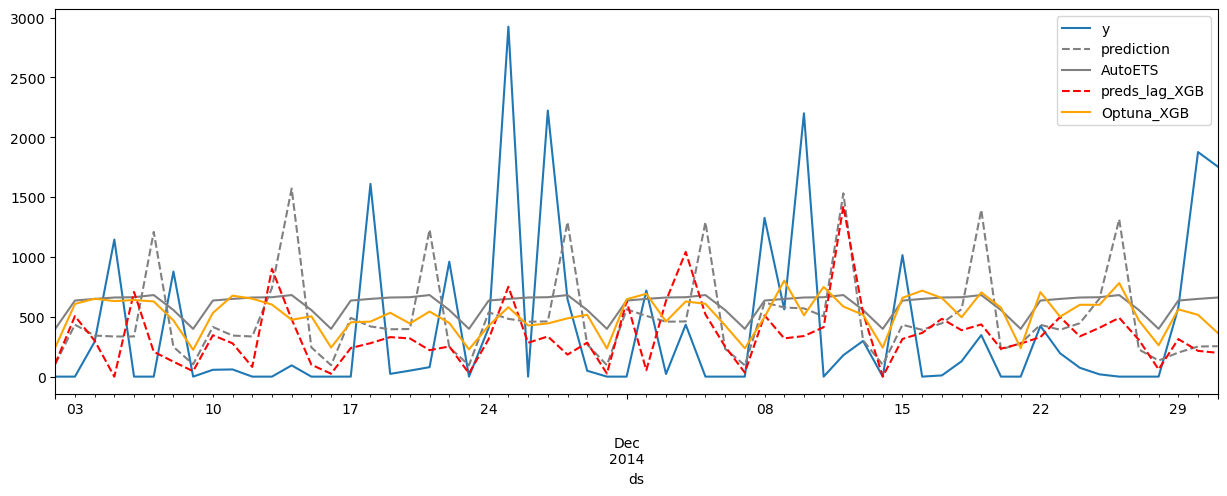

In [424]:
ax = df_Brazil.set_index('ds')[['y']].tail(60).plot(figsize=(15,5))
df_Brazil.set_index('ds')['prediction'].tail(60).plot(ax=ax,style='--',color = 'gray')
df_Brazil.set_index('ds')['AutoETS'].tail(60).plot(ax=ax,style='-', color = 'gray')
df_Brazil.set_index('ds')['preds_lag_XGB'].tail(60).plot(ax=ax,style='--', color = 'red')
df_Brazil.set_index('ds')['Optuna_XGB'].tail(60).plot(ax=ax,style='-', color = 'orange')

plt.legend()

In [419]:
Comparison_models = df_Brazil[['y','prediction','AutoETS','preds_lag_XGB','Optuna_XGB']].tail(60)

for i,modelo in enumerate(Comparison_models.columns.values):

    print(f"MAE modelo {modelo}: {mean_absolute_error(Comparison_models['y'], Comparison_models[modelo])}")
    print(f"MSE modelo {modelo}: {mean_squared_error(Comparison_models['y'], Comparison_models[modelo])}\n")

MAE modelo y: 0.0
MSE modelo y: 0.0

MAE modelo prediction: 571.2753812154134
MSE modelo prediction: 608674.520572319

MAE modelo AutoETS: 577.7068222045898
MSE modelo AutoETS: 464202.0429141164

MAE modelo preds_lag_XGB: 492.9195996284485
MSE modelo preds_lag_XGB: 496710.7978107748

MAE modelo Optuna_XGB: 758.9865648905436
MSE modelo Optuna_XGB: 787567.7408731893



## 5. 60-Day Sales Forecast

Using the best-performing configuration, we generate a **60-day forward forecast** of daily sales.

The forecast is plotted alongside the historical series, with prediction intervals where available,
to communicate the uncertainty range around each point estimate.

Key observations from the forecast:
- The model captures the **general level** of daily sales
- Prediction intervals widen over the forecast horizon, reflecting increasing uncertainty
- The forecast is notably **smoother than the historical series** — the model learns the
  underlying trend and seasonal pattern, but cannot anticipate future outlier spikes by design

## 6. Conclusion

This project applied a full time series forecasting pipeline to the Superstore daily sales series,
combining exploratory analysis, stationarity testing, and a comparison between statistical models
and XGBoost.

### Key Findings

**The dataset is heavily impacted by outliers.** Sporadic high-value sales days create extreme
spikes throughout the series that distort autocorrelation estimates, inflate error metrics, and
set an inherently high noise floor — making accurate point forecasting difficult for any model.

**Both modeling approaches struggled to achieve satisfactory accuracy.** The statistical models
from `statsforecast` captured trend and seasonal structure but were unable to anticipate the
magnitude of outlier events. XGBoost, despite its flexibility, also failed to generalize well
in the presence of such high variance, tending to either overfit to past spikes or produce
overly smooth forecasts.

### Limitations & Next Steps

The core challenge in this dataset is not model selection — it is **data quality and signal
clarity**. Possible paths to improvement include:

- **Outlier treatment:** capping, winsorizing, or explicitly modeling outlier days as special
  events (e.g., with exogenous indicator variables)
- **Aggregation at a coarser granularity:** weekly or monthly aggregation would reduce noise
  significantly and likely improve forecast accuracy
- **Feature enrichment:** incorporating promotional calendars, holiday flags, or category-level
  breakdowns as external regressors
- **Ensemble methods:** combining statistical and ML forecasts to hedge against individual
  model weaknesses

> Despite the forecasting accuracy limitations, this project demonstrates a rigorous analytical
> workflow and highlights an important practical lesson: **model performance is bounded by data
> quality**, and domain knowledge about what drives outliers is often more valuable than
> algorithm selection alone.

### NEXT STEPS

In the next notebook, We will try to perform some transformations, and increase the number of features to check if the models can be improved
